# 耕作地割合：カロリーポテンシャル限定・土壌群追加・Spatial OOF LightGBM

現地と周辺の農業ポテンシャルをカロリー指標に統一した二段階LightGBMです。
永久湿地（exclusion class 5）は推定対象から除外し、5-fold Spatial OOFで評価します。

## 分析仕様

- 現地：天水カロリーポテンシャル、灌漑によるカロリー増分
- 周辺：50 kmの天水カロリーポテンシャルのみ
- 水資源：現地GloFAS流量、一定規模以上の河川までの距離
- 土地：標高、傾斜、環境除外区分、WRB土壌群
- 市場アクセス：都市・港までの時間距離
- 除外：金額ポテンシャル、100 km農業ポテンシャル、周辺GloFAS、人口変数

## 1. 設定とライブラリ

In [1]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from IPython.display import display
from rasterio.enums import Resampling
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.neighbors import BallTree
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

ROOT = Path(r"/work/tsuda")
GAEZ_DIR = ROOT / "GAEZ"
HYDE_DIR = ROOT / "HYDE3.4"
CROPLAND_DIR = HYDE_DIR / "cropland_npys"
DIST_DIR = ROOT / "distance_to_cities"
GLOFAS_DIR = ROOT / "GloFAS" / "processed_5min"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"
WX_CACHE_DIR = GAEZ_DIR / "CroplandRegression" / "spatial_wx_comparison"
LAND_MASK_DIR = GAEZ_DIR / "LandMasks"
DERIVED_MASK_DIR = LAND_MASK_DIR / "derived_5min"
OUTPUT_DIR = GAEZ_DIR / "CroplandRegression" / "soil_group_calorie_only_50km"

DERIVED_MASK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOIL_TIF = LAND_MASK_DIR / "gaez_v5_wrb_soil_group_30sec.tif"
EXCLUSION_TIF = LAND_MASK_DIR / "gaez_v5_exclusion_30sec.tif"
SOIL_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_wrb_soil_group_5min_mode.npy"
EXCLUSION_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_exclusion_5min_mode.npy"

YEAR = 2024
RANDOM_SEED = 42
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120_000
N_ZERO_SAMPLE = 120_000
N_SPLITS = 5
N_JOBS = 4
MORAN_K = 8
MORAN_MAX_N = 50_000
SHAP_MAX_ROWS_PER_FOLD = 10_000

for required_path in [SOIL_TIF, EXCLUSION_TIF]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("output:", OUTPUT_DIR)


output: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km


## 2. GAEZ土壌群・環境除外区分を5分グリッドへ集約

In [2]:
lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
shape = (len(lat), len(lon))


def load_or_build_mode_cache(source_tif, cache_path, target_shape, fill_value=-1):
    if cache_path.exists():
        cached = np.load(cache_path, mmap_mode="r")
        if cached.shape == target_shape:
            print("load mode cache:", cache_path.name)
            return cached
        print("cache shape mismatch; rebuild:", cache_path)

    print("build mode cache:", cache_path.name)
    with rasterio.open(source_tif) as src:
        print("  source shape:", (src.height, src.width))
        print("  source bounds:", src.bounds)
        print("  source nodata:", src.nodata)
        reduced = src.read(
            1,
            out_shape=target_shape,
            resampling=Resampling.mode,
            masked=True,
        )

    # uint16ラスタには-1を直接fillできないため、先に符号付き整数へ変換する。
    reduced = reduced.astype(np.int32).filled(fill_value).astype(np.int16)
    np.save(cache_path, reduced)
    print("  saved:", cache_path)
    del reduced
    gc.collect()
    return np.load(cache_path, mmap_mode="r")


soil_group = load_or_build_mode_cache(
    SOIL_TIF,
    SOIL_5MIN_CACHE,
    shape,
)
exclusion = load_or_build_mode_cache(
    EXCLUSION_TIF,
    EXCLUSION_5MIN_CACHE,
    shape,
)

print("grid shape:", shape)
print("latitude order:", float(lat[0]), "to", float(lat[-1]))
print("longitude order:", float(lon[0]), "to", float(lon[-1]))


load mode cache: gaez_v5_wrb_soil_group_5min_mode.npy
load mode cache: gaez_v5_exclusion_5min_mode.npy
grid shape: (2160, 4320)
latitude order: 89.95825958251953 to -89.95833587646484
longitude order: -179.9583282470703 to 179.95819091796875


## 3. 説明変数の読込と50 km周辺カロリー指標の作成

In [3]:
def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            print("load cache:", path.name)
            return np.load(path, mmap_mode="r")
    raise FileNotFoundError("Required cache not found: " + ", ".join(names))


def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)


def positive_raw(values):
    values = np.asarray(values, dtype=np.float32)
    return np.where(
        np.isfinite(values) & (values > 0),
        values,
        0.0,
    ).astype(np.float32)


def _rolling_sum_horizontal(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    extended = np.concatenate(
        [values[:, -half_width:], values, values[:, :half_width]],
        axis=1,
    )
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((values.shape[0], 1), dtype=np.float64),
            np.cumsum(extended, axis=1, dtype=np.float64),
        ],
        axis=1,
    )
    return (cumulative[:, width:] - cumulative[:, :-width]).astype(np.float32)


def _rolling_sum_vertical(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    padded = np.pad(values, ((half_width, half_width), (0, 0)), mode="edge")
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((1, values.shape[1]), dtype=np.float64),
            np.cumsum(padded, axis=0, dtype=np.float64),
        ],
        axis=0,
    )
    return (cumulative[width:, :] - cumulative[:-width, :]).astype(np.float32)


def latitude_aware_box_mean(
    values,
    lat_values,
    lon_values,
    radius_km,
    min_valid_fraction=0.25,
):
    values = np.asarray(values, dtype=np.float32)
    expected_shape = (len(lat_values), len(lon_values))
    if values.shape != expected_shape:
        raise ValueError(
            f"Unexpected raster shape: {values.shape}; expected {expected_shape}"
        )

    earth_radius_km = 6371.0088
    km_per_degree = earth_radius_km * np.pi / 180.0
    lat_step_deg = float(np.median(np.abs(np.diff(lat_values))))
    lon_step_deg = float(np.median(np.abs(np.diff(lon_values))))
    half_lat = max(
        1,
        int(np.ceil(radius_km / (km_per_degree * lat_step_deg))),
    )

    cos_lat = np.clip(np.cos(np.deg2rad(lat_values)), 1e-6, None)
    half_lon_by_row = np.ceil(
        radius_km / (km_per_degree * cos_lat * lon_step_deg)
    ).astype(np.int32)
    half_lon_by_row = np.minimum(
        half_lon_by_row,
        values.shape[1] // 2 - 1,
    )

    finite = np.isfinite(values)
    filled = np.where(finite, values, 0.0).astype(np.float32)
    counts = finite.astype(np.float32)
    horizontal_sum = np.zeros_like(filled, dtype=np.float32)
    horizontal_count = np.zeros_like(counts, dtype=np.float32)

    for half_lon in np.unique(half_lon_by_row):
        row_indices = np.flatnonzero(half_lon_by_row == half_lon)
        horizontal_sum[row_indices] = _rolling_sum_horizontal(
            filled[row_indices],
            int(half_lon),
        )
        horizontal_count[row_indices] = _rolling_sum_horizontal(
            counts[row_indices],
            int(half_lon),
        )

    vertical_sum = _rolling_sum_vertical(horizontal_sum, half_lat)
    vertical_count = _rolling_sum_vertical(horizontal_count, half_lat)

    row_width = (2 * half_lon_by_row + 1).astype(np.float64)
    padded_width = np.pad(row_width, (half_lat, half_lat), mode="edge")
    cumulative_width = np.concatenate([[0.0], np.cumsum(padded_width)])
    window_width_by_row = (
        cumulative_width[2 * half_lat + 1:]
        - cumulative_width[:-(2 * half_lat + 1)]
    )
    minimum_count = min_valid_fraction * window_width_by_row

    result = np.full(values.shape, np.nan, dtype=np.float32)
    valid = vertical_count >= minimum_count[:, None]
    with np.errstate(divide="ignore", invalid="ignore"):
        result[valid] = (
            vertical_sum[valid] / vertical_count[valid]
        ).astype(np.float32)
    return result


cropland_cube = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")
year_index = int(np.where(years == YEAR)[0][0])
cropland = np.asarray(cropland_cube[year_index], dtype=np.float32).copy()
cropland[~np.isfinite(cropland)] = np.nan

# Population is used only to preserve the existing land/sample mask.
# It is not included as a predictor.
population = load_cache("population_density_2024.npy")
elevation = load_cache("elevation_5min.npy")
slope = load_cache("slope_5min.npy")
city_time = np.load(DIST_DIR / "cities_10_1_12deg_min.npy", mmap_mode="r")
port_time = np.load(DIST_DIR / "ports_05_1_12deg_min.npy", mmap_mode="r")
glofas = np.load(GLOFAS_DIR / "p10_discharge_max_5min_2020.npy", mmap_mode="r")
river_distance = np.load(
    GLOFAS_DIR / "distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy",
    mmap_mode="r",
)

rainfed_calorie = load_cache(
    "rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "rainfed_calorie_top5_checked_36crops.npy",
)
irrigated_calorie = load_cache(
    "irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "irrigated_calorie_top5_checked_36crops.npy",
)

WX_50KM_CALORIE_CACHE = (
    WX_CACHE_DIR / "wx_50km_rainfed_calorie_top5_raw.npy"
)
if WX_50KM_CALORIE_CACHE.exists():
    print("load calorie WX cache:", WX_50KM_CALORIE_CACHE.name)
else:
    print("build calorie WX cache:", WX_50KM_CALORIE_CACHE.name)
    calorie_source = positive_raw(rainfed_calorie)
    wx_50km_calorie_build = latitude_aware_box_mean(
        calorie_source,
        lat,
        lon,
        radius_km=50,
        min_valid_fraction=0.25,
    )
    np.save(
        WX_50KM_CALORIE_CACHE,
        wx_50km_calorie_build.astype(np.float32, copy=False),
    )
    del calorie_source, wx_50km_calorie_build
    gc.collect()

wx_50km_rainfed_calorie = np.load(
    WX_50KM_CALORIE_CACHE,
    mmap_mode="r",
)

for name, raster in {
    "cropland": cropland,
    "soil_group": soil_group,
    "exclusion": exclusion,
    "elevation": elevation,
    "slope": slope,
    "city_time": city_time,
    "port_time": port_time,
    "glofas": glofas,
    "river_distance": river_distance,
    "rainfed_calorie": rainfed_calorie,
    "irrigated_calorie": irrigated_calorie,
    "wx_50km_rainfed_calorie": wx_50km_rainfed_calorie,
}.items():
    if raster.shape != shape:
        raise ValueError(f"shape mismatch: {name} {raster.shape} != {shape}")

print("all required rasters are aligned:", shape)


load cache: population_density_2024.npy
load cache: elevation_5min.npy
load cache: slope_5min.npy
load cache: rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy
load cache: irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy
load calorie WX cache: wx_50km_rainfed_calorie_top5_raw.npy
all required rasters are aligned: (2160, 4320)


## 4. 分析標本、使用変数、Spatial OOF分割

In [4]:
base_land_mask = (
    np.isfinite(elevation)
    & np.isfinite(cropland)
    & np.isfinite(population)
    & (population >= 0)
)
valid_exclusion = (exclusion >= 1) & (exclusion <= 6)
permanent_wetland = exclusion == 5
valid_soil = (soil_group >= 1) & (soil_group <= 33)

land_mask = (
    base_land_mask
    & valid_exclusion
    & ~permanent_wetland
    & valid_soil
)
presence_raster = land_mask & (cropland > PRESENCE_THRESHOLD)
target_prior = float(presence_raster.sum() / land_mask.sum())

print("base land cells:", f"{int(base_land_mask.sum()):,}")
print(
    "permanent-wetland cells removed from base land:",
    f"{int((base_land_mask & permanent_wetland).sum()):,}",
)
print("final eligible cells:", f"{int(land_mask.sum()):,}")
print("population presence prior:", target_prior)

rng = np.random.default_rng(RANDOM_SEED)
positive_flat = np.flatnonzero(presence_raster.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence_raster).ravel())

positive_sample = rng.choice(
    positive_flat,
    min(N_POS_SAMPLE, len(positive_flat)),
    replace=False,
)
zero_sample = rng.choice(
    zero_flat,
    min(N_ZERO_SAMPLE, len(zero_flat)),
    replace=False,
)
sample_flat = np.concatenate([positive_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, shape)


def take(array):
    return np.asarray(array[rows, cols])


rainfed_calorie_sample = take(rainfed_calorie).astype(np.float32)
irrigated_calorie_sample = take(irrigated_calorie).astype(np.float32)
calorie_pair_valid = (
    np.isfinite(rainfed_calorie_sample)
    & np.isfinite(irrigated_calorie_sample)
)
irrigation_calorie_gain = np.where(
    calorie_pair_valid,
    np.maximum(irrigated_calorie_sample - rainfed_calorie_sample, 0.0),
    0.0,
).astype(np.float32)

sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "lat": lat[rows].astype(np.float32),
    "lon": lon[cols].astype(np.float32),
    "cropland_fraction": take(cropland).astype(np.float32),
    "presence": (take(cropland) > PRESENCE_THRESHOLD).astype(np.uint8),
    "elevation_m": take(elevation).astype(np.float32),
    "slope": take(slope).astype(np.float32),
    "exclusion_class": take(exclusion).astype(np.int16),
    "soil_group_class": take(soil_group).astype(np.int16),
    "log_city_time_20k_min": safe_log1p(take(city_time)),
    "log_port_time_any_min": safe_log1p(take(port_time)),
    "log_glofas_p10_2020": safe_log1p(take(glofas)),
    "log_distance_river_gt10_2020": safe_log1p(take(river_distance)),
    "rainfed_calorie_top5_raw": positive_raw(rainfed_calorie_sample),
    "irrigation_calorie_gain_top5_raw": irrigation_calorie_gain,
    "wx_50km_rainfed_calorie_top5_raw": take(
        wx_50km_rainfed_calorie
    ).astype(np.float32),
})

sample["spatial_block"] = (
    np.floor((sample["lat"] + 90) / 10).astype(int) * 36
    + np.floor((sample["lon"] + 180) / 10).astype(int)
)

BASE_FEATURES = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "rainfed_calorie_top5_raw",
    "irrigation_calorie_gain_top5_raw",
    "wx_50km_rainfed_calorie_top5_raw",
    "log_distance_river_gt10_2020",
    "log_glofas_p10_2020",
]
SOIL_FEATURES = BASE_FEATURES + ["soil_group_class"]

MODEL_FEATURES = {
    "no_soil_wetland_excluded": BASE_FEATURES,
    "soil_group_wetland_excluded": SOIL_FEATURES,
}
CATEGORICAL_CANDIDATES = ["exclusion_class", "soil_group_class"]

all_features = sorted(set().union(*MODEL_FEATURES.values()))
sample = (
    sample.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=all_features + ["cropland_fraction", "presence"])
    .reset_index(drop=True)
)

for column in CATEGORICAL_CANDIDATES:
    sample[column] = sample[column].astype("category")

if sample["presence"].nunique() != 2:
    raise ValueError("Both presence classes are required.")
if (sample["exclusion_class"].astype(int) == 5).any():
    raise RuntimeError("Permanent wetland remains in the analysis sample.")

groups = sample["spatial_block"].to_numpy()
y_presence = sample["presence"].to_numpy(dtype=np.uint8)
splits = list(
    GroupKFold(n_splits=N_SPLITS).split(
        sample,
        y_presence,
        groups=groups,
    )
)

try:
    area_raster = np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r")
    sample_area = np.asarray(
        area_raster[
            sample["row"].to_numpy(int),
            sample["col"].to_numpy(int),
        ],
        dtype=float,
    )
    n_pos_population = int(presence_raster.sum())
    n_zero_population = int(land_mask.sum() - presence_raster.sum())
    n_pos_sample = int((y_presence == 1).sum())
    n_zero_sample = int((y_presence == 0).sum())
    area_weight = np.where(
        y_presence == 1,
        n_pos_population / max(n_pos_sample, 1),
        n_zero_population / max(n_zero_sample, 1),
    ) * sample_area
except FileNotFoundError:
    print("grid_area_km2.npy not found; area weighting is skipped.")
    area_weight = None

print("common analysis rows:", len(sample))
print("presence share in balanced sample:", sample["presence"].mean())
print("spatial blocks:", sample["spatial_block"].nunique())
for model_name, features in MODEL_FEATURES.items():
    print(f"{model_name:32s}: {len(features)} features")
print("calorie-only features:", SOIL_FEATURES)


base land cells: 2,215,635
permanent-wetland cells removed from base land: 69,237
final eligible cells: 2,100,681
population presence prior: 0.36645306926658544
common analysis rows: 240000
presence share in balanced sample: 0.5
spatial blocks: 290
no_soil_wetland_excluded        : 10 features
soil_group_wetland_excluded     : 11 features
calorie-only features: ['elevation_m', 'slope', 'exclusion_class', 'log_city_time_20k_min', 'log_port_time_any_min', 'rainfed_calorie_top5_raw', 'irrigation_calorie_gain_top5_raw', 'wx_50km_rainfed_calorie_top5_raw', 'log_distance_river_gt10_2020', 'log_glofas_p10_2020', 'soil_group_class']


## 5. 土壌群と永久湿地除外の確認

,soil_group_class,soil_group,n,share_percent
0,1,Acrisols,10984,4.577
1,2,Alisols,610,0.254
2,3,Andosols,1561,0.650
3,4,Arenosols,16032,6.680
4,5,Anthrosols,932,0.388
5,6,Chernozems,6187,2.578
6,7,Calcisols,8911,3.713
7,8,Cambisols,17969,7.487
8,9,Cryosols,23557,9.815
9,10,Fluvisols,5215,2.173


Technosol sample rows: 350
Permanent-wetland sample rows: 0


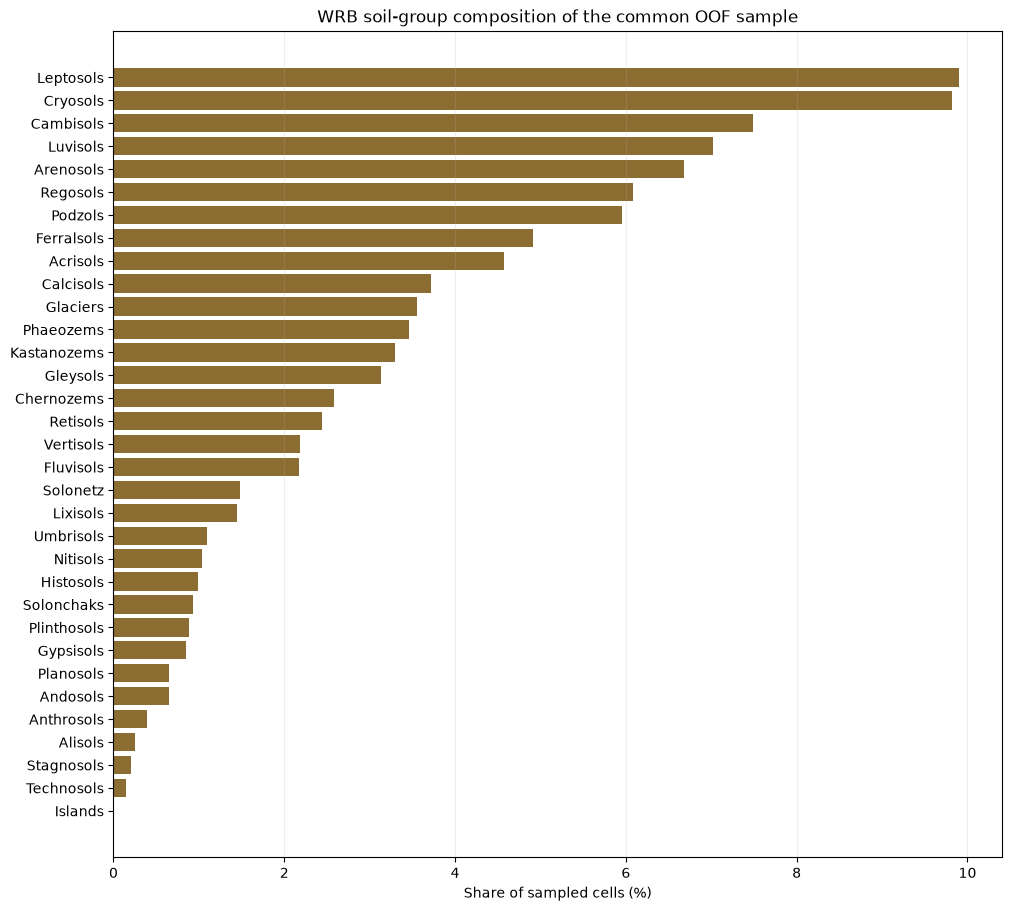

In [5]:
SOIL_LABELS = {
    1: "Acrisols", 2: "Alisols", 3: "Andosols", 4: "Arenosols",
    5: "Anthrosols", 6: "Chernozems", 7: "Calcisols", 8: "Cambisols",
    9: "Cryosols", 10: "Fluvisols", 11: "Ferralsols", 12: "Glaciers",
    13: "Gleysols", 14: "Gypsisols", 15: "Histosols", 16: "Islands",
    17: "Kastanozems", 18: "Leptosols", 19: "Luvisols", 20: "Lixisols",
    21: "Nitisols", 22: "Phaeozems", 23: "Planosols", 24: "Plinthosols",
    25: "Podzols", 26: "Regosols", 27: "Retisols", 28: "Solonchaks",
    29: "Solonetz", 30: "Stagnosols", 31: "Technosols", 32: "Umbrisols",
    33: "Vertisols", 34: "Open Water",
}

soil_codes = sample["soil_group_class"].astype(int)
soil_distribution = (
    soil_codes.value_counts()
    .sort_index()
    .rename_axis("soil_group_class")
    .reset_index(name="n")
)
soil_distribution["soil_group"] = soil_distribution["soil_group_class"].map(SOIL_LABELS)
soil_distribution["share_percent"] = 100 * soil_distribution["n"] / soil_distribution["n"].sum()
display(soil_distribution[["soil_group_class", "soil_group", "n", "share_percent"]].round(3))

technosol_n = int((soil_codes == 31).sum())
print("Technosol sample rows:", f"{technosol_n:,}")
print("Permanent-wetland sample rows:", int((sample["exclusion_class"].astype(int) == 5).sum()))

plot_frame = soil_distribution.sort_values("share_percent")
fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
ax.barh(
    plot_frame["soil_group"],
    plot_frame["share_percent"],
    color="#8C6D31",
)
ax.set_title("WRB soil-group composition of the common OOF sample")
ax.set_xlabel("Share of sampled cells (%)")
ax.grid(axis="x", alpha=0.2)
plt.show()


## 6. 二段階LightGBM・評価・SHAP関数

In [6]:
def adjust_probability_prior_shift(
    probability,
    sample_prior,
    population_prior,
    eps=1e-6,
):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    population_prior = float(np.clip(population_prior, eps, 1 - eps))
    odds = probability / (1.0 - probability)
    odds *= (
        (population_prior / (1.0 - population_prior))
        / (sample_prior / (1.0 - sample_prior))
    )
    return odds / (1.0 + odds)


def regression_metrics(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]

    residual = y_true - y_pred
    observed_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * residual ** 2)
    ss_tot = np.sum(weights * (y_true - observed_mean) ** 2)

    return {
        "n": int(len(y_true)),
        "observed_mean": float(observed_mean),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "rmse": float(np.sqrt(np.average(residual ** 2, weights=weights))),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "bias_observed_minus_predicted": float(np.average(residual, weights=weights)),
    }


def categorical_features_for(features):
    return [
        feature
        for feature in CATEGORICAL_CANDIDATES
        if feature in features
    ]


def fit_models(train_df, features, fold_number):
    categorical_features = categorical_features_for(features)

    classifier = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    classifier.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=categorical_features,
    )

    positive_train = train_df[train_df["presence"].eq(1)]
    regressor = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    regressor.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=categorical_features,
    )
    return classifier, regressor


def extract_tree_shap(explainer, values):
    shap_values = explainer.shap_values(values)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    if shap_values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")
    return shap_values


def select_local_positions(n_rows, max_rows, seed):
    if n_rows <= max_rows:
        return np.arange(n_rows, dtype=int)
    local_rng = np.random.default_rng(seed)
    return np.sort(
        local_rng.choice(n_rows, max_rows, replace=False)
    )


def add_shap_summaries(
    output_rows,
    model_name,
    stage,
    fold_number,
    features,
    shap_values,
    weights,
):
    weights = np.asarray(weights, dtype=float)
    valid_weight = np.isfinite(weights) & (weights > 0)
    if not valid_weight.any():
        weights = np.ones(len(shap_values), dtype=float)
        valid_weight = np.ones(len(shap_values), dtype=bool)

    shap_values = shap_values[valid_weight]
    weights = weights[valid_weight]
    for feature_index, feature in enumerate(features):
        values = shap_values[:, feature_index]
        output_rows.append({
            "model": model_name,
            "stage": stage,
            "fold": fold_number,
            "feature": feature,
            "sum_weight": float(weights.sum()),
            "sum_abs_shap_weighted": float(np.sum(weights * np.abs(values))),
            "sum_signed_shap_weighted": float(np.sum(weights * values)),
            "n": int(len(values)),
        })


## 7. 5-fold Spatial OOFと全説明変数のローカルSHAP

In [7]:
import shap

SOIL_MODEL_NAME = "soil_group_wetland_excluded"
observed = sample["cropland_fraction"].to_numpy(dtype=float)

prediction_by_model = {}
fold_rows = []
shap_rows = []
soil_local_rows = []
local_feature_rows = []


def make_local_feature_shap_frame(
    stage,
    fold_number,
    source_frame,
    features,
    shap_values,
    weights,
):
    result = source_frame[
        ["row", "col", "lat", "lon"] + features
    ].reset_index(drop=True).copy()
    for feature in CATEGORICAL_CANDIDATES:
        if feature in result.columns:
            result[feature] = result[feature].astype(int)
    for feature_index, feature in enumerate(features):
        result[f"shap__{feature}"] = np.asarray(
            shap_values[:, feature_index],
            dtype=np.float32,
        )
    result.insert(0, "stage", stage)
    result.insert(1, "fold", fold_number)
    result["weight"] = np.asarray(weights, dtype=float)
    return result


for model_number, (model_name, features) in enumerate(
    MODEL_FEATURES.items(),
    start=1,
):
    print("=" * 80)
    print(
        f"MODEL {model_number}/{len(MODEL_FEATURES)}: "
        f"{model_name} ({len(features)} features)"
    )
    print("=" * 80)

    expected_oof = np.full(len(sample), np.nan, dtype=np.float32)

    for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
        print(f"  fold {fold_number}/{N_SPLITS}")
        train_df = sample.iloc[train_idx]
        test_df = sample.iloc[test_idx]

        classifier, regressor = fit_models(
            train_df,
            features,
            fold_number,
        )

        raw_probability = classifier.predict_proba(test_df[features])[:, 1]
        calibrated_probability = adjust_probability_prior_shift(
            raw_probability,
            float(train_df["presence"].mean()),
            target_prior,
        )
        conditional_fraction = np.clip(
            regressor.predict(test_df[features]),
            0.0,
            1.0,
        )
        expected_fraction = calibrated_probability * conditional_fraction
        expected_oof[test_idx] = expected_fraction.astype(np.float32)

        y_test_presence = test_df["presence"].to_numpy(dtype=np.uint8)
        y_test_fraction = test_df["cropland_fraction"].to_numpy(dtype=float)
        positive_test = y_test_presence == 1

        combined = regression_metrics(y_test_fraction, expected_fraction)
        conditional = regression_metrics(
            y_test_fraction[positive_test],
            conditional_fraction[positive_test],
        )
        fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "n_features": len(features),
            "combined_r2": combined["r2"],
            "combined_rmse": combined["rmse"],
            "combined_mae": combined["mae"],
            "conditional_r2": conditional["r2"],
            "conditional_rmse": conditional["rmse"],
            "presence_auc": float(
                roc_auc_score(y_test_presence, raw_probability)
            ),
            "presence_average_precision": float(
                average_precision_score(y_test_presence, raw_probability)
            ),
        })

        if model_name == SOIL_MODEL_NAME:
            selected_presence = select_local_positions(
                len(test_df),
                SHAP_MAX_ROWS_PER_FOLD,
                RANDOM_SEED + 1000 + fold_number,
            )
            presence_frame = test_df.iloc[selected_presence]
            presence_global_idx = test_idx[selected_presence]
            presence_values = extract_tree_shap(
                shap.TreeExplainer(classifier),
                presence_frame[features],
            )
            presence_weights = (
                area_weight[presence_global_idx]
                if area_weight is not None
                else np.ones(len(presence_frame), dtype=float)
            )
            add_shap_summaries(
                shap_rows,
                model_name,
                "presence_classifier",
                fold_number,
                features,
                presence_values,
                presence_weights,
            )
            local_feature_rows.append(
                make_local_feature_shap_frame(
                    "presence_classifier",
                    fold_number,
                    presence_frame,
                    features,
                    presence_values,
                    presence_weights,
                )
            )

            soil_feature_index = features.index("soil_group_class")
            soil_local_rows.append(pd.DataFrame({
                "stage": "presence_classifier",
                "fold": fold_number,
                "soil_group_class": (
                    presence_frame["soil_group_class"].astype(int).to_numpy()
                ),
                "soil_group_shap": presence_values[:, soil_feature_index],
                "weight": presence_weights,
            }))

            positive_local = np.flatnonzero(positive_test)
            selected_positive_position = select_local_positions(
                len(positive_local),
                SHAP_MAX_ROWS_PER_FOLD,
                RANDOM_SEED + 2000 + fold_number,
            )
            selected_positive = positive_local[selected_positive_position]
            fraction_frame = test_df.iloc[selected_positive]
            fraction_global_idx = test_idx[selected_positive]
            fraction_values = extract_tree_shap(
                shap.TreeExplainer(regressor),
                fraction_frame[features],
            )
            fraction_weights = (
                area_weight[fraction_global_idx]
                if area_weight is not None
                else np.ones(len(fraction_frame), dtype=float)
            )
            add_shap_summaries(
                shap_rows,
                model_name,
                "conditional_fraction_regressor",
                fold_number,
                features,
                fraction_values,
                fraction_weights,
            )
            local_feature_rows.append(
                make_local_feature_shap_frame(
                    "conditional_fraction_regressor",
                    fold_number,
                    fraction_frame,
                    features,
                    fraction_values,
                    fraction_weights,
                )
            )
            soil_local_rows.append(pd.DataFrame({
                "stage": "conditional_fraction_regressor",
                "fold": fold_number,
                "soil_group_class": (
                    fraction_frame["soil_group_class"].astype(int).to_numpy()
                ),
                "soil_group_shap": fraction_values[:, soil_feature_index],
                "weight": fraction_weights,
            }))

        del classifier, regressor
        del raw_probability, calibrated_probability
        del conditional_fraction, expected_fraction
        gc.collect()

    if not np.isfinite(expected_oof).all():
        raise RuntimeError(f"OOF prediction is incomplete: {model_name}")
    prediction_by_model[model_name] = expected_oof

fold_metrics = pd.DataFrame(fold_rows)

global_rows = []
weight_specs = {"unweighted_sample": None}
if area_weight is not None:
    weight_specs["area_weighted_reweighted"] = area_weight

for model_name, prediction in prediction_by_model.items():
    for weighting, weights in weight_specs.items():
        global_rows.append({
            "model": model_name,
            "weighting": weighting,
            "n_features": len(MODEL_FEATURES[model_name]),
            **regression_metrics(observed, prediction, weights=weights),
        })

global_metrics = pd.DataFrame(global_rows)
shap_fold_summary = pd.DataFrame(shap_rows)
soil_local_shap = pd.concat(soil_local_rows, ignore_index=True)
local_feature_shap = pd.concat(local_feature_rows, ignore_index=True)

prediction_table = sample[
    [
        "row", "col", "lat", "lon", "spatial_block",
        "presence", "cropland_fraction", "exclusion_class",
        "soil_group_class",
    ]
].copy()
for model_name, prediction in prediction_by_model.items():
    prediction_table[f"pred_{model_name}"] = prediction

fold_metrics.to_csv(
    OUTPUT_DIR / "soil_comparison_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
global_metrics.to_csv(
    OUTPUT_DIR / "soil_comparison_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
prediction_table.to_csv(
    OUTPUT_DIR / "soil_comparison_oof_predictions.csv.gz",
    index=False,
    compression="gzip",
)
shap_fold_summary.to_csv(
    OUTPUT_DIR / "soil_model_oof_shap_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
soil_local_shap.to_csv(
    OUTPUT_DIR / "soil_group_oof_local_shap.csv.gz",
    index=False,
    compression="gzip",
)
local_feature_shap.to_csv(
    OUTPUT_DIR / "soil_model_oof_local_feature_shap.csv.gz",
    index=False,
    compression="gzip",
)
print("OOF and local SHAP completed.")
print(global_metrics.round(6).to_string(index=False))


MODEL 1/2: no_soil_wetland_excluded (10 features)
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
MODEL 2/2: soil_group_wetland_excluded (11 features)
  fold 1/5


/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  fold 2/5


/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  fold 3/5


...

  fold 4/5


/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  fold 5/5


/work/tsuda/miniconda3/envs/research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


OOF and local SHAP completed.
                      model                weighting  n_features      n  observed_mean  predicted_mean       r2     rmse      mae  bias_observed_minus_predicted
   no_soil_wetland_excluded        unweighted_sample          10 240000       0.140323        0.126475 0.570507 0.145953 0.083462                       0.013849
   no_soil_wetland_excluded area_weighted_reweighted          10 240000       0.116793        0.112416 0.562400 0.138834 0.076815                       0.004377
soil_group_wetland_excluded        unweighted_sample          11 240000       0.140323        0.127849 0.617500 0.137737 0.077579                       0.012474
soil_group_wetland_excluded area_weighted_reweighted          11 240000       0.116793        0.112115 0.604354 0.132012 0.072042                       0.004678


## 8. OOF精度：土壌なしモデルと土壌ありモデル

,model,weighting,n_features,n,observed_mean,predicted_mean,r2,rmse,mae,bias_observed_minus_predicted
3,soil_group_wetland_excluded,area_weighted_reweighted,11,240000,0.116793,0.112115,0.604354,0.132012,0.072042,0.004678
1,no_soil_wetland_excluded,area_weighted_reweighted,10,240000,0.116793,0.112416,0.562400,0.138834,0.076815,0.004377
2,soil_group_wetland_excluded,unweighted_sample,11,240000,0.140323,0.127849,0.617500,0.137737,0.077579,0.012474
0,no_soil_wetland_excluded,unweighted_sample,10,240000,0.140323,0.126475,0.570507,0.145953,0.083462,0.013849


,weighting,delta_r2_soil_minus_no_soil,delta_rmse_soil_minus_no_soil,delta_mae_soil_minus_no_soil
0,unweighted_sample,0.046992,-0.008216,-0.005883
1,area_weighted_reweighted,0.041954,-0.006823,-0.004773


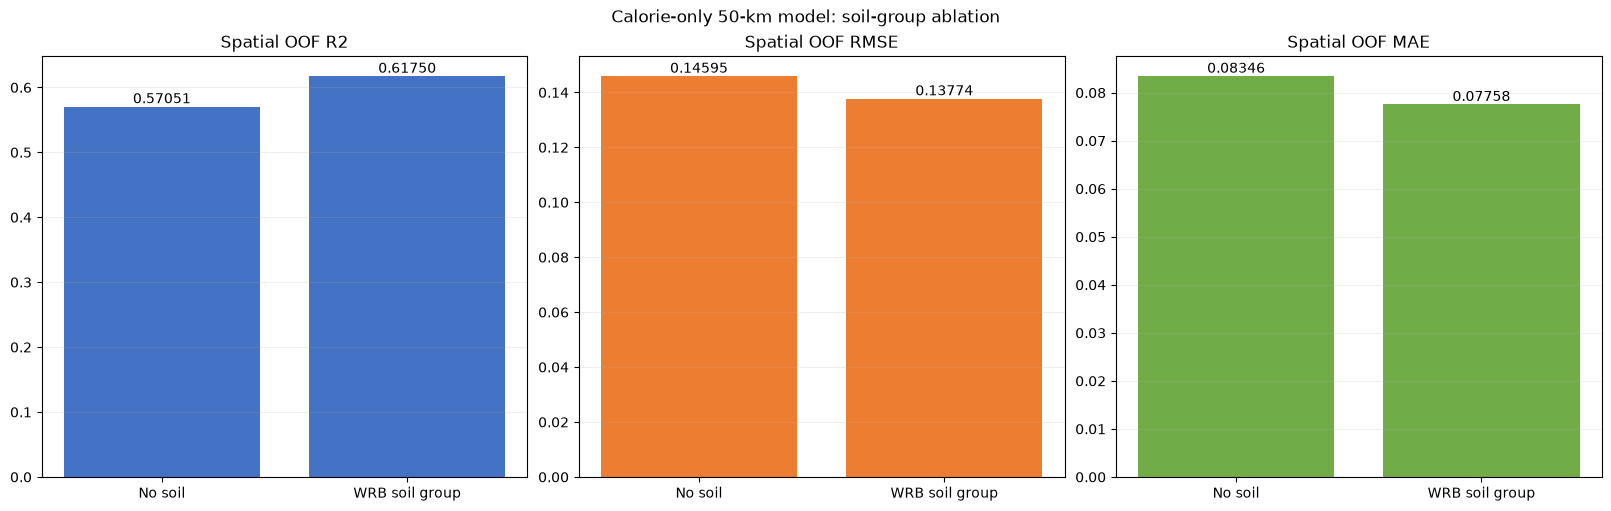

In [8]:
display(
    global_metrics.sort_values(["weighting", "r2"], ascending=[True, False])
    .round(6)
)

baseline_name = "no_soil_wetland_excluded"
soil_name = "soil_group_wetland_excluded"

comparison_rows = []
for weighting in global_metrics["weighting"].unique():
    sub = global_metrics[global_metrics["weighting"].eq(weighting)].set_index("model")
    baseline = sub.loc[baseline_name]
    soil_result = sub.loc[soil_name]
    comparison_rows.append({
        "weighting": weighting,
        "delta_r2_soil_minus_no_soil": soil_result["r2"] - baseline["r2"],
        "delta_rmse_soil_minus_no_soil": soil_result["rmse"] - baseline["rmse"],
        "delta_mae_soil_minus_no_soil": soil_result["mae"] - baseline["mae"],
    })

soil_delta = pd.DataFrame(comparison_rows)
display(soil_delta.round(6))
soil_delta.to_csv(
    OUTPUT_DIR / "soil_model_metric_deltas.csv",
    index=False,
    encoding="utf-8-sig",
)

unweighted = (
    global_metrics[global_metrics["weighting"].eq("unweighted_sample")]
    .set_index("model")
    .loc[[baseline_name, soil_name]]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, metric, color in zip(
    axes,
    ["r2", "rmse", "mae"],
    ["#4472C4", "#ED7D31", "#70AD47"],
):
    ax.bar(
        ["No soil", "WRB soil group"],
        unweighted[metric],
        color=color,
    )
    ax.set_title(f"Spatial OOF {metric.upper()}")
    ax.grid(axis="y", alpha=0.2)
    for x, value in enumerate(unweighted[metric]):
        ax.text(x, value, f"{value:.5f}", ha="center", va="bottom")

fig.suptitle("Calorie-only 50-km model: soil-group ablation")
fig.savefig(OUTPUT_DIR / "soil_ablation_metrics.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. OOF残差のMoran's Iと空間分布

,model,morans_i,expected_i,n,k
1,soil_group_wetland_excluded,0.466551,-0.00002,50000,8
0,no_soil_wetland_excluded,0.516609,-0.00002,50000,8


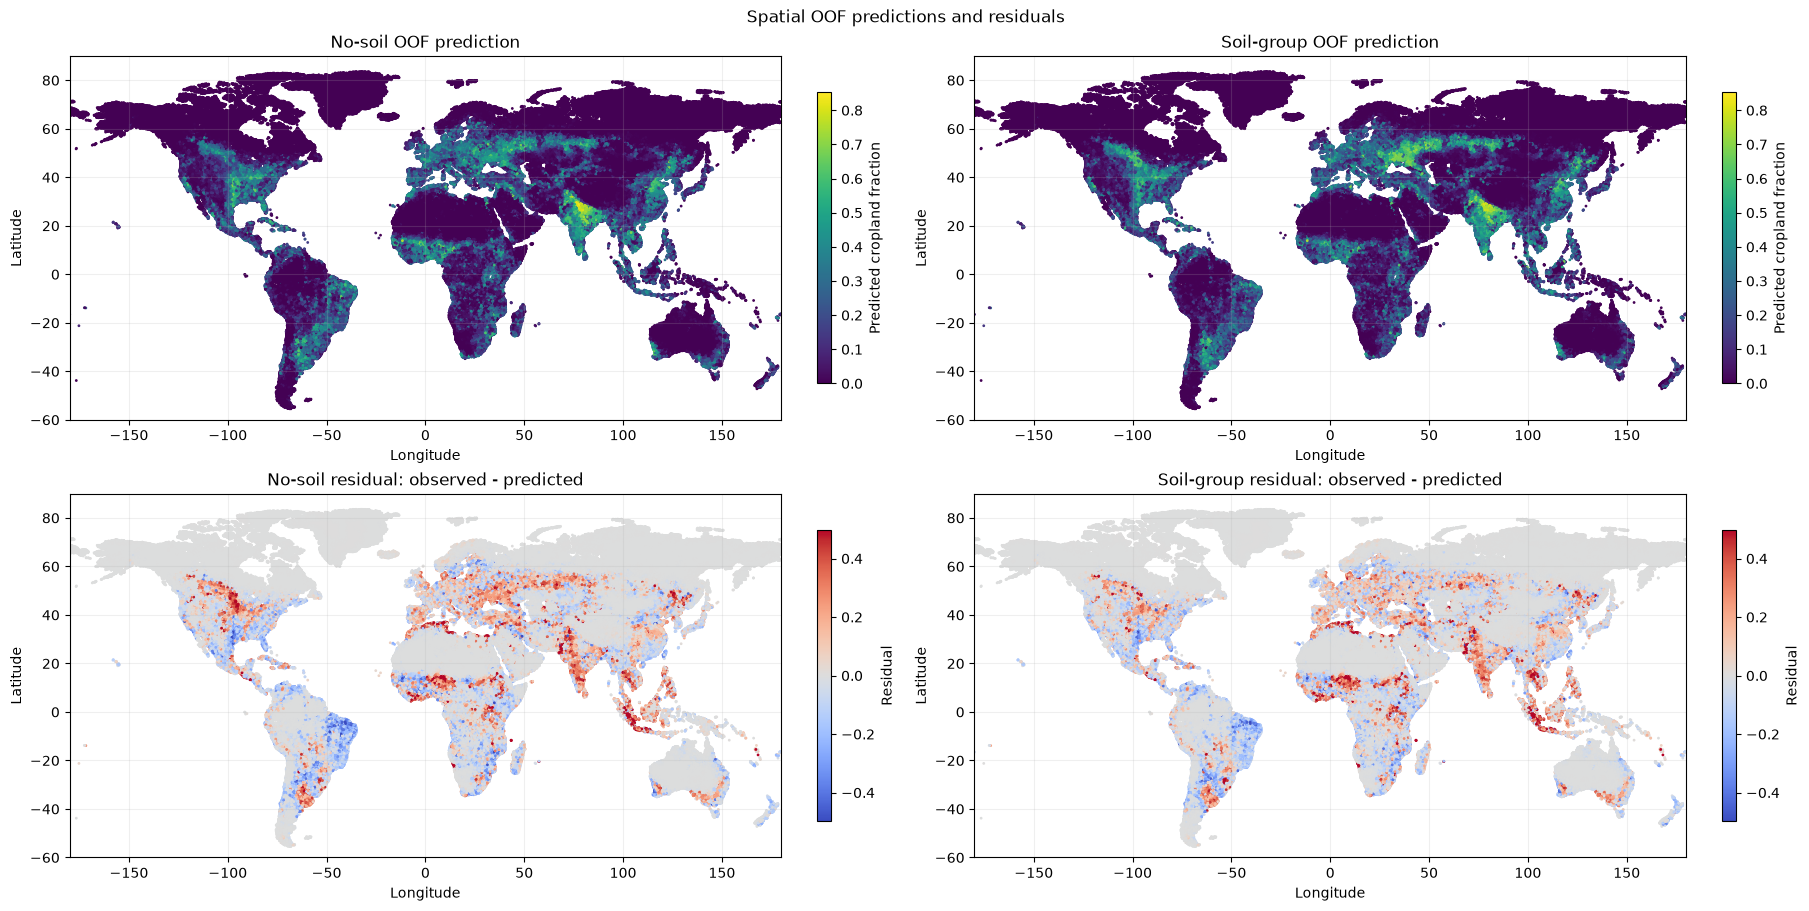

In [9]:
def morans_i_knn(
    frame,
    residual,
    k=MORAN_K,
    max_n=MORAN_MAX_N,
    seed=RANDOM_SEED + 7000,
):
    residual = np.asarray(residual, dtype=float)
    coords = frame[["lat", "lon"]].to_numpy(dtype=float)
    valid = np.isfinite(residual) & np.isfinite(coords).all(axis=1)
    valid_idx = np.flatnonzero(valid)

    if len(valid_idx) > max_n:
        local_rng = np.random.default_rng(seed)
        valid_idx = np.sort(
            local_rng.choice(valid_idx, max_n, replace=False)
        )

    selected_residual = residual[valid_idx]
    selected_coords = np.radians(coords[valid_idx])
    centered = selected_residual - selected_residual.mean()

    tree = BallTree(selected_coords, metric="haversine")
    _, neighbor_idx = tree.query(
        selected_coords,
        k=min(k + 1, len(selected_coords)),
    )
    neighbor_idx = neighbor_idx[:, 1:]

    denominator = np.sum(centered ** 2)
    numerator = np.sum(centered[:, None] * centered[neighbor_idx])
    actual_k = neighbor_idx.shape[1]
    morans_i = numerator / (actual_k * denominator)

    return {
        "morans_i": float(morans_i),
        "expected_i": float(-1.0 / (len(selected_residual) - 1)),
        "n": int(len(selected_residual)),
        "k": int(actual_k),
    }


moran_rows = []
for model_name, prediction in prediction_by_model.items():
    residual = observed - np.asarray(prediction, dtype=float)
    moran_rows.append({
        "model": model_name,
        **morans_i_knn(sample, residual),
    })

moran_results = pd.DataFrame(moran_rows).sort_values("morans_i")
display(moran_results.round(6))
moran_results.to_csv(
    OUTPUT_DIR / "soil_comparison_residual_morans_i.csv",
    index=False,
    encoding="utf-8-sig",
)

baseline_prediction = prediction_by_model[baseline_name]
soil_prediction = prediction_by_model[soil_name]
baseline_residual = observed - baseline_prediction
soil_residual = observed - soil_prediction

prediction_vmax = float(np.quantile(observed, 0.995))
residual_limit = float(
    np.quantile(
        np.abs(np.concatenate([baseline_residual, soil_residual])),
        0.99,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(18, 9), constrained_layout=True)

top_specs = [
    (baseline_prediction, "No-soil OOF prediction"),
    (soil_prediction, "Soil-group OOF prediction"),
]
for ax, (values, title) in zip(axes[0], top_specs):
    scatter = ax.scatter(
        sample["lon"], sample["lat"],
        c=values, s=1.0, cmap="viridis",
        vmin=0, vmax=prediction_vmax, rasterized=True,
    )
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, shrink=0.8, label="Predicted cropland fraction")

bottom_specs = [
    (baseline_residual, "No-soil residual: observed - predicted"),
    (soil_residual, "Soil-group residual: observed - predicted"),
]
for ax, (values, title) in zip(axes[1], bottom_specs):
    scatter = ax.scatter(
        sample["lon"], sample["lat"],
        c=values, s=1.0, cmap="coolwarm",
        vmin=-residual_limit, vmax=residual_limit, rasterized=True,
    )
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, shrink=0.8, label="Residual")

for ax in axes.flat:
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 90)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2)

fig.suptitle("Spatial OOF predictions and residuals")
fig.savefig(OUTPUT_DIR / "spatial_oof_predictions_residuals.png", dpi=200, bbox_inches="tight")
plt.show()


## 10. 個別変数のOOF SHAP重要度と土壌群別寄与

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_model_oof_shap_summary.csv


,stage,feature,factor_group,mean_abs_shap,mean_signed_shap,relative_importance_share
3,conditional_fraction_regressor,log_city_time_20k_min,Market access and infrastructure,0.060683,0.001311,0.219561
9,conditional_fraction_regressor,soil_group_class,Land and soil capital,0.044028,-0.006957,0.159301
8,conditional_fraction_regressor,slope,Land and soil capital,0.040503,-0.000165,0.146546
1,conditional_fraction_regressor,exclusion_class,Land and soil capital,0.028206,0.000034,0.102055
0,conditional_fraction_regressor,elevation_m,Land and soil capital,0.021194,-0.003538,0.076684
2,conditional_fraction_regressor,irrigation_calorie_gain_top5_raw,Climate and water capital,0.019993,0.000181,0.072339
10,conditional_fraction_regressor,wx_50km_rainfed_calorie_top5_raw,Climate and water capital,0.017438,-0.001604,0.063095
7,conditional_fraction_regressor,rainfed_calorie_top5_raw,Climate and water capital,0.015079,-0.000753,0.054559
6,conditional_fraction_regressor,log_port_time_any_min,Market access and infrastructure,0.014084,-0.000877,0.050960
4,conditional_fraction_regressor,log_distance_river_gt10_2020,Climate and water capital,0.009739,-0.001112,0.035236


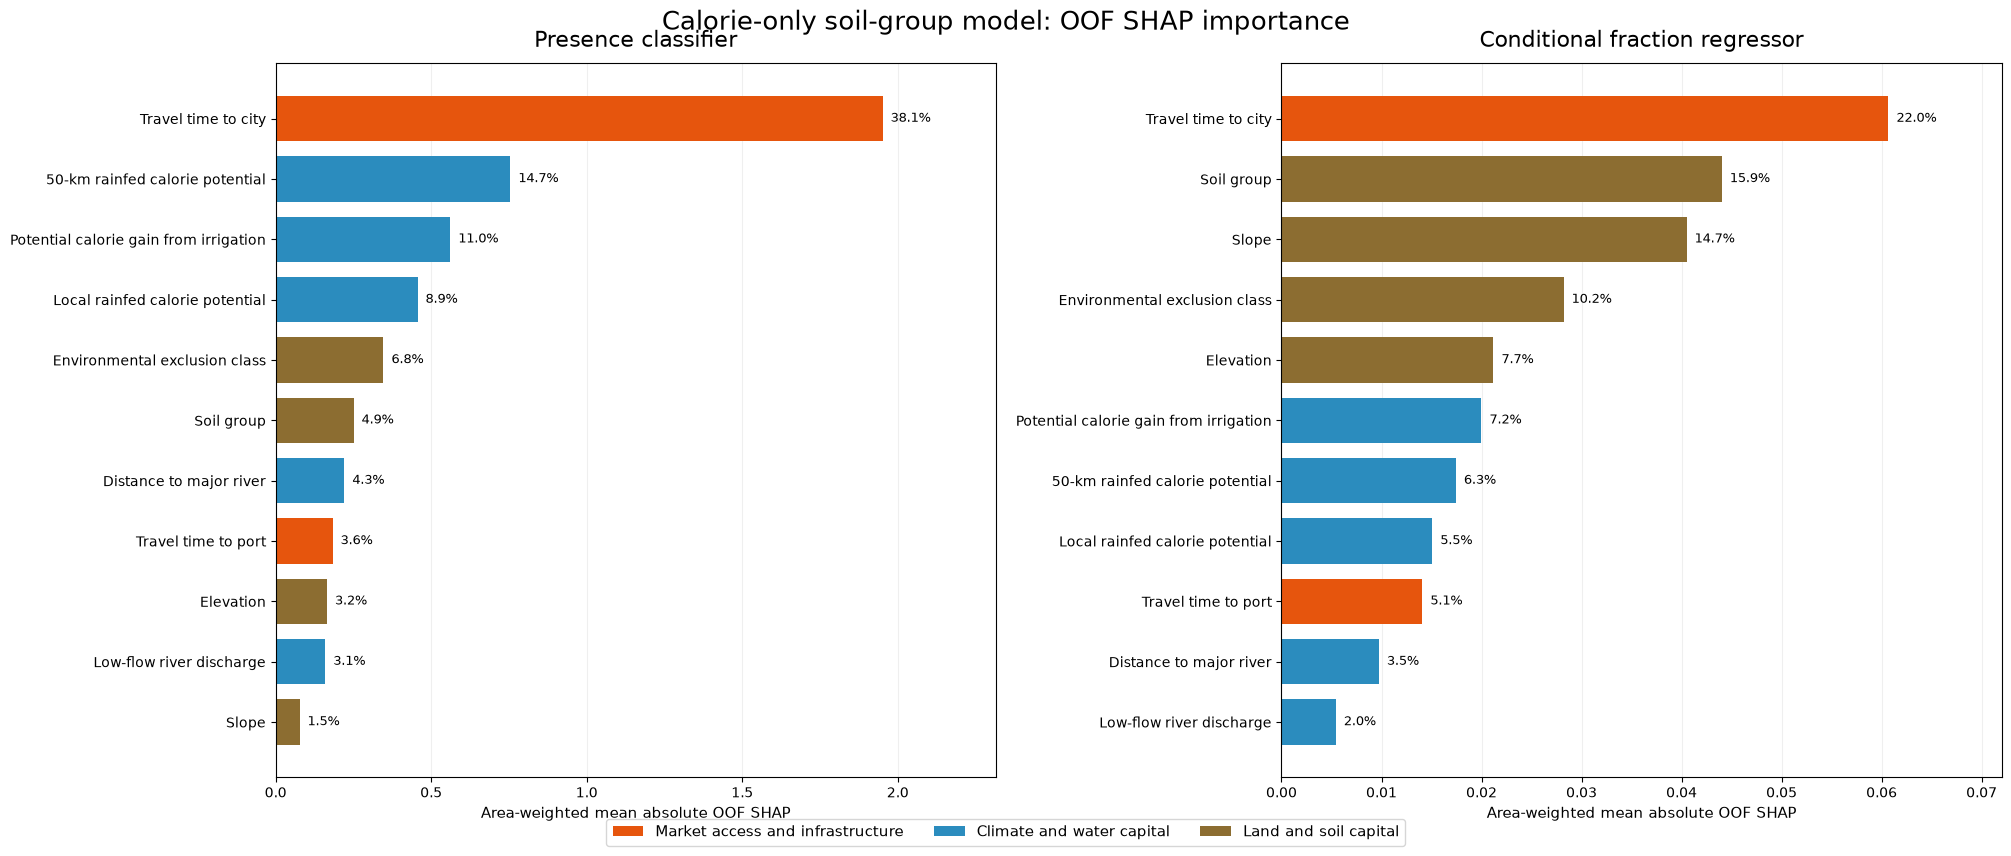

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/individual_feature_oof_shap_factor_colored.png
saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_group_class_oof_shap_summary.csv


,stage,soil_group_class,soil_group,n,mean_signed_shap,mean_abs_shap
5,conditional_fraction_regressor,6,Chernozems,2482,0.197646,0.197646
29,conditional_fraction_regressor,31,Technosols,128,-0.091723,0.091723
20,conditional_fraction_regressor,22,Phaeozems,3156,0.085516,0.085541
23,conditional_fraction_regressor,25,Podzols,1473,-0.078487,0.078487
10,conditional_fraction_regressor,11,Ferralsols,3269,-0.077882,0.077882
...,...,...,...,...,...,...
50,presence_classifier,20,Lixisols,743,0.039884,0.124900
57,presence_classifier,27,Retisols,1232,0.040002,0.113427
48,presence_classifier,18,Leptosols,4913,-0.061590,0.103072
49,presence_classifier,19,Luvisols,3567,0.034936,0.083430


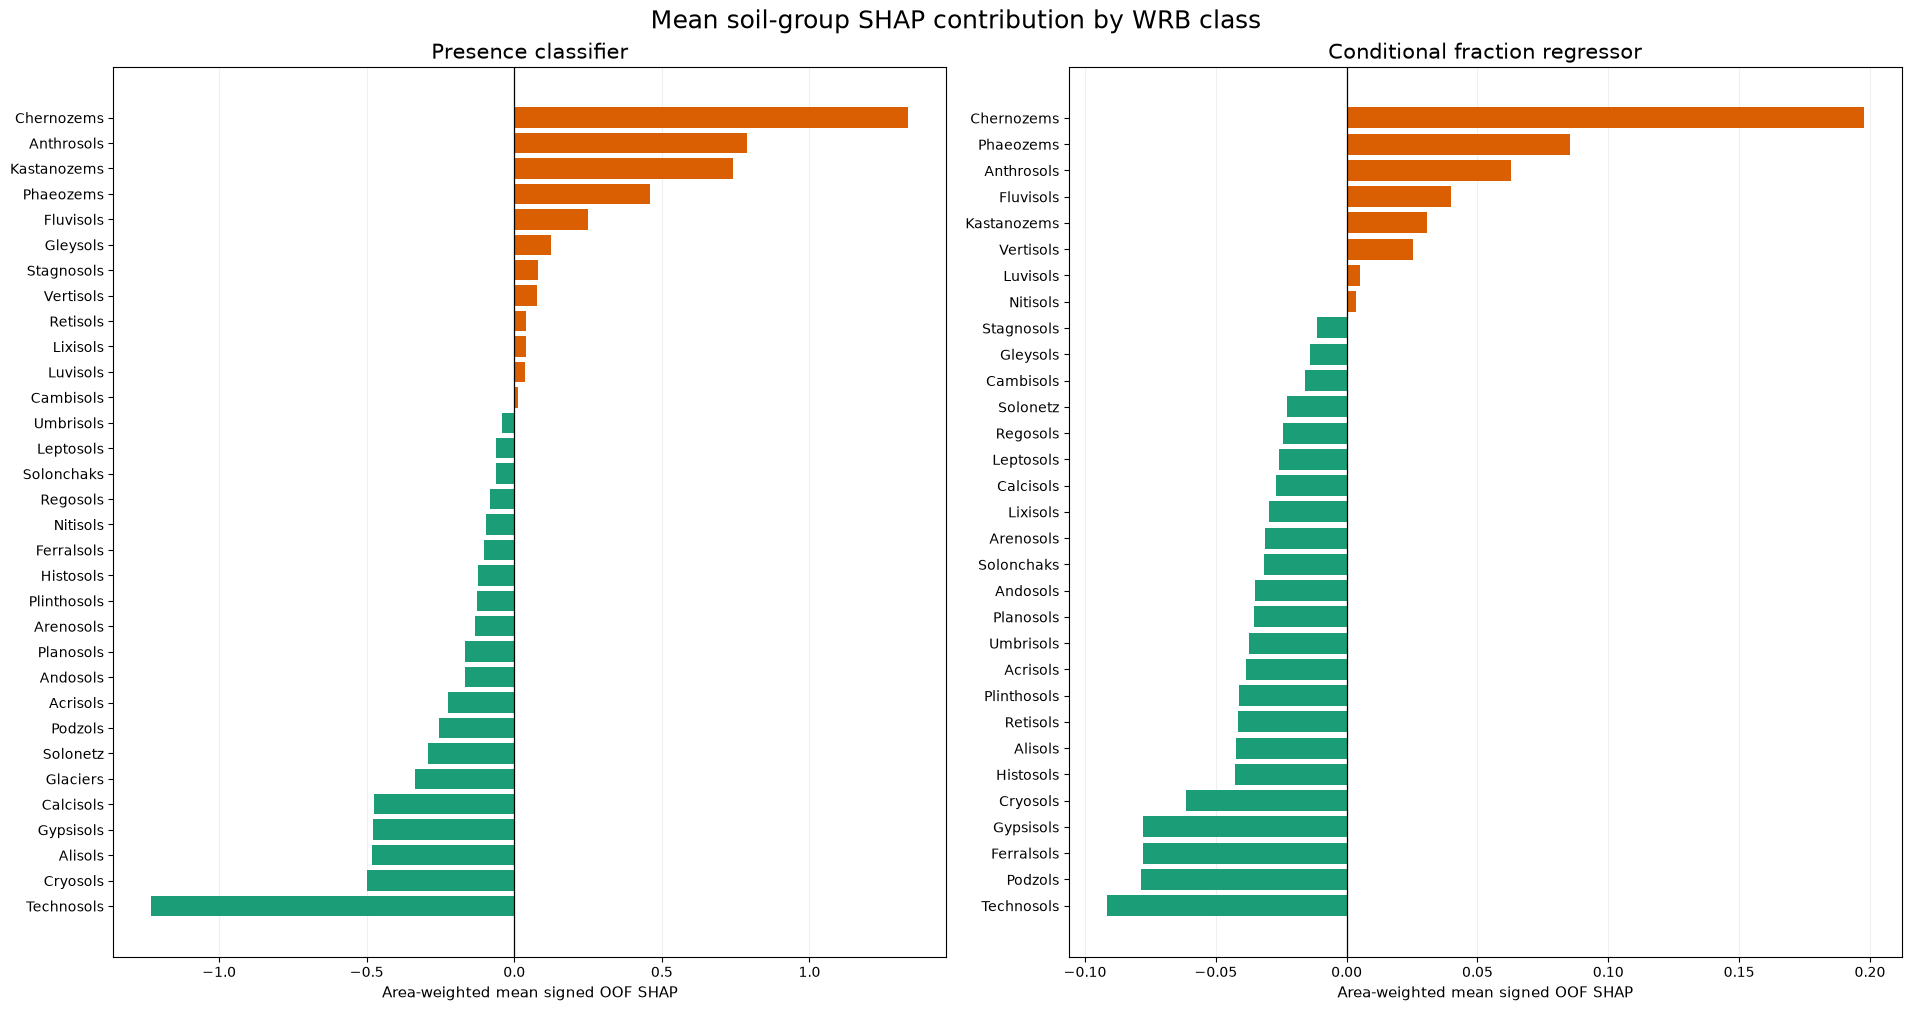

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_group_signed_oof_shap.png


In [10]:
# ============================================================
# 10. 個別変数のOOF SHAP重要度と土壌群別寄与
# ============================================================

from pathlib import Path
from matplotlib.patches import Patch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


OUTPUT_DIR = Path(OUTPUT_DIR)


# ------------------------------------------------------------
# 1. 生産要素グループの定義
# ------------------------------------------------------------

FACTOR_GROUPS = {
    "Climate and water capital": [
        "log_glofas_p10_2020",
        "log_distance_river_gt10_2020",
        "rainfed_calorie_top5_raw",
        "wx_50km_rainfed_calorie_top5_raw",
        "irrigation_calorie_gain_top5_raw",
    ],

    "Land and soil capital": [
        "elevation_m",
        "slope",
        "exclusion_class",
        "soil_group_class",
    ],

    "Market access and infrastructure": [
        "log_city_time_20k_min",
        "log_port_time_any_min",
    ],
}


# ------------------------------------------------------------
# 2. セクション12と共通の色
# ------------------------------------------------------------

FACTOR_COLORS = {
    "Climate and water capital": "#2B8CBE",          # 青
    "Land and soil capital": "#8C6D31",             # 茶
    "Market access and infrastructure": "#E6550D",  # 橙
}


# 説明変数から生産要素グループへの対応
FEATURE_TO_FACTOR = {
    feature: factor_group
    for factor_group, features in FACTOR_GROUPS.items()
    for feature in features
}


# ------------------------------------------------------------
# 3. グラフ表示用の変数名
# ------------------------------------------------------------

FEATURE_LABELS = {
    "elevation_m": "Elevation",
    "slope": "Slope",
    "exclusion_class": "Environmental exclusion class",
    "soil_group_class": "Soil group",

    "rainfed_calorie_top5_raw":
        "Local rainfed calorie potential",

    "wx_50km_rainfed_calorie_top5_raw":
        "50-km rainfed calorie potential",

    "irrigation_calorie_gain_top5_raw":
        "Potential calorie gain from irrigation",

    "log_distance_river_gt10_2020":
        "Distance to major river",

    "log_glofas_p10_2020":
        "Low-flow river discharge",

    "log_city_time_20k_min":
        "Travel time to city",

    "log_port_time_any_min":
        "Travel time to port",
}


# ------------------------------------------------------------
# 4. OOF SHAPの全fold集計
# ------------------------------------------------------------

shap_summary = (
    shap_fold_summary
    .groupby(
        ["model", "stage", "feature"],
        as_index=False,
    )[
        [
            "sum_weight",
            "sum_abs_shap_weighted",
            "sum_signed_shap_weighted",
            "n",
        ]
    ]
    .sum()
)


# 面積加重mean absolute SHAP
shap_summary["mean_abs_shap"] = (
    shap_summary["sum_abs_shap_weighted"]
    / shap_summary["sum_weight"]
)


# 面積加重mean signed SHAP
shap_summary["mean_signed_shap"] = (
    shap_summary["sum_signed_shap_weighted"]
    / shap_summary["sum_weight"]
)


# 同じ段階における個別変数の重要度構成比
shap_summary["relative_importance_share"] = (
    shap_summary["mean_abs_shap"]
    / shap_summary
        .groupby("stage")["mean_abs_shap"]
        .transform("sum")
)


# 各変数に生産要素グループを付ける
shap_summary["factor_group"] = (
    shap_summary["feature"].map(FEATURE_TO_FACTOR)
)


# 表示用ラベル
shap_summary["feature_label"] = (
    shap_summary["feature"]
    .map(FEATURE_LABELS)
    .fillna(shap_summary["feature"])
)


# グループ定義漏れを確認
missing_group_features = (
    shap_summary.loc[
        shap_summary["factor_group"].isna(),
        "feature",
    ]
    .drop_duplicates()
    .tolist()
)

if missing_group_features:
    raise ValueError(
        "FACTOR_GROUPSに登録されていない説明変数があります："
        f"{missing_group_features}"
    )


# CSV保存
SHAP_SUMMARY_PATH = (
    OUTPUT_DIR
    / "soil_model_oof_shap_summary.csv"
)

shap_summary.to_csv(
    SHAP_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("saved:", SHAP_SUMMARY_PATH)


# 集計表を表示
display(
    shap_summary
    .sort_values(
        ["stage", "mean_abs_shap"],
        ascending=[True, False],
    )[
        [
            "stage",
            "feature",
            "factor_group",
            "mean_abs_shap",
            "mean_signed_shap",
            "relative_importance_share",
        ]
    ]
    .round(6)
)


# ------------------------------------------------------------
# 5. 要素別に色分けした個別変数OOF SHAP重要度
# ------------------------------------------------------------

STAGES = [
    "presence_classifier",
    "conditional_fraction_regressor",
]

STAGE_TITLES = {
    "presence_classifier":
        "Presence classifier",

    "conditional_fraction_regressor":
        "Conditional fraction regressor",
}


fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 8),
    constrained_layout=True,
)


for ax, stage in zip(axes, STAGES):

    plot_frame = (
        shap_summary[
            shap_summary["stage"].eq(stage)
        ]
        .copy()
        .sort_values(
            "mean_abs_shap",
            ascending=True,
        )
    )

    bar_colors = (
        plot_frame["factor_group"]
        .map(FACTOR_COLORS)
        .tolist()
    )

    bars = ax.barh(
        plot_frame["feature_label"],
        plot_frame["mean_abs_shap"],
        color=bar_colors,
        edgecolor="none",
        height=0.75,
    )

    # 各棒の右側に重要度構成比を表示
    for bar, importance_share in zip(
        bars,
        plot_frame["relative_importance_share"],
    ):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f"  {100 * importance_share:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
        )

    ax.set_title(
        STAGE_TITLES[stage],
        fontsize=16,
        pad=12,
    )

    ax.set_xlabel(
        "Area-weighted mean absolute OOF SHAP",
        fontsize=11,
    )

    ax.grid(
        axis="x",
        alpha=0.20,
        linewidth=0.8,
    )

    ax.set_axisbelow(True)
    ax.tick_params(axis="both", labelsize=10)

    # 数値ラベル用の余白
    left_limit, right_limit = ax.get_xlim()
    ax.set_xlim(
        left_limit,
        right_limit * 1.13,
    )


# 共通凡例
legend_handles = [
    Patch(
        facecolor=FACTOR_COLORS[
            "Market access and infrastructure"
        ],
        label="Market access and infrastructure",
    ),
    Patch(
        facecolor=FACTOR_COLORS[
            "Climate and water capital"
        ],
        label="Climate and water capital",
    ),
    Patch(
        facecolor=FACTOR_COLORS[
            "Land and soil capital"
        ],
        label="Land and soil capital",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.035),
    ncol=3,
    frameon=True,
    fontsize=11,
)

fig.suptitle(
    "Calorie-only soil-group model: OOF SHAP importance",
    fontsize=19,
    y=1.02,
)


INDIVIDUAL_SHAP_FIG_PATH = (
    OUTPUT_DIR
    / "individual_feature_oof_shap_factor_colored.png"
)

fig.savefig(
    INDIVIDUAL_SHAP_FIG_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("saved:", INDIVIDUAL_SHAP_FIG_PATH)


# ------------------------------------------------------------
# 6. 土壌群別のSHAP寄与
# ------------------------------------------------------------

soil_local_shap = soil_local_shap.copy()

soil_local_shap["soil_group"] = (
    soil_local_shap["soil_group_class"]
    .map(SOIL_LABELS)
)


soil_group_rows = []


for (
    stage,
    code_value,
    soil_group_label,
), group in soil_local_shap.groupby(
    [
        "stage",
        "soil_group_class",
        "soil_group",
    ],
    dropna=False,
):

    weights = pd.to_numeric(
        group["weight"],
        errors="coerce",
    ).to_numpy(dtype=float)

    values = pd.to_numeric(
        group["soil_group_shap"],
        errors="coerce",
    ).to_numpy(dtype=float)

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if valid.sum() == 0:
        mean_signed_shap = np.nan
        mean_abs_shap = np.nan
    else:
        mean_signed_shap = float(
            np.average(
                values[valid],
                weights=weights[valid],
            )
        )

        mean_abs_shap = float(
            np.average(
                np.abs(values[valid]),
                weights=weights[valid],
            )
        )

    soil_group_rows.append({
        "stage": stage,
        "soil_group_class": int(code_value),
        "soil_group": soil_group_label,
        "n": int(valid.sum()),
        "mean_signed_shap": mean_signed_shap,
        "mean_abs_shap": mean_abs_shap,
    })


soil_group_shap_summary = pd.DataFrame(
    soil_group_rows
)


SOIL_GROUP_SUMMARY_PATH = (
    OUTPUT_DIR
    / "soil_group_class_oof_shap_summary.csv"
)

soil_group_shap_summary.to_csv(
    SOIL_GROUP_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("saved:", SOIL_GROUP_SUMMARY_PATH)


display(
    soil_group_shap_summary
    .sort_values(
        ["stage", "mean_abs_shap"],
        ascending=[True, False],
    )
    .round(6)
)


# ------------------------------------------------------------
# 7. 土壌群別の平均signed OOF SHAPを描画
#
# この図では「生産要素グループ」ではなく、
# 各土壌クラスがプラスかマイナスかを表示するので、
# 正負によって色分けする
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(19, 10),
    constrained_layout=True,
)


for ax, stage in zip(axes, STAGES):

    plot_frame = (
        soil_group_shap_summary[
            soil_group_shap_summary["stage"].eq(stage)
            & soil_group_shap_summary["n"].ge(30)
        ]
        .copy()
        .sort_values(
            "mean_signed_shap",
            ascending=True,
        )
    )

    sign_colors = np.where(
        plot_frame["mean_signed_shap"] >= 0,
        "#D95F02",  # プラス
        "#1B9E77",  # マイナス
    )

    ax.barh(
        plot_frame["soil_group"],
        plot_frame["mean_signed_shap"],
        color=sign_colors,
        edgecolor="none",
    )

    ax.axvline(
        0,
        color="black",
        linewidth=0.9,
    )

    ax.set_title(
        STAGE_TITLES[stage],
        fontsize=15,
    )

    ax.set_xlabel(
        "Area-weighted mean signed OOF SHAP",
        fontsize=11,
    )

    ax.grid(
        axis="x",
        alpha=0.20,
    )

    ax.set_axisbelow(True)


fig.suptitle(
    "Mean soil-group SHAP contribution by WRB class",
    fontsize=18,
)


SOIL_GROUP_FIG_PATH = (
    OUTPUT_DIR
    / "soil_group_signed_oof_shap.png"
)

fig.savefig(
    SOIL_GROUP_FIG_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("saved:", SOIL_GROUP_FIG_PATH)

## 11. 採用モデルの確認

## 12. 生産要素グループ別OOF SHAP

local SHAP rows: 100,000
presence_classifier: maximum grouping additivity error = 0.0000000000
conditional_fraction_regressor: maximum grouping additivity error = 0.0000000000


,stage,factor_group,n_features,corrected_group_mean_abs_shap,group_mean_signed_shap,old_sum_individual_mean_abs_shap,old_to_corrected_ratio,within_group_cancellation_percent,importance_share_percent
0,conditional_fraction_regressor,Climate and water capital,5,0.0375,-0.0035,0.0677,1.8048,44.5911,20.0825
1,conditional_fraction_regressor,Land and soil capital,4,0.0881,-0.0106,0.1339,1.5201,34.2165,47.1791
2,conditional_fraction_regressor,Market access and infrastructure,2,0.0611,0.0004,0.0748,1.2229,18.2301,32.7383
3,presence_classifier,Climate and water capital,5,1.5619,-0.0735,2.1523,1.3780,27.4315,37.8457
4,presence_classifier,Land and soil capital,4,0.5206,-0.1069,0.8386,1.6108,37.9209,12.6145
5,presence_classifier,Market access and infrastructure,2,2.0445,0.1610,2.1342,1.0438,4.1997,49.5398


saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_model_oof_shap_factor_groups_corrected.csv
saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_model_oof_local_group_shap.csv.gz


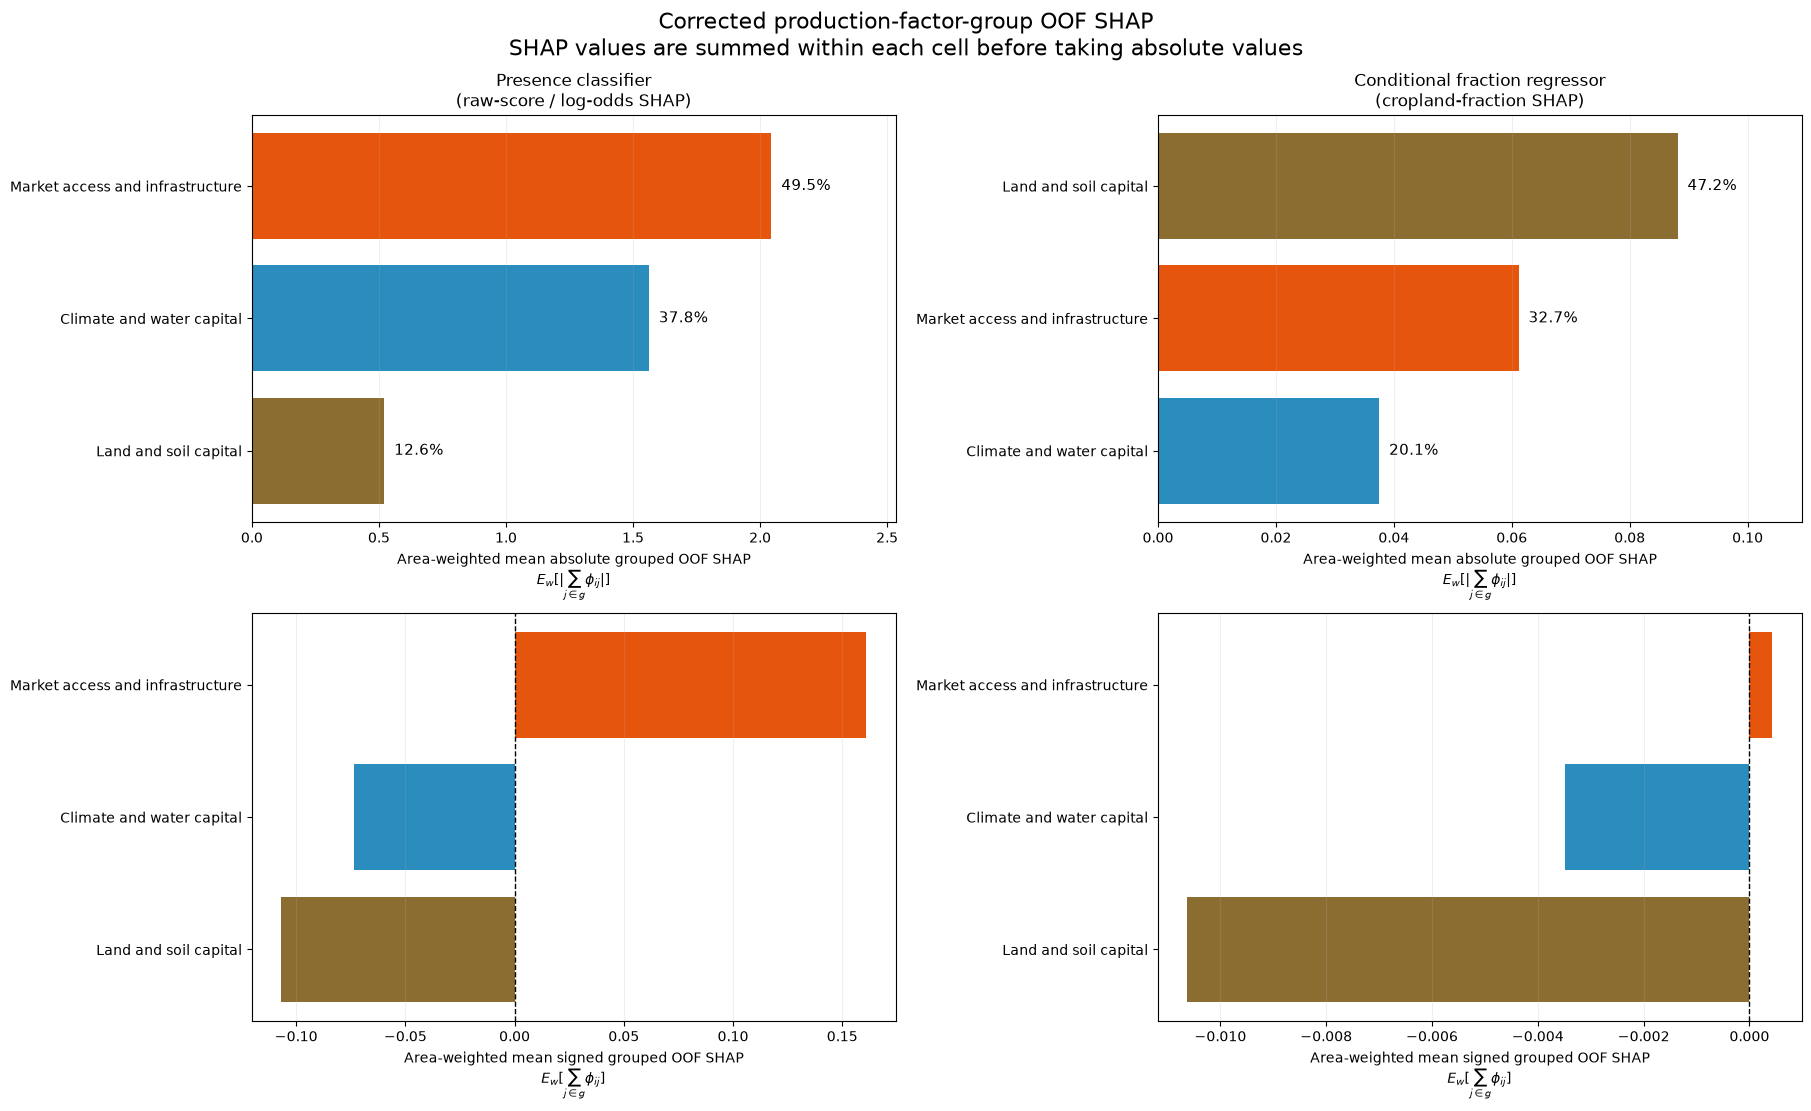

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/factor_group_oof_shap_corrected.png


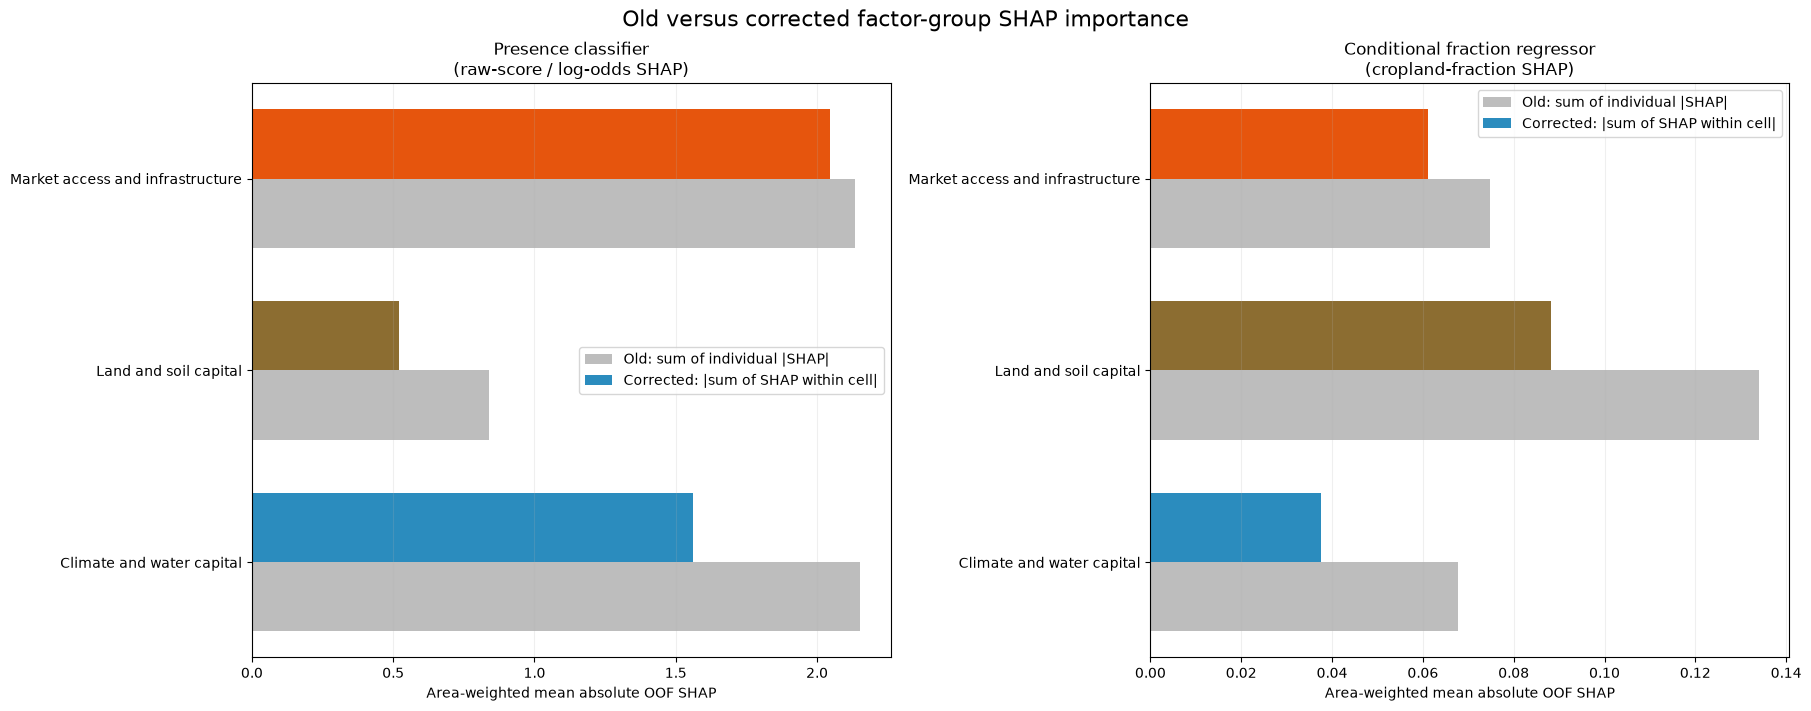

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/factor_group_oof_shap_old_vs_corrected.png


In [11]:
# ============================================================
# 修正版：各セルでグループ内SHAPを合計してから重要度を計算
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 生産要素グループ
# ------------------------------------------------------------

FACTOR_GROUPS = {
    "Climate and water capital": [
        "log_glofas_p10_2020",
        "log_distance_river_gt10_2020",
        "rainfed_calorie_top5_raw",
        "wx_50km_rainfed_calorie_top5_raw",
        "irrigation_calorie_gain_top5_raw",
    ],
    "Land and soil capital": [
        "elevation_m",
        "slope",
        "exclusion_class",
        "soil_group_class",
    ],
    "Market access and infrastructure": [
        "log_city_time_20k_min",
        "log_port_time_any_min",
    ],
}

FACTOR_ORDER = list(FACTOR_GROUPS)

FACTOR_COLORS = {
    "Climate and water capital": "#2B8CBE",
    "Land and soil capital": "#8C6D31",
    "Market access and infrastructure": "#E6550D",
}

STAGES = [
    "presence_classifier",
    "conditional_fraction_regressor",
]

STAGE_TITLES = {
    "presence_classifier": (
        "Presence classifier\n"
        "(raw-score / log-odds SHAP)"
    ),
    "conditional_fraction_regressor": (
        "Conditional fraction regressor\n"
        "(cropland-fraction SHAP)"
    ),
}


# ------------------------------------------------------------
# 2. ローカルOOF SHAPを読み込む
# ------------------------------------------------------------

OUTPUT_DIR = Path(OUTPUT_DIR)

LOCAL_SHAP_PATH = (
    OUTPUT_DIR
    / "soil_model_oof_local_feature_shap.csv.gz"
)

if "local_feature_shap" not in globals():
    print("load:", LOCAL_SHAP_PATH)

    local_feature_shap = pd.read_csv(
        LOCAL_SHAP_PATH,
        compression="gzip",
    )
else:
    local_feature_shap = local_feature_shap.copy()

print("local SHAP rows:", f"{len(local_feature_shap):,}")


# ------------------------------------------------------------
# 3. グループと説明変数の対応確認
# ------------------------------------------------------------

group_features = [
    feature
    for features in FACTOR_GROUPS.values()
    for feature in features
]

if len(group_features) != len(set(group_features)):
    raise ValueError(
        "同じ説明変数が複数のグループに含まれています。"
    )

required_shap_columns = [
    f"shap__{feature}"
    for feature in group_features
]

missing_columns = [
    column
    for column in required_shap_columns
    if column not in local_feature_shap.columns
]

if missing_columns:
    raise KeyError(
        "ローカルSHAPデータに必要な列がありません："
        f"{missing_columns}"
    )


# ------------------------------------------------------------
# 4. 面積加重平均関数
# ------------------------------------------------------------

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if valid.sum() == 0:
        return np.nan

    return float(
        np.average(
            values[valid],
            weights=weights[valid],
        )
    )


# ------------------------------------------------------------
# 5. 各セルでグループSHAPを計算
#
# corrected:
#   E[ | Σ_j SHAP_ij | ]
#
# old:
#   Σ_j E[ | SHAP_ij | ]
# ------------------------------------------------------------

group_result_rows = []
local_group_frames = []

for stage in STAGES:

    stage_df = local_feature_shap[
        local_feature_shap["stage"].eq(stage)
    ].copy()

    if stage_df.empty:
        print("skip empty stage:", stage)
        continue

    weights = pd.to_numeric(
        stage_df["weight"],
        errors="coerce",
    ).to_numpy(dtype=float)

    local_metadata = stage_df[
        ["stage", "fold", "row", "col", "lat", "lon", "weight"]
    ].copy()

    # 全説明変数のSHAP合計
    all_feature_shap = stage_df[
        required_shap_columns
    ].to_numpy(dtype=float)

    total_feature_shap = np.sum(
        all_feature_shap,
        axis=1,
    )

    total_group_shap = np.zeros(
        len(stage_df),
        dtype=float,
    )

    for factor_group, features in FACTOR_GROUPS.items():

        shap_columns = [
            f"shap__{feature}"
            for feature in features
        ]

        individual_shap = stage_df[
            shap_columns
        ].to_numpy(dtype=float)

        # 重要：各セル内で先にSHAPを合計
        group_signed_shap = np.sum(
            individual_shap,
            axis=1,
        )

        total_group_shap += group_signed_shap

        local_metadata[
            f"group_shap__{factor_group}"
        ] = group_signed_shap.astype(np.float32)

        # 修正版
        corrected_mean_abs = weighted_mean(
            np.abs(group_signed_shap),
            weights,
        )

        mean_signed = weighted_mean(
            group_signed_shap,
            weights,
        )

        # 旧方式：個別変数の絶対SHAPをそれぞれ計算して合計
        old_sum_mean_abs = sum(
            weighted_mean(
                np.abs(individual_shap[:, j]),
                weights,
            )
            for j in range(individual_shap.shape[1])
        )

        if (
            np.isfinite(old_sum_mean_abs)
            and old_sum_mean_abs > 0
        ):
            cancellation_percent = 100 * (
                1
                - corrected_mean_abs
                / old_sum_mean_abs
            )
            old_to_corrected_ratio = (
                old_sum_mean_abs
                / corrected_mean_abs
                if corrected_mean_abs > 0
                else np.nan
            )
        else:
            cancellation_percent = np.nan
            old_to_corrected_ratio = np.nan

        group_result_rows.append({
            "stage": stage,
            "factor_group": factor_group,
            "n_features": len(features),

            # 修正版のグループ重要度
            "corrected_group_mean_abs_shap": (
                corrected_mean_abs
            ),

            # グループの平均的な方向
            "group_mean_signed_shap": mean_signed,

            # 旧方式との比較
            "old_sum_individual_mean_abs_shap": (
                old_sum_mean_abs
            ),
            "old_to_corrected_ratio": (
                old_to_corrected_ratio
            ),
            "within_group_cancellation_percent": (
                cancellation_percent
            ),
        })

    # グループ化前後のSHAP合計が一致するか確認
    additivity_error = np.nanmax(
        np.abs(
            total_feature_shap
            - total_group_shap
        )
    )

    print(
        f"{stage}: maximum grouping additivity error = "
        f"{additivity_error:.10f}"
    )

    if additivity_error > 1e-5:
        raise RuntimeError(
            f"グループSHAPの加法性が成立していません："
            f"{stage}, error={additivity_error}"
        )

    local_group_frames.append(local_metadata)


# ------------------------------------------------------------
# 6. 結果表
# ------------------------------------------------------------

corrected_group_shap = pd.DataFrame(
    group_result_rows
)

corrected_group_shap[
    "importance_share_percent"
] = (
    100
    * corrected_group_shap[
        "corrected_group_mean_abs_shap"
    ]
    / corrected_group_shap.groupby(
        "stage"
    )[
        "corrected_group_mean_abs_shap"
    ].transform("sum")
)

corrected_group_shap[
    "factor_group"
] = pd.Categorical(
    corrected_group_shap["factor_group"],
    categories=FACTOR_ORDER,
    ordered=True,
)

corrected_group_shap = (
    corrected_group_shap
    .sort_values(["stage", "factor_group"])
    .reset_index(drop=True)
)

local_group_shap = pd.concat(
    local_group_frames,
    ignore_index=True,
)

display(
    corrected_group_shap.round(4)
)


# ------------------------------------------------------------
# 7. CSV保存
# ------------------------------------------------------------

CORRECTED_CSV = (
    OUTPUT_DIR
    / "soil_model_oof_shap_factor_groups_corrected.csv"
)

LOCAL_GROUP_CSV = (
    OUTPUT_DIR
    / "soil_model_oof_local_group_shap.csv.gz"
)

corrected_group_shap.to_csv(
    CORRECTED_CSV,
    index=False,
    encoding="utf-8-sig",
)

local_group_shap.to_csv(
    LOCAL_GROUP_CSV,
    index=False,
    compression="gzip",
)

print("saved:", CORRECTED_CSV)
print("saved:", LOCAL_GROUP_CSV)


# ------------------------------------------------------------
# 8. 修正版のグループ重要度と平均signed SHAP
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 11),
    constrained_layout=True,
)

for column_index, stage in enumerate(STAGES):

    plot_df = corrected_group_shap[
        corrected_group_shap["stage"].eq(stage)
    ].copy()

    # -----------------------------------------
    # 上段：修正版のmean absolute group SHAP
    # -----------------------------------------

    importance_df = plot_df.sort_values(
        "corrected_group_mean_abs_shap",
        ascending=True,
    )

    ax = axes[0, column_index]

    bars = ax.barh(
        importance_df["factor_group"].astype(str),
        importance_df[
            "corrected_group_mean_abs_shap"
        ],
        color=[
            FACTOR_COLORS[group]
            for group in importance_df["factor_group"].astype(str)
        ],
    )

    for bar, share in zip(
        bars,
        importance_df["importance_share_percent"],
    ):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f"  {share:.1f}%",
            va="center",
            fontsize=11,
        )

    ax.set_title(STAGE_TITLES[stage])
    ax.set_xlabel(
        "Area-weighted mean absolute grouped OOF SHAP\n"
        r"$E_w[|\sum_{j \in g}\phi_{ij}|]$"
    )
    ax.grid(axis="x", alpha=0.2)

    left, right = ax.get_xlim()
    ax.set_xlim(left, right * 1.18)

    # -----------------------------------------
    # 下段：平均signed group SHAP
    # -----------------------------------------

    signed_df = plot_df.sort_values(
        "group_mean_signed_shap",
        ascending=True,
    )

    ax = axes[1, column_index]

    ax.barh(
        signed_df["factor_group"].astype(str),
        signed_df["group_mean_signed_shap"],
        color=[
            FACTOR_COLORS[group]
            for group in signed_df["factor_group"].astype(str)
        ],
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1,
        linestyle="--",
    )

    ax.set_xlabel(
        "Area-weighted mean signed grouped OOF SHAP\n"
        r"$E_w[\sum_{j \in g}\phi_{ij}]$"
    )
    ax.grid(axis="x", alpha=0.2)

fig.suptitle(
    "Corrected production-factor-group OOF SHAP\n"
    "SHAP values are summed within each cell before taking absolute values",
    fontsize=16,
)

CORRECTED_FIG = (
    OUTPUT_DIR
    / "factor_group_oof_shap_corrected.png"
)

fig.savefig(
    CORRECTED_FIG,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("saved:", CORRECTED_FIG)


# ------------------------------------------------------------
# 9. 旧方式と修正版の比較図
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7),
    constrained_layout=True,
)

for ax, stage in zip(axes, STAGES):

    comparison_df = corrected_group_shap[
        corrected_group_shap["stage"].eq(stage)
    ].copy()

    comparison_df = comparison_df.set_index(
        "factor_group"
    ).reindex(FACTOR_ORDER)

    y = np.arange(len(comparison_df))
    height = 0.36

    ax.barh(
        y - height / 2,
        comparison_df[
            "old_sum_individual_mean_abs_shap"
        ],
        height=height,
        color="#BDBDBD",
        label="Old: sum of individual |SHAP|",
    )

    ax.barh(
        y + height / 2,
        comparison_df[
            "corrected_group_mean_abs_shap"
        ],
        height=height,
        color=[
            FACTOR_COLORS[group]
            for group in comparison_df.index
        ],
        label="Corrected: |sum of SHAP within cell|",
    )

    ax.set_yticks(y)
    ax.set_yticklabels(comparison_df.index)
    ax.set_title(STAGE_TITLES[stage])
    ax.set_xlabel("Area-weighted mean absolute OOF SHAP")
    ax.grid(axis="x", alpha=0.2)
    ax.legend()

fig.suptitle(
    "Old versus corrected factor-group SHAP importance",
    fontsize=16,
)

COMPARISON_FIG = (
    OUTPUT_DIR
    / "factor_group_oof_shap_old_vs_corrected.png"
)

fig.savefig(
    COMPARISON_FIG,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("saved:", COMPARISON_FIG)

## 13. 説明変数の値とローカルOOF SHAPの関係

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/feature_shap_dependence/presence_classifier_dependence_page_1.png


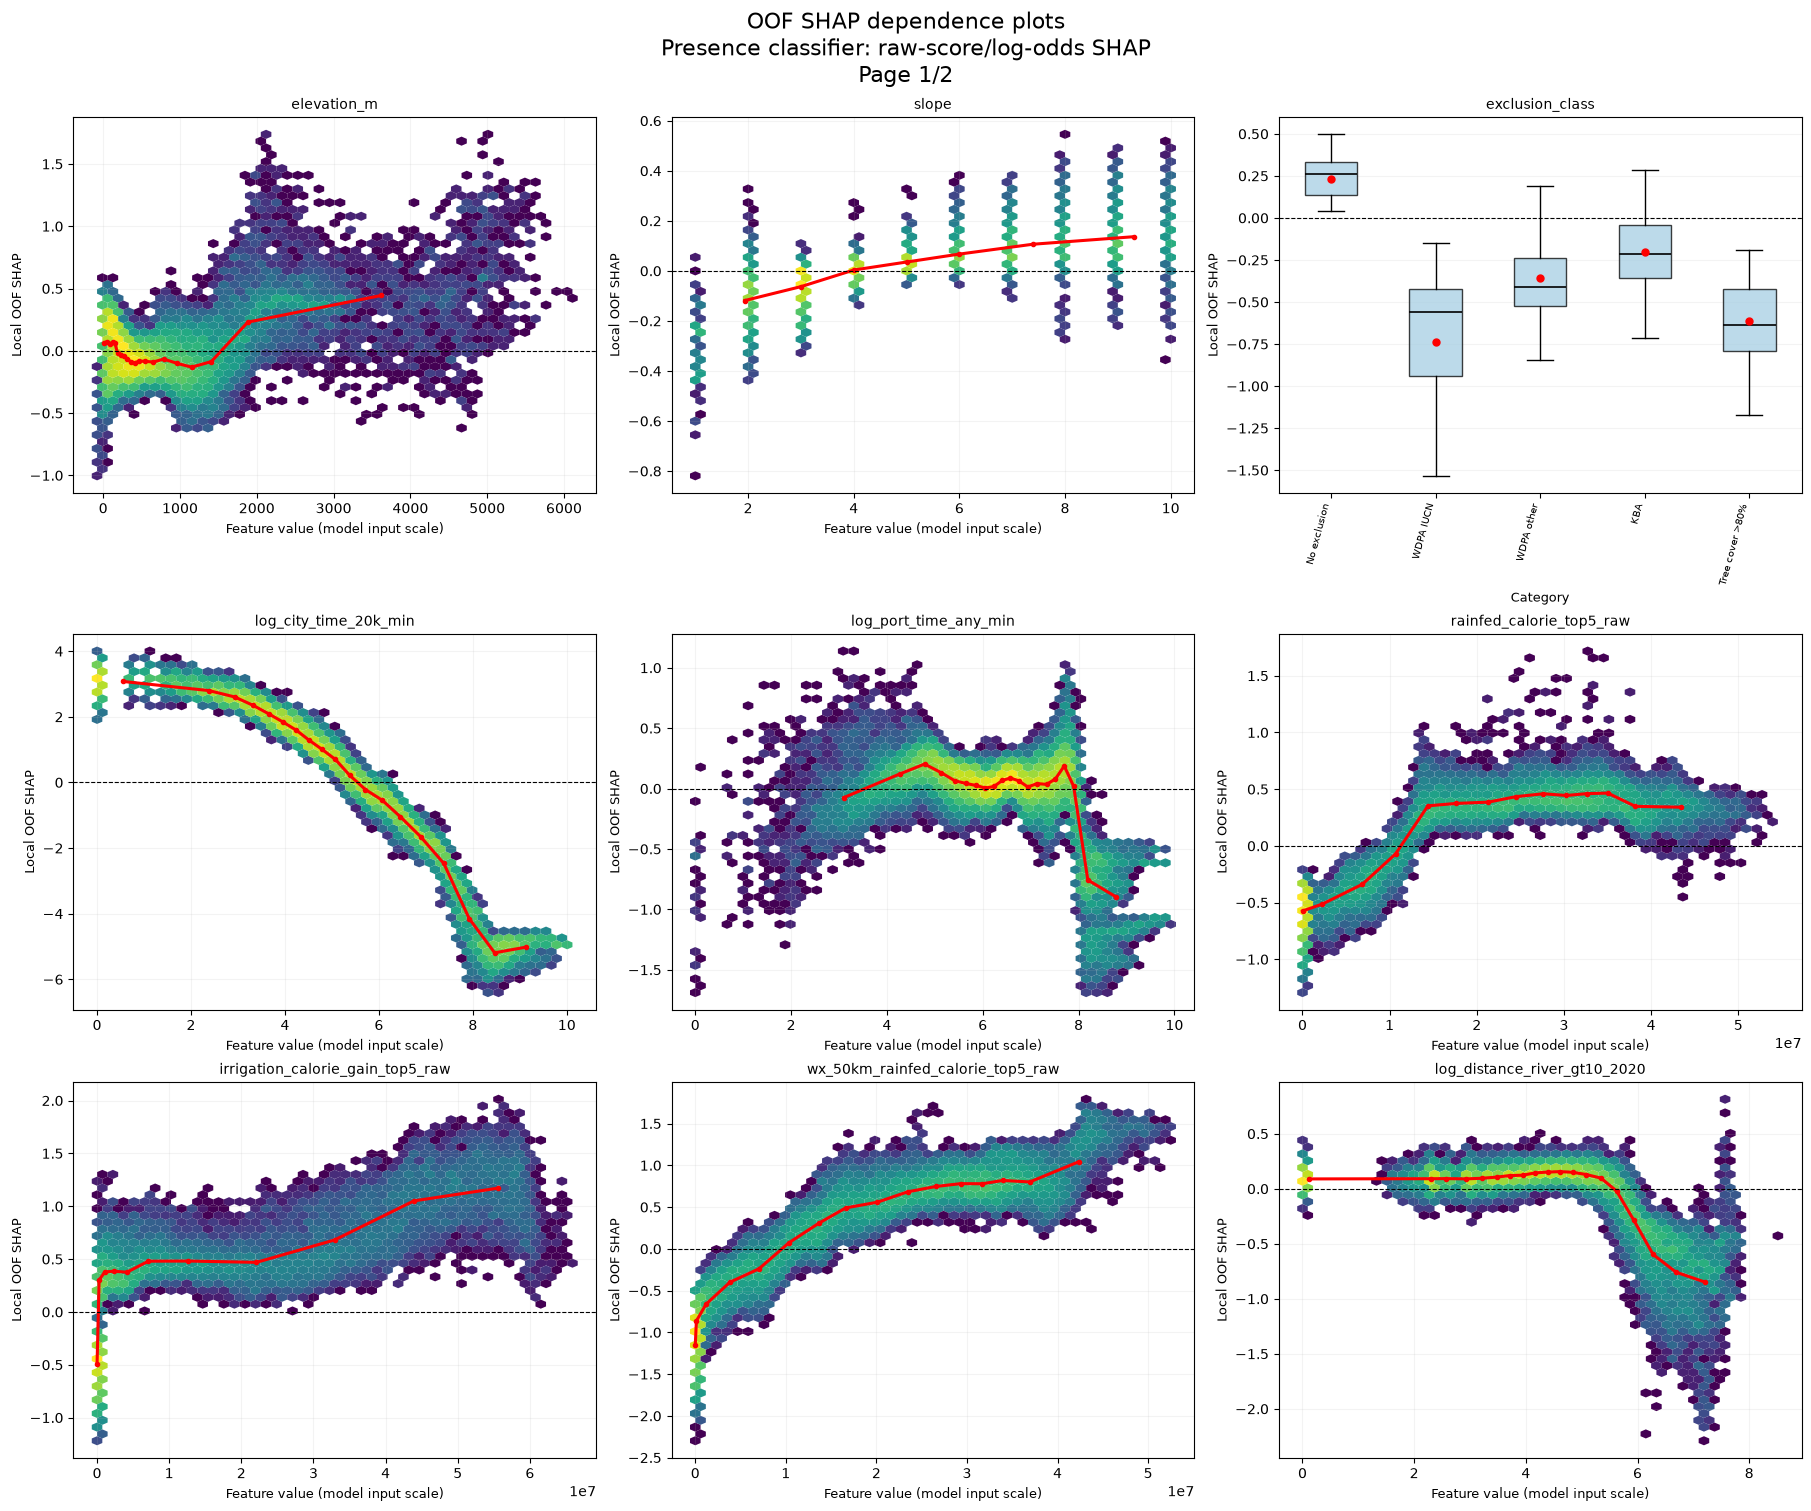

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/feature_shap_dependence/presence_classifier_dependence_page_2.png


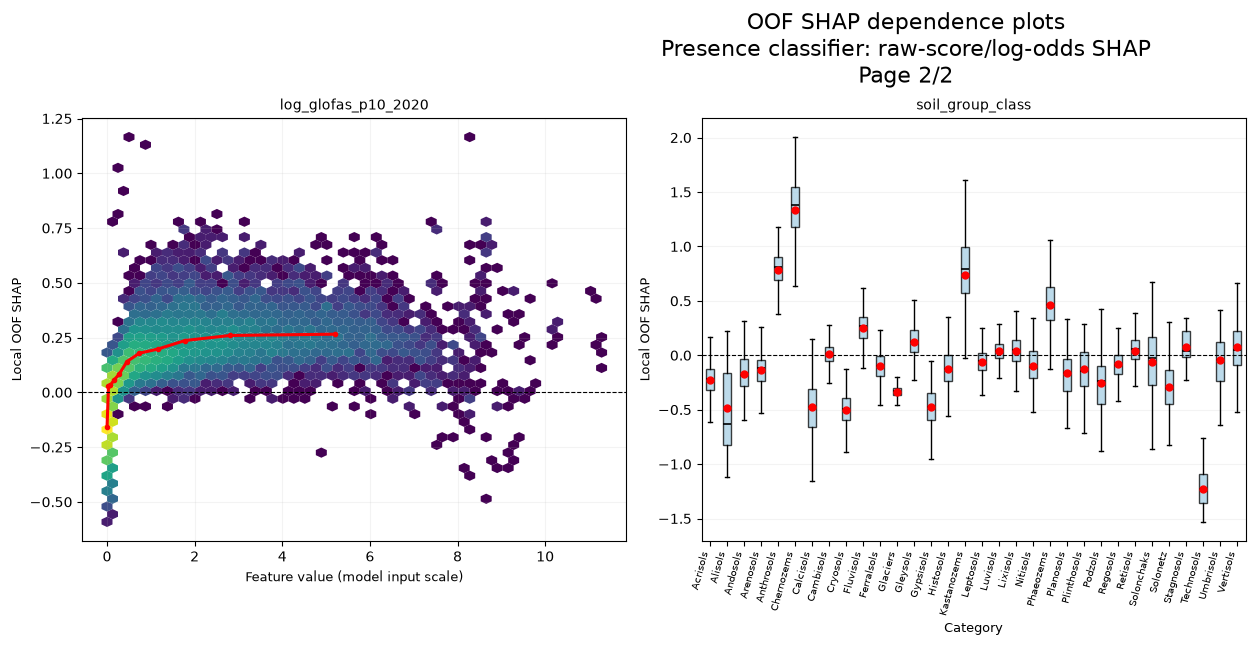

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/feature_shap_dependence/conditional_fraction_regressor_dependence_page_1.png


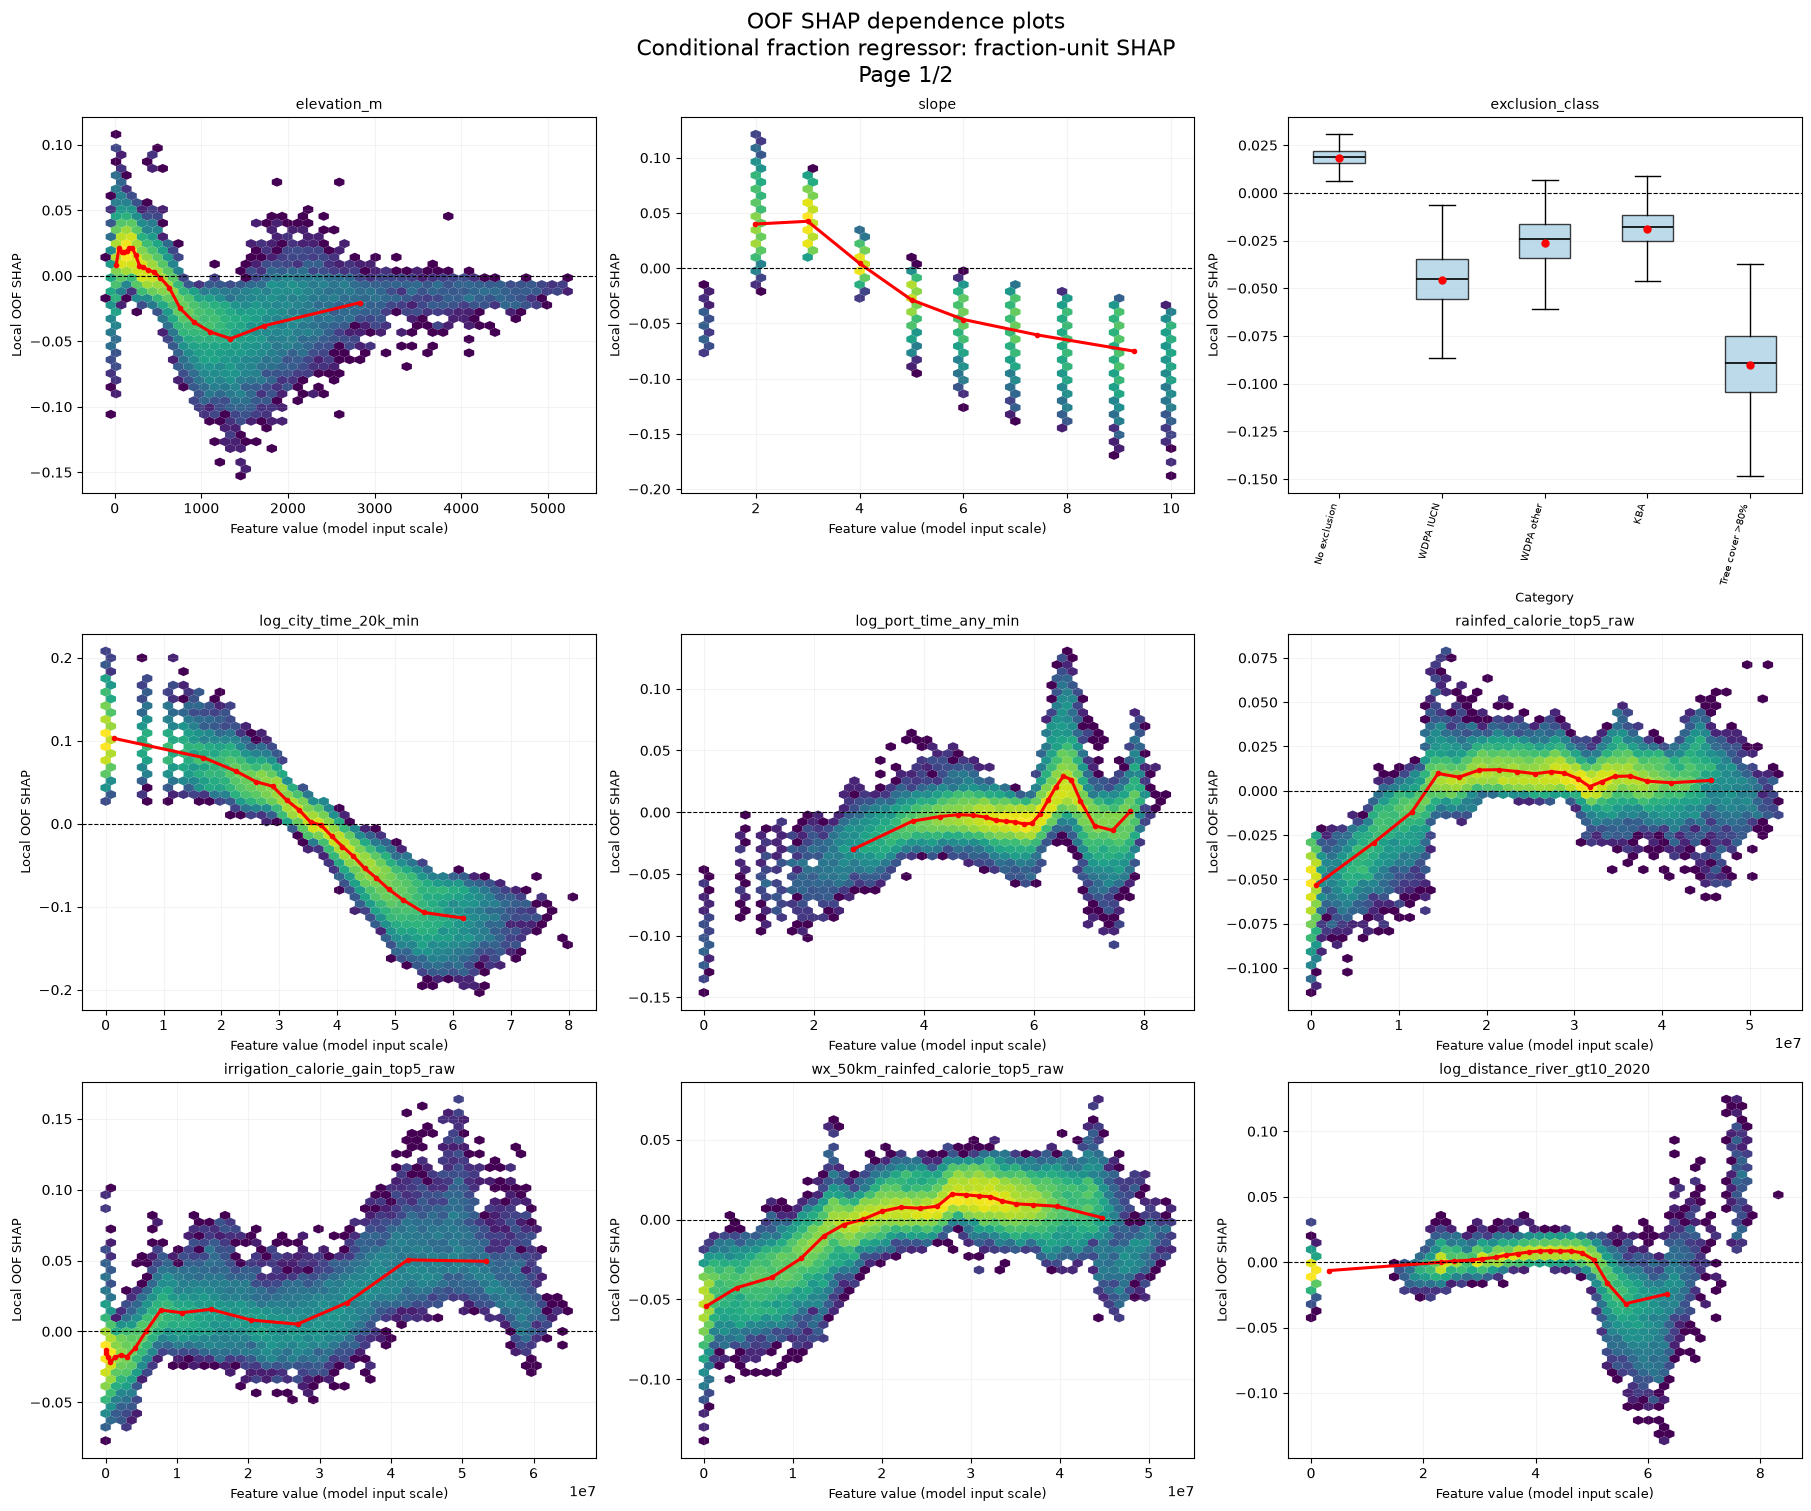

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/feature_shap_dependence/conditional_fraction_regressor_dependence_page_2.png


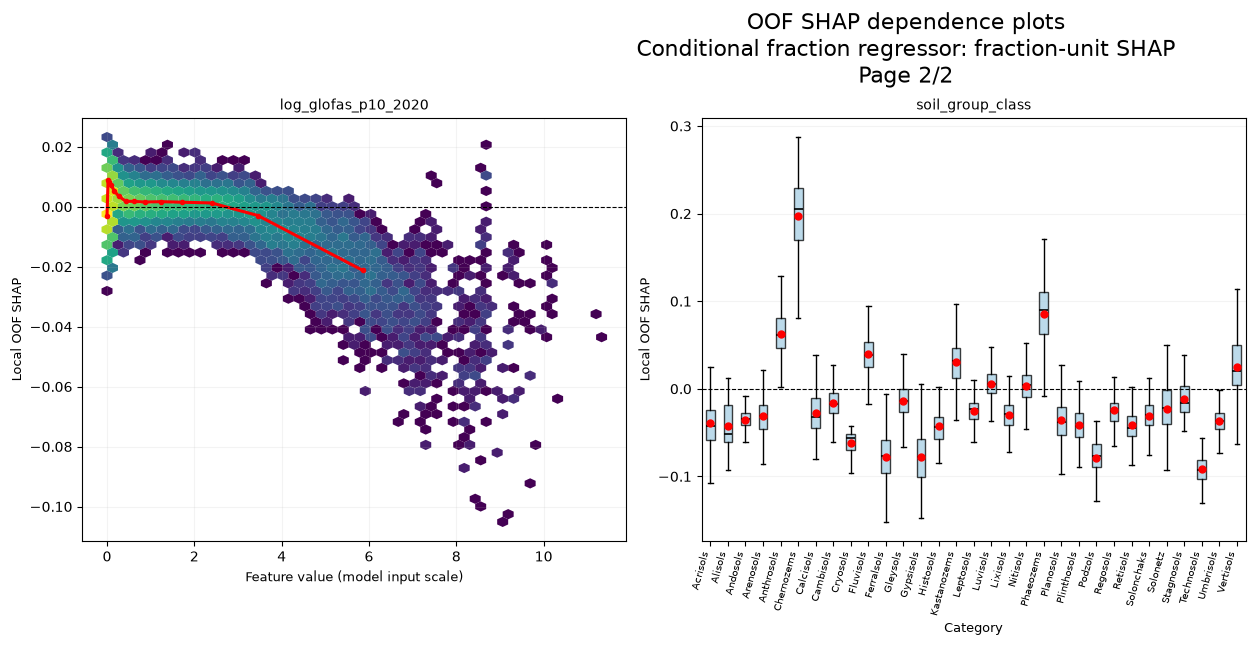

In [12]:
import math

LOCAL_SHAP_PATH = OUTPUT_DIR / "soil_model_oof_local_feature_shap.csv.gz"
if "local_feature_shap" not in globals():
    local_feature_shap = pd.read_csv(LOCAL_SHAP_PATH)

DEPENDENCE_FEATURES = list(MODEL_FEATURES[SOIL_MODEL_NAME])
CATEGORICAL_FEATURES = ["exclusion_class", "soil_group_class"]
N_COLS = 3
N_ROWS = 3
N_BINS = 20
MIN_CATEGORY_N = 20
DEPENDENCE_OUTPUT_DIR = OUTPUT_DIR / "feature_shap_dependence"
DEPENDENCE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUSION_LABELS = {
    1: "No exclusion",
    2: "WDPA IUCN",
    3: "WDPA other",
    4: "KBA",
    5: "Permanent wetland",
    6: "Tree cover >80%",
}
CATEGORY_LABEL_MAPS = {
    "exclusion_class": EXCLUSION_LABELS,
    "soil_group_class": SOIL_LABELS,
}


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not valid.any():
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def binned_curve(frame, feature):
    shap_col = f"shap__{feature}"
    temp = frame[[feature, shap_col, "weight"]].copy()
    for column in [feature, shap_col, "weight"]:
        temp[column] = pd.to_numeric(temp[column], errors="coerce")
    temp = temp.replace([np.inf, -np.inf], np.nan).dropna()
    actual_bins = min(N_BINS, temp[feature].nunique())
    if actual_bins < 2:
        return pd.DataFrame()
    temp["bin"] = pd.qcut(temp[feature], q=actual_bins, duplicates="drop")
    rows = []
    for _, group in temp.groupby("bin", observed=True):
        weight = group["weight"].to_numpy(dtype=float)
        rows.append({
            "x": weighted_mean(group[feature], weight),
            "y": weighted_mean(group[shap_col], weight),
        })
    return pd.DataFrame(rows).sort_values("x")


def plot_continuous(ax, frame, feature):
    shap_col = f"shap__{feature}"
    temp = frame[[feature, shap_col, "weight"]].copy()
    for column in [feature, shap_col, "weight"]:
        temp[column] = pd.to_numeric(temp[column], errors="coerce")
    temp = temp.replace([np.inf, -np.inf], np.nan).dropna()
    ax.hexbin(
        temp[feature],
        temp[shap_col],
        gridsize=45,
        mincnt=1,
        bins="log",
        cmap="viridis",
        linewidths=0,
    )
    curve = binned_curve(temp, feature)
    if not curve.empty:
        ax.plot(curve["x"], curve["y"], color="red", linewidth=2.2, marker="o", markersize=3)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("Feature value (model input scale)", fontsize=9)
    ax.set_ylabel("Local OOF SHAP", fontsize=9)
    ax.grid(alpha=0.15)


def plot_categorical(ax, frame, feature):
    shap_col = f"shap__{feature}"
    temp = frame[[feature, shap_col, "weight"]].copy()
    for column in [feature, shap_col, "weight"]:
        temp[column] = pd.to_numeric(temp[column], errors="coerce")
    temp = temp.replace([np.inf, -np.inf], np.nan).dropna()
    temp[feature] = temp[feature].astype(int)
    counts = temp[feature].value_counts().sort_index()
    categories = counts[counts >= MIN_CATEGORY_N].index.tolist()
    if not categories:
        ax.set_visible(False)
        return
    box_values = []
    means = []
    labels = []
    label_map = CATEGORY_LABEL_MAPS.get(feature, {})
    for category in categories:
        group = temp[temp[feature].eq(category)]
        values = group[shap_col].to_numpy(dtype=float)
        weights = group["weight"].to_numpy(dtype=float)
        box_values.append(values)
        means.append(weighted_mean(values, weights))
        labels.append(label_map.get(category, str(category)))
    positions = np.arange(1, len(categories) + 1)
    ax.boxplot(
        box_values,
        positions=positions,
        showfliers=False,
        patch_artist=True,
        boxprops={"facecolor": "#A6CEE3", "alpha": 0.75},
        medianprops={"color": "black", "linewidth": 1.2},
    )
    ax.scatter(positions, means, color="red", s=25, zorder=5)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=7)
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("Category", fontsize=9)
    ax.set_ylabel("Local OOF SHAP", fontsize=9)
    ax.grid(axis="y", alpha=0.15)


STAGES = ["presence_classifier", "conditional_fraction_regressor"]
STAGE_TITLES = {
    "presence_classifier": "Presence classifier: raw-score/log-odds SHAP",
    "conditional_fraction_regressor": "Conditional fraction regressor: fraction-unit SHAP",
}

for stage in STAGES:
    stage_frame = local_feature_shap[
        local_feature_shap["stage"].eq(stage)
    ].copy()
    per_page = N_COLS * N_ROWS
    n_pages = math.ceil(len(DEPENDENCE_FEATURES) / per_page)
    for page in range(n_pages):
        page_features = DEPENDENCE_FEATURES[
            page * per_page : (page + 1) * per_page
        ]
        fig, axes = plt.subplots(
            N_ROWS,
            N_COLS,
            figsize=(18, 15),
            constrained_layout=True,
        )
        axes = np.asarray(axes).reshape(-1)
        for ax, feature in zip(axes, page_features):
            if feature in CATEGORICAL_FEATURES:
                plot_categorical(ax, stage_frame, feature)
            else:
                plot_continuous(ax, stage_frame, feature)
        for ax in axes[len(page_features):]:
            ax.set_visible(False)
        fig.suptitle(
            f"OOF SHAP dependence plots\n{STAGE_TITLES[stage]}\nPage {page + 1}/{n_pages}",
            fontsize=16,
        )
        path = DEPENDENCE_OUTPUT_DIR / f"{stage}_dependence_page_{page + 1}.png"
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print("saved:", path)
        plt.show()
        plt.close(fig)


## 14 shapを統合

Final model: soil_group_wetland_excluded
Features: 11
Factor groups: ['Land and soil capital', 'Climate and water capital', 'Market access and infrastructure']
Coalitions: 8
INTEGRATED FINAL SHAPLEY: fold 1/5


  background draw 1/8
  background draw 2/8
  background draw 3/8
  background draw 4/8
  background draw 5/8
  background draw 6/8
  background draw 7/8
  background draw 8/8
  maximum Shapley reconstruction error: 1.110e-16
  maximum difference from existing OOF prediction: 2.969e-08
INTEGRATED FINAL SHAPLEY: fold 2/5
  background draw 1/8
  background draw 2/8
  background draw 3/8
  background draw 4/8
  background draw 5/8
  background draw 6/8
  background draw 7/8
  background draw 8/8
  maximum Shapley reconstruction error: 1.110e-16
  maximum difference from existing OOF prediction: 2.976e-08
INTEGRATED FINAL SHAPLEY: fold 3/5
  background draw 1/8
  background draw 2/8
  background draw 3/8
  background draw 4/8
  background draw 5/8
  background draw 6/8
  background draw 7/8
  background draw 8/8
  maximum Shapley reconstruction error: 2.220e-16
  maximum difference from existing OOF prediction: 2.979e-08
INTEGRATED FINAL SHAPLEY: fold 4/5
  background draw 1/8
  background

,group,mean_abs_final_shap,mean_signed_final_shap,importance_share_pct
0,Market access and infrastructure,0.061257,-0.000504,38.437751
1,Climate and water capital,0.054146,-0.000464,33.975263
2,Land and soil capital,0.043965,-0.000801,27.586987



FOLD STABILITY: IMPORTANCE SHARE (%)


group,Climate and water capital,Land and soil capital,Market access and infrastructure
fold,,,
1,35.22,26.88,37.90
2,34.13,27.79,38.07
3,35.11,26.76,38.13
4,34.20,26.94,38.87
5,31.30,29.54,39.16


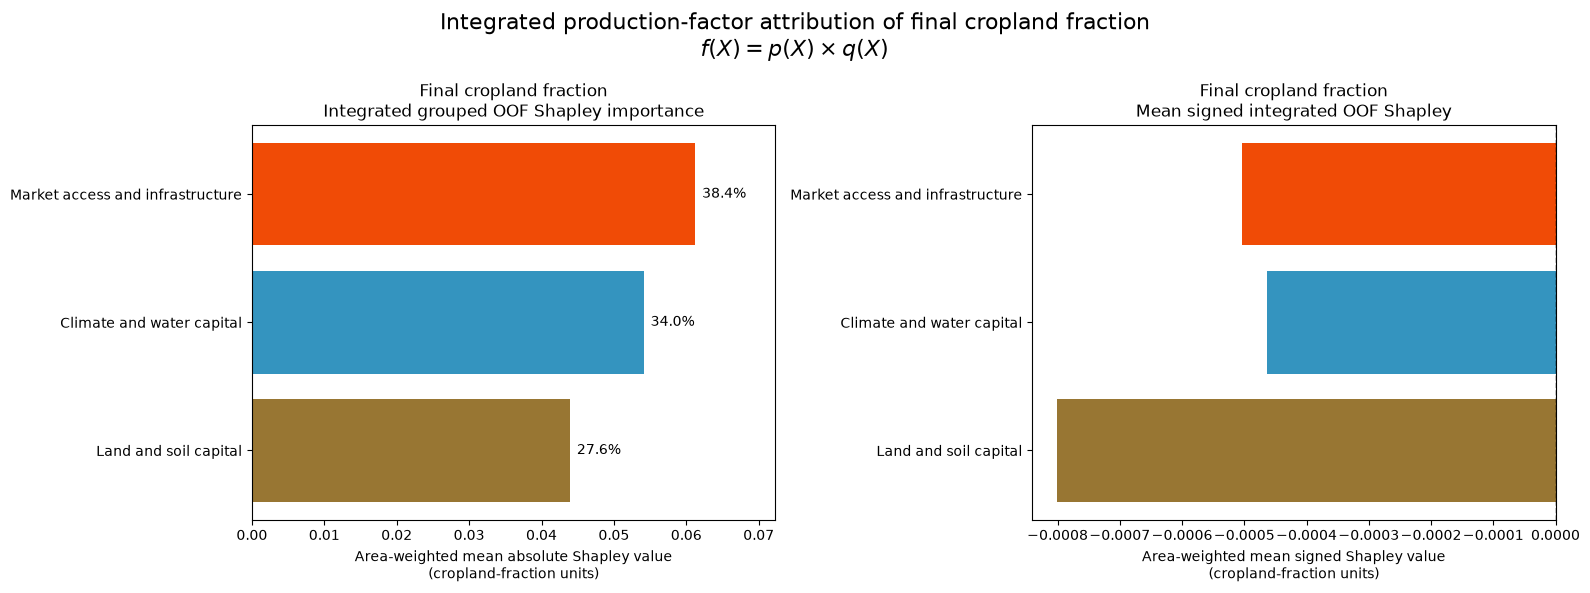


Saved:
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/integrated_final_cropland_group_shap_local.csv.gz
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/integrated_final_cropland_group_shap_by_fold.csv
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/integrated_final_cropland_group_shap_global.csv


In [13]:
# ============================================================
# 14. 最終cropland fraction p(X)q(X) の統合グループShapley
# ============================================================
#
# 必要な既存オブジェクト:
# sample, splits, SOIL_FEATURES, fit_models,
# adjust_probability_prior_shift, target_prior,
# area_weight, OUTPUT_DIR, RANDOM_SEED
#
# 3グループなので、全2^3=8組合せを評価します。
# グループの組合せについては厳密なShapley計算です。
# 背景分布についてはモンテカルロ近似です。
# ============================================================

from math import factorial
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 設定
# ------------------------------------------------------------

FINAL_SHAP_MAX_ROWS_PER_FOLD = 5_000
FINAL_SHAP_BACKGROUND_DRAWS = 8

# 最終結果をより安定させる場合の推奨値
# FINAL_SHAP_MAX_ROWS_PER_FOLD = 10_000
# FINAL_SHAP_BACKGROUND_DRAWS = 32

FINAL_MODEL_NAME = "soil_group_wetland_excluded"
FINAL_FEATURES = list(SOIL_FEATURES)

FINAL_FACTOR_GROUPS = {
    "Land and soil capital": [
        "elevation_m",
        "slope",
        "exclusion_class",
        "soil_group_class",
    ],
    "Climate and water capital": [
        "rainfed_calorie_top5_raw",
        "irrigation_calorie_gain_top5_raw",
        "wx_50km_rainfed_calorie_top5_raw",
        "log_distance_river_gt10_2020",
        "log_glofas_p10_2020",
    ],
    "Market access and infrastructure": [
        "log_city_time_20k_min",
        "log_port_time_any_min",
    ],
}

GROUP_SLUG = {
    "Land and soil capital": "land_soil",
    "Climate and water capital": "climate_water",
    "Market access and infrastructure": "market_infrastructure",
}

GROUP_COLORS = {
    "Land and soil capital": "#987633",
    "Climate and water capital": "#3494bf",
    "Market access and infrastructure": "#f04b06",
}


# ------------------------------------------------------------
# 2. グループ設定の検査
# ------------------------------------------------------------

grouped_features = [
    feature
    for group_features in FINAL_FACTOR_GROUPS.values()
    for feature in group_features
]

missing_from_groups = sorted(set(FINAL_FEATURES) - set(grouped_features))
unknown_in_groups = sorted(set(grouped_features) - set(FINAL_FEATURES))

feature_counts = pd.Series(grouped_features).value_counts()
duplicated_features = feature_counts[feature_counts > 1].index.tolist()

if missing_from_groups:
    raise ValueError(
        f"グループに入っていない説明変数があります: {missing_from_groups}"
    )

if unknown_in_groups:
    raise ValueError(
        f"モデルに存在しない説明変数がグループにあります: "
        f"{unknown_in_groups}"
    )

if duplicated_features:
    raise ValueError(
        f"複数グループに重複している変数があります: "
        f"{duplicated_features}"
    )

group_names = list(FINAL_FACTOR_GROUPS)
n_groups = len(group_names)
n_coalitions = 2 ** n_groups
full_coalition = n_coalitions - 1

print("Final model:", FINAL_MODEL_NAME)
print("Features:", len(FINAL_FEATURES))
print("Factor groups:", group_names)
print("Coalitions:", n_coalitions)


# ------------------------------------------------------------
# 3. 補助関数
# ------------------------------------------------------------

def restore_categorical_dtypes(frame):
    """LightGBM予測用にカテゴリ型とカテゴリ順序を復元する。"""
    frame = frame.copy()

    for column in categorical_features_for(FINAL_FEATURES):
        categories = sample[column].cat.categories
        ordered = sample[column].cat.ordered

        frame[column] = pd.Categorical(
            frame[column].astype(int),
            categories=categories,
            ordered=ordered,
        )

    return frame[FINAL_FEATURES]


def predict_final_cropland_fraction(
    classifier,
    regressor,
    frame,
    training_presence_prior,
):
    """
    統合関数
        f(X) = calibrated p(X) * q(X)
    を返す。
    """
    frame = restore_categorical_dtypes(frame)

    raw_probability = classifier.predict_proba(
        frame[FINAL_FEATURES]
    )[:, 1]

    calibrated_probability = adjust_probability_prior_shift(
        raw_probability,
        sample_prior=training_presence_prior,
        population_prior=target_prior,
    )

    conditional_fraction = np.clip(
        regressor.predict(frame[FINAL_FEATURES]),
        0.0,
        1.0,
    )

    final_fraction = (
        np.clip(calibrated_probability, 0.0, 1.0)
        * conditional_fraction
    )

    return np.clip(final_fraction, 0.0, 1.0)


def make_hybrid_frame(
    evaluation_frame,
    background_frame,
    coalition_mask,
):
    """
    coalition_maskに含まれるグループ:
        評価対象セルの値を使用

    coalition_maskに含まれないグループ:
        背景セルの値を使用
    """
    hybrid = (
        background_frame[FINAL_FEATURES]
        .reset_index(drop=True)
        .copy()
    )

    evaluation_values = (
        evaluation_frame[FINAL_FEATURES]
        .reset_index(drop=True)
    )

    for group_index, group_name in enumerate(group_names):
        if coalition_mask & (1 << group_index):
            for feature in FINAL_FACTOR_GROUPS[group_name]:
                hybrid[feature] = evaluation_values[feature].copy()

    return restore_categorical_dtypes(hybrid)


def weighted_background_probabilities(global_indices):
    """世界人口構成とセル面積を考慮した背景抽出確率。"""
    if area_weight is None:
        return None

    weights = np.asarray(
        area_weight[np.asarray(global_indices, dtype=int)],
        dtype=float,
    )

    valid = np.isfinite(weights) & (weights > 0)
    weights = np.where(valid, weights, 0.0)

    if weights.sum() <= 0:
        return None

    return weights / weights.sum()


def calculate_group_shapley(coalition_values):
    """
    すべてのグループ組合せの予測値から、
    各グループのShapley値を計算する。
    """
    n_rows = len(coalition_values[0])
    group_shapley = np.zeros(
        (n_rows, n_groups),
        dtype=np.float64,
    )

    denominator = factorial(n_groups)

    for group_index in range(n_groups):
        group_bit = 1 << group_index

        for coalition_mask in range(n_coalitions):
            if coalition_mask & group_bit:
                continue

            coalition_size = int(coalition_mask).bit_count()

            shapley_weight = (
                factorial(coalition_size)
                * factorial(n_groups - coalition_size - 1)
                / denominator
            )

            group_shapley[:, group_index] += shapley_weight * (
                coalition_values[coalition_mask | group_bit]
                - coalition_values[coalition_mask]
            )

    return group_shapley


# ------------------------------------------------------------
# 4. Spatial OOFで統合グループShapleyを計算
# ------------------------------------------------------------

integrated_local_rows = []
integrated_fold_rows = []

for fold_number, (train_idx, test_idx) in enumerate(
    splits,
    start=1,
):
    print("=" * 72)
    print(f"INTEGRATED FINAL SHAPLEY: fold {fold_number}/{len(splits)}")
    print("=" * 72)

    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    train_df = sample.iloc[train_idx]
    training_presence_prior = float(
        train_df["presence"].mean()
    )

    # 採用済み土壌モデルだけを再学習
    classifier, regressor = fit_models(
        train_df=train_df,
        features=FINAL_FEATURES,
        fold_number=fold_number,
    )

    # OOF検証セルから一様抽出
    selected_local_positions = select_local_positions(
        n_rows=len(test_idx),
        max_rows=FINAL_SHAP_MAX_ROWS_PER_FOLD,
        seed=RANDOM_SEED + 30_000 + fold_number,
    )

    evaluation_indices = test_idx[selected_local_positions]

    evaluation_frame = (
        sample.iloc[evaluation_indices]
        .reset_index(drop=True)
        .copy()
    )

    n_evaluation = len(evaluation_frame)

    # fold内の一様抽出率を補正
    selection_probability = (
        n_evaluation / max(len(test_idx), 1)
    )

    if area_weight is None:
        evaluation_weights = np.full(
            n_evaluation,
            1.0 / max(selection_probability, 1e-12),
            dtype=float,
        )
    else:
        evaluation_weights = np.asarray(
            area_weight[evaluation_indices],
            dtype=float,
        ) / max(selection_probability, 1e-12)

    background_probabilities = (
        weighted_background_probabilities(train_idx)
    )

    rng = np.random.default_rng(
        RANDOM_SEED + 40_000 + fold_number
    )

    coalition_sums = {
        coalition_mask: np.zeros(
            n_evaluation,
            dtype=np.float64,
        )
        for coalition_mask in range(n_coalitions)
    }

    for draw_number in range(
        1,
        FINAL_SHAP_BACKGROUND_DRAWS + 1,
    ):
        print(
            f"  background draw "
            f"{draw_number}/{FINAL_SHAP_BACKGROUND_DRAWS}"
        )

        background_local_positions = rng.choice(
            len(train_idx),
            size=n_evaluation,
            replace=True,
            p=background_probabilities,
        )

        background_indices = train_idx[
            background_local_positions
        ]

        background_frame = (
            sample.iloc[background_indices]
            .reset_index(drop=True)
            .copy()
        )

        # 3グループなので8通りをすべて評価
        for coalition_mask in range(n_coalitions):
            hybrid_frame = make_hybrid_frame(
                evaluation_frame=evaluation_frame,
                background_frame=background_frame,
                coalition_mask=coalition_mask,
            )

            coalition_sums[coalition_mask] += (
                predict_final_cropland_fraction(
                    classifier=classifier,
                    regressor=regressor,
                    frame=hybrid_frame,
                    training_presence_prior=training_presence_prior,
                )
            )

            del hybrid_frame

        del background_frame
        gc.collect()

    coalition_values = {
        coalition_mask: (
            coalition_sums[coalition_mask]
            / FINAL_SHAP_BACKGROUND_DRAWS
        )
        for coalition_mask in range(n_coalitions)
    }

    group_shapley = calculate_group_shapley(
        coalition_values
    )

    baseline_prediction = coalition_values[0]
    final_prediction = coalition_values[full_coalition]

    # Shapley効率性:
    # 全グループの寄与合計 =
    # 最終予測 - 背景基準予測
    reconstruction = (
        baseline_prediction
        + group_shapley.sum(axis=1)
    )

    maximum_efficiency_error = float(
        np.max(
            np.abs(
                reconstruction - final_prediction
            )
        )
    )

    print(
        "  maximum Shapley reconstruction error:",
        f"{maximum_efficiency_error:.3e}",
    )

    if maximum_efficiency_error > 1e-8:
        raise RuntimeError(
            "Shapley reconstruction failed: "
            f"{maximum_efficiency_error}"
        )

    # 既存の最終OOF予測との一致を確認
    if (
        "prediction_by_model" in globals()
        and FINAL_MODEL_NAME in prediction_by_model
    ):
        existing_oof_prediction = np.asarray(
            prediction_by_model[FINAL_MODEL_NAME][
                evaluation_indices
            ],
            dtype=float,
        )

        maximum_prediction_difference = float(
            np.max(
                np.abs(
                    existing_oof_prediction
                    - final_prediction
                )
            )
        )

        print(
            "  maximum difference from existing OOF prediction:",
            f"{maximum_prediction_difference:.3e}",
        )

    local_result = evaluation_frame[
        [
            "row",
            "col",
            "lat",
            "lon",
            "spatial_block",
            "presence",
            "cropland_fraction",
        ]
    ].copy()

    local_result.insert(0, "fold", fold_number)
    local_result["weight"] = evaluation_weights
    local_result["baseline_final_fraction"] = (
        baseline_prediction
    )
    local_result["predicted_final_fraction"] = (
        final_prediction
    )

    for group_index, group_name in enumerate(group_names):
        slug = GROUP_SLUG[group_name]
        local_result[f"shap__{slug}"] = (
            group_shapley[:, group_index]
        )

    integrated_local_rows.append(local_result)

    # fold単位の重要度
    valid_weight = (
        np.isfinite(evaluation_weights)
        & (evaluation_weights > 0)
    )

    fold_weights = evaluation_weights[valid_weight]

    for group_index, group_name in enumerate(group_names):
        values = group_shapley[
            valid_weight,
            group_index,
        ]

        integrated_fold_rows.append({
            "fold": fold_number,
            "group": group_name,
            "n": int(len(values)),
            "sum_weight": float(fold_weights.sum()),
            "mean_abs_final_shap": float(
                np.average(
                    np.abs(values),
                    weights=fold_weights,
                )
            ),
            "mean_signed_final_shap": float(
                np.average(
                    values,
                    weights=fold_weights,
                )
            ),
        })

    del classifier, regressor
    del coalition_sums, coalition_values
    del group_shapley
    gc.collect()


# ------------------------------------------------------------
# 5. 世界全体の面積加重重要度
# ------------------------------------------------------------

integrated_local_shap = pd.concat(
    integrated_local_rows,
    ignore_index=True,
)

integrated_fold_summary = pd.DataFrame(
    integrated_fold_rows
)

global_weights = integrated_local_shap[
    "weight"
].to_numpy(dtype=float)

valid_global_weight = (
    np.isfinite(global_weights)
    & (global_weights > 0)
)

global_summary_rows = []

for group_name in group_names:
    slug = GROUP_SLUG[group_name]

    values = integrated_local_shap.loc[
        valid_global_weight,
        f"shap__{slug}",
    ].to_numpy(dtype=float)

    weights = global_weights[valid_global_weight]

    global_summary_rows.append({
        "group": group_name,
        "mean_abs_final_shap": float(
            np.average(
                np.abs(values),
                weights=weights,
            )
        ),
        "mean_signed_final_shap": float(
            np.average(
                values,
                weights=weights,
            )
        ),
    })

integrated_global_summary = pd.DataFrame(
    global_summary_rows
)

total_importance = integrated_global_summary[
    "mean_abs_final_shap"
].sum()

integrated_global_summary["importance_share_pct"] = (
    100.0
    * integrated_global_summary["mean_abs_final_shap"]
    / total_importance
)

integrated_global_summary = (
    integrated_global_summary
    .sort_values(
        "mean_abs_final_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

# foldごとの構成比
integrated_fold_summary[
    "fold_total_importance"
] = integrated_fold_summary.groupby(
    "fold"
)["mean_abs_final_shap"].transform("sum")

integrated_fold_summary[
    "importance_share_pct"
] = (
    100.0
    * integrated_fold_summary["mean_abs_final_shap"]
    / integrated_fold_summary["fold_total_importance"]
)


# ------------------------------------------------------------
# 6. 保存
# ------------------------------------------------------------

integrated_local_path = (
    OUTPUT_DIR
    / "integrated_final_cropland_group_shap_local.csv.gz"
)

integrated_fold_path = (
    OUTPUT_DIR
    / "integrated_final_cropland_group_shap_by_fold.csv"
)

integrated_global_path = (
    OUTPUT_DIR
    / "integrated_final_cropland_group_shap_global.csv"
)

integrated_local_shap.to_csv(
    integrated_local_path,
    index=False,
    compression="gzip",
)

integrated_fold_summary.to_csv(
    integrated_fold_path,
    index=False,
    encoding="utf-8-sig",
)

integrated_global_summary.to_csv(
    integrated_global_path,
    index=False,
    encoding="utf-8-sig",
)

print("\nGLOBAL INTEGRATED FINAL-CROPLAND SHAPLEY")
display(integrated_global_summary.round(6))

print("\nFOLD STABILITY: IMPORTANCE SHARE (%)")
display(
    integrated_fold_summary.pivot(
        index="fold",
        columns="group",
        values="importance_share_pct",
    ).round(2)
)


# ------------------------------------------------------------
# 7. 可視化
# ------------------------------------------------------------

plot_table = (
    integrated_global_summary
    .sort_values(
        "mean_abs_final_shap",
        ascending=True,
    )
    .reset_index(drop=True)
)

plot_colors = [
    GROUP_COLORS[group]
    for group in plot_table["group"]
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

# 左: 最終cropland fractionへの重要度
bars = axes[0].barh(
    plot_table["group"],
    plot_table["mean_abs_final_shap"],
    color=plot_colors,
)

axes[0].set_title(
    "Final cropland fraction\n"
    "Integrated grouped OOF Shapley importance"
)

axes[0].set_xlabel(
    "Area-weighted mean absolute Shapley value\n"
    "(cropland-fraction units)"
)

max_importance = max(
    plot_table["mean_abs_final_shap"].max(),
    1e-12,
)

for bar, share in zip(
    bars,
    plot_table["importance_share_pct"],
):
    axes[0].text(
        bar.get_width() + max_importance * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%",
        va="center",
    )

axes[0].set_xlim(
    0,
    max_importance * 1.18,
)

# 右: 平均的な方向
axes[1].barh(
    plot_table["group"],
    plot_table["mean_signed_final_shap"],
    color=plot_colors,
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Final cropland fraction\n"
    "Mean signed integrated OOF Shapley"
)

axes[1].set_xlabel(
    "Area-weighted mean signed Shapley value\n"
    "(cropland-fraction units)"
)

fig.suptitle(
    "Integrated production-factor attribution of final cropland fraction\n"
    r"$f(X)=p(X)\times q(X)$",
    fontsize=16,
)

plt.tight_layout()
plt.show()

print("\nSaved:")
print(integrated_local_path)
print(integrated_fold_path)
print(integrated_global_path)

## 15 32背景セルにしてみるか

Final model: soil_group_wetland_excluded
Features: 11
Factor groups: ['Land and soil capital', 'Climate and water capital', 'Market access and infrastructure']
Coalitions: 8
INTEGRATED FINAL SHAPLEY: fold 1/5
  background draw 1/32
  background draw 2/32
  background draw 3/32
  background draw 4/32
  background draw 5/32
  background draw 6/32
  background draw 7/32
  background draw 8/32
  background draw 9/32
  background draw 10/32
  background draw 11/32
  background draw 12/32
  background draw 13/32
  background draw 14/32
  background draw 15/32
  background draw 16/32
  background draw 17/32
  background draw 18/32
  background draw 19/32
  background draw 20/32
  background draw 21/32
  background draw 22/32
  background draw 23/32
  background draw 24/32
  background draw 25/32
  background draw 26/32
  background draw 27/32
  background draw 28/32
  background draw 29/32
  background draw 30/32
  background draw 31/32
  background draw 32/32
  maximum Shapley reconstruction

,group,mean_abs_final_shap,mean_signed_final_shap,importance_share_pct
0,Market access and infrastructure,0.059536,-0.000581,38.795453
1,Climate and water capital,0.052822,-0.000467,34.420665
2,Land and soil capital,0.041103,-0.000812,26.783882



FOLD STABILITY: IMPORTANCE SHARE (%)


group,Climate and water capital,Land and soil capital,Market access and infrastructure
fold,,,
1,35.75,26.23,38.03
2,34.80,26.95,38.25
3,35.53,25.85,38.63
4,34.58,26.02,39.40
5,31.54,28.85,39.61


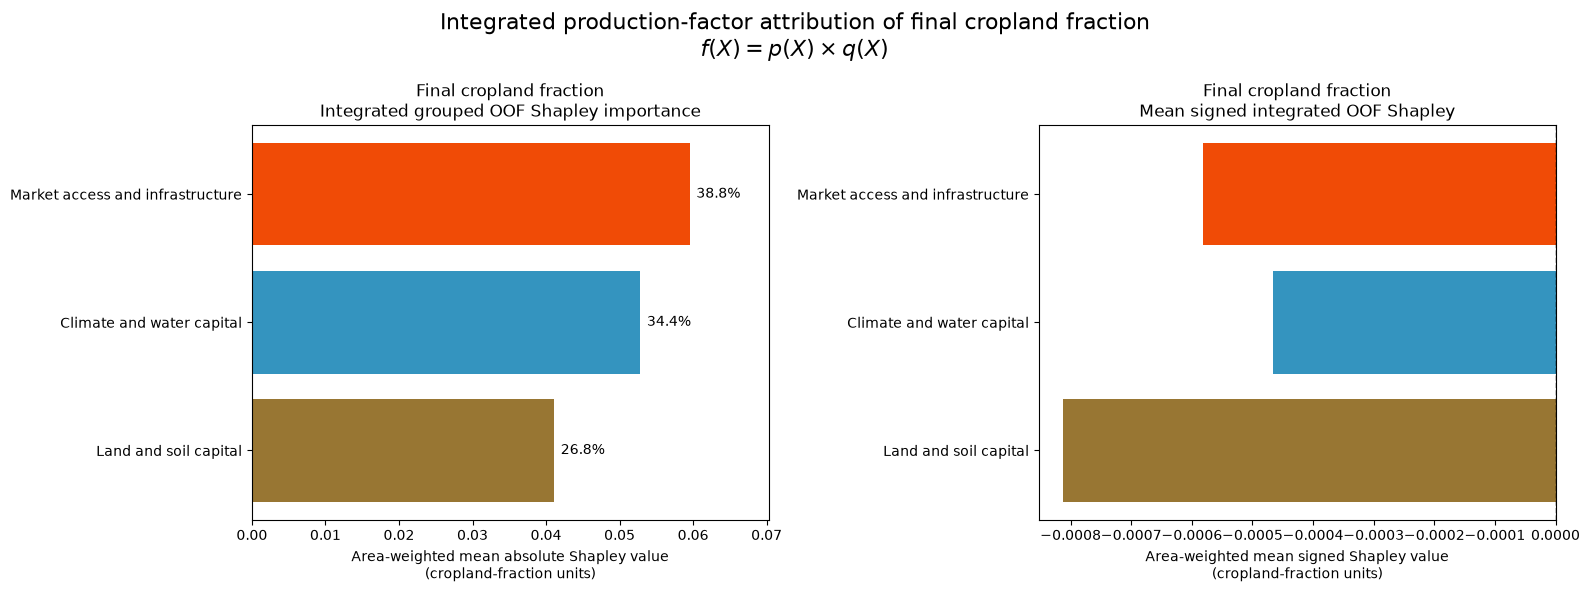


Saved:
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/integrated_final_cropland_group_shap_local.csv.gz
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/integrated_final_cropland_group_shap_by_fold.csv
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/integrated_final_cropland_group_shap_global.csv


In [14]:
# ============================================================
# 14. 最終cropland fraction p(X)q(X) の統合グループShapley
# ============================================================
#
# 必要な既存オブジェクト:
# sample, splits, SOIL_FEATURES, fit_models,
# adjust_probability_prior_shift, target_prior,
# area_weight, OUTPUT_DIR, RANDOM_SEED
#
# 3グループなので、全2^3=8組合せを評価します。
# グループの組合せについては厳密なShapley計算です。
# 背景分布についてはモンテカルロ近似です。
# ============================================================

from math import factorial
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 設定
# ------------------------------------------------------------

FINAL_SHAP_MAX_ROWS_PER_FOLD = 5_000
FINAL_SHAP_BACKGROUND_DRAWS = 32

# 最終結果をより安定させる場合の推奨値
# FINAL_SHAP_MAX_ROWS_PER_FOLD = 10_000
# FINAL_SHAP_BACKGROUND_DRAWS = 32

FINAL_MODEL_NAME = "soil_group_wetland_excluded"
FINAL_FEATURES = list(SOIL_FEATURES)

FINAL_FACTOR_GROUPS = {
    "Land and soil capital": [
        "elevation_m",
        "slope",
        "exclusion_class",
        "soil_group_class",
    ],
    "Climate and water capital": [
        "rainfed_calorie_top5_raw",
        "irrigation_calorie_gain_top5_raw",
        "wx_50km_rainfed_calorie_top5_raw",
        "log_distance_river_gt10_2020",
        "log_glofas_p10_2020",
    ],
    "Market access and infrastructure": [
        "log_city_time_20k_min",
        "log_port_time_any_min",
    ],
}

GROUP_SLUG = {
    "Land and soil capital": "land_soil",
    "Climate and water capital": "climate_water",
    "Market access and infrastructure": "market_infrastructure",
}

GROUP_COLORS = {
    "Land and soil capital": "#987633",
    "Climate and water capital": "#3494bf",
    "Market access and infrastructure": "#f04b06",
}


# ------------------------------------------------------------
# 2. グループ設定の検査
# ------------------------------------------------------------

grouped_features = [
    feature
    for group_features in FINAL_FACTOR_GROUPS.values()
    for feature in group_features
]

missing_from_groups = sorted(set(FINAL_FEATURES) - set(grouped_features))
unknown_in_groups = sorted(set(grouped_features) - set(FINAL_FEATURES))

feature_counts = pd.Series(grouped_features).value_counts()
duplicated_features = feature_counts[feature_counts > 1].index.tolist()

if missing_from_groups:
    raise ValueError(
        f"グループに入っていない説明変数があります: {missing_from_groups}"
    )

if unknown_in_groups:
    raise ValueError(
        f"モデルに存在しない説明変数がグループにあります: "
        f"{unknown_in_groups}"
    )

if duplicated_features:
    raise ValueError(
        f"複数グループに重複している変数があります: "
        f"{duplicated_features}"
    )

group_names = list(FINAL_FACTOR_GROUPS)
n_groups = len(group_names)
n_coalitions = 2 ** n_groups
full_coalition = n_coalitions - 1

print("Final model:", FINAL_MODEL_NAME)
print("Features:", len(FINAL_FEATURES))
print("Factor groups:", group_names)
print("Coalitions:", n_coalitions)


# ------------------------------------------------------------
# 3. 補助関数
# ------------------------------------------------------------

def restore_categorical_dtypes(frame):
    """LightGBM予測用にカテゴリ型とカテゴリ順序を復元する。"""
    frame = frame.copy()

    for column in categorical_features_for(FINAL_FEATURES):
        categories = sample[column].cat.categories
        ordered = sample[column].cat.ordered

        frame[column] = pd.Categorical(
            frame[column].astype(int),
            categories=categories,
            ordered=ordered,
        )

    return frame[FINAL_FEATURES]


def predict_final_cropland_fraction(
    classifier,
    regressor,
    frame,
    training_presence_prior,
):
    """
    統合関数
        f(X) = calibrated p(X) * q(X)
    を返す。
    """
    frame = restore_categorical_dtypes(frame)

    raw_probability = classifier.predict_proba(
        frame[FINAL_FEATURES]
    )[:, 1]

    calibrated_probability = adjust_probability_prior_shift(
        raw_probability,
        sample_prior=training_presence_prior,
        population_prior=target_prior,
    )

    conditional_fraction = np.clip(
        regressor.predict(frame[FINAL_FEATURES]),
        0.0,
        1.0,
    )

    final_fraction = (
        np.clip(calibrated_probability, 0.0, 1.0)
        * conditional_fraction
    )

    return np.clip(final_fraction, 0.0, 1.0)


def make_hybrid_frame(
    evaluation_frame,
    background_frame,
    coalition_mask,
):
    """
    coalition_maskに含まれるグループ:
        評価対象セルの値を使用

    coalition_maskに含まれないグループ:
        背景セルの値を使用
    """
    hybrid = (
        background_frame[FINAL_FEATURES]
        .reset_index(drop=True)
        .copy()
    )

    evaluation_values = (
        evaluation_frame[FINAL_FEATURES]
        .reset_index(drop=True)
    )

    for group_index, group_name in enumerate(group_names):
        if coalition_mask & (1 << group_index):
            for feature in FINAL_FACTOR_GROUPS[group_name]:
                hybrid[feature] = evaluation_values[feature].copy()

    return restore_categorical_dtypes(hybrid)


def weighted_background_probabilities(global_indices):
    """世界人口構成とセル面積を考慮した背景抽出確率。"""
    if area_weight is None:
        return None

    weights = np.asarray(
        area_weight[np.asarray(global_indices, dtype=int)],
        dtype=float,
    )

    valid = np.isfinite(weights) & (weights > 0)
    weights = np.where(valid, weights, 0.0)

    if weights.sum() <= 0:
        return None

    return weights / weights.sum()


def calculate_group_shapley(coalition_values):
    """
    すべてのグループ組合せの予測値から、
    各グループのShapley値を計算する。
    """
    n_rows = len(coalition_values[0])
    group_shapley = np.zeros(
        (n_rows, n_groups),
        dtype=np.float64,
    )

    denominator = factorial(n_groups)

    for group_index in range(n_groups):
        group_bit = 1 << group_index

        for coalition_mask in range(n_coalitions):
            if coalition_mask & group_bit:
                continue

            coalition_size = int(coalition_mask).bit_count()

            shapley_weight = (
                factorial(coalition_size)
                * factorial(n_groups - coalition_size - 1)
                / denominator
            )

            group_shapley[:, group_index] += shapley_weight * (
                coalition_values[coalition_mask | group_bit]
                - coalition_values[coalition_mask]
            )

    return group_shapley


# ------------------------------------------------------------
# 4. Spatial OOFで統合グループShapleyを計算
# ------------------------------------------------------------

integrated_local_rows = []
integrated_fold_rows = []

for fold_number, (train_idx, test_idx) in enumerate(
    splits,
    start=1,
):
    print("=" * 72)
    print(f"INTEGRATED FINAL SHAPLEY: fold {fold_number}/{len(splits)}")
    print("=" * 72)

    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    train_df = sample.iloc[train_idx]
    training_presence_prior = float(
        train_df["presence"].mean()
    )

    # 採用済み土壌モデルだけを再学習
    classifier, regressor = fit_models(
        train_df=train_df,
        features=FINAL_FEATURES,
        fold_number=fold_number,
    )

    # OOF検証セルから一様抽出
    selected_local_positions = select_local_positions(
        n_rows=len(test_idx),
        max_rows=FINAL_SHAP_MAX_ROWS_PER_FOLD,
        seed=RANDOM_SEED + 30_000 + fold_number,
    )

    evaluation_indices = test_idx[selected_local_positions]

    evaluation_frame = (
        sample.iloc[evaluation_indices]
        .reset_index(drop=True)
        .copy()
    )

    n_evaluation = len(evaluation_frame)

    # fold内の一様抽出率を補正
    selection_probability = (
        n_evaluation / max(len(test_idx), 1)
    )

    if area_weight is None:
        evaluation_weights = np.full(
            n_evaluation,
            1.0 / max(selection_probability, 1e-12),
            dtype=float,
        )
    else:
        evaluation_weights = np.asarray(
            area_weight[evaluation_indices],
            dtype=float,
        ) / max(selection_probability, 1e-12)

    background_probabilities = (
        weighted_background_probabilities(train_idx)
    )

    rng = np.random.default_rng(
        RANDOM_SEED + 40_000 + fold_number
    )

    coalition_sums = {
        coalition_mask: np.zeros(
            n_evaluation,
            dtype=np.float64,
        )
        for coalition_mask in range(n_coalitions)
    }

    for draw_number in range(
        1,
        FINAL_SHAP_BACKGROUND_DRAWS + 1,
    ):
        print(
            f"  background draw "
            f"{draw_number}/{FINAL_SHAP_BACKGROUND_DRAWS}"
        )

        background_local_positions = rng.choice(
            len(train_idx),
            size=n_evaluation,
            replace=True,
            p=background_probabilities,
        )

        background_indices = train_idx[
            background_local_positions
        ]

        background_frame = (
            sample.iloc[background_indices]
            .reset_index(drop=True)
            .copy()
        )

        # 3グループなので8通りをすべて評価
        for coalition_mask in range(n_coalitions):
            hybrid_frame = make_hybrid_frame(
                evaluation_frame=evaluation_frame,
                background_frame=background_frame,
                coalition_mask=coalition_mask,
            )

            coalition_sums[coalition_mask] += (
                predict_final_cropland_fraction(
                    classifier=classifier,
                    regressor=regressor,
                    frame=hybrid_frame,
                    training_presence_prior=training_presence_prior,
                )
            )

            del hybrid_frame

        del background_frame
        gc.collect()

    coalition_values = {
        coalition_mask: (
            coalition_sums[coalition_mask]
            / FINAL_SHAP_BACKGROUND_DRAWS
        )
        for coalition_mask in range(n_coalitions)
    }

    group_shapley = calculate_group_shapley(
        coalition_values
    )

    baseline_prediction = coalition_values[0]
    final_prediction = coalition_values[full_coalition]

    # Shapley効率性:
    # 全グループの寄与合計 =
    # 最終予測 - 背景基準予測
    reconstruction = (
        baseline_prediction
        + group_shapley.sum(axis=1)
    )

    maximum_efficiency_error = float(
        np.max(
            np.abs(
                reconstruction - final_prediction
            )
        )
    )

    print(
        "  maximum Shapley reconstruction error:",
        f"{maximum_efficiency_error:.3e}",
    )

    if maximum_efficiency_error > 1e-8:
        raise RuntimeError(
            "Shapley reconstruction failed: "
            f"{maximum_efficiency_error}"
        )

    # 既存の最終OOF予測との一致を確認
    if (
        "prediction_by_model" in globals()
        and FINAL_MODEL_NAME in prediction_by_model
    ):
        existing_oof_prediction = np.asarray(
            prediction_by_model[FINAL_MODEL_NAME][
                evaluation_indices
            ],
            dtype=float,
        )

        maximum_prediction_difference = float(
            np.max(
                np.abs(
                    existing_oof_prediction
                    - final_prediction
                )
            )
        )

        print(
            "  maximum difference from existing OOF prediction:",
            f"{maximum_prediction_difference:.3e}",
        )

    local_result = evaluation_frame[
        [
            "row",
            "col",
            "lat",
            "lon",
            "spatial_block",
            "presence",
            "cropland_fraction",
        ]
    ].copy()

    local_result.insert(0, "fold", fold_number)
    local_result["weight"] = evaluation_weights
    local_result["baseline_final_fraction"] = (
        baseline_prediction
    )
    local_result["predicted_final_fraction"] = (
        final_prediction
    )

    for group_index, group_name in enumerate(group_names):
        slug = GROUP_SLUG[group_name]
        local_result[f"shap__{slug}"] = (
            group_shapley[:, group_index]
        )

    integrated_local_rows.append(local_result)

    # fold単位の重要度
    valid_weight = (
        np.isfinite(evaluation_weights)
        & (evaluation_weights > 0)
    )

    fold_weights = evaluation_weights[valid_weight]

    for group_index, group_name in enumerate(group_names):
        values = group_shapley[
            valid_weight,
            group_index,
        ]

        integrated_fold_rows.append({
            "fold": fold_number,
            "group": group_name,
            "n": int(len(values)),
            "sum_weight": float(fold_weights.sum()),
            "mean_abs_final_shap": float(
                np.average(
                    np.abs(values),
                    weights=fold_weights,
                )
            ),
            "mean_signed_final_shap": float(
                np.average(
                    values,
                    weights=fold_weights,
                )
            ),
        })

    del classifier, regressor
    del coalition_sums, coalition_values
    del group_shapley
    gc.collect()


# ------------------------------------------------------------
# 5. 世界全体の面積加重重要度
# ------------------------------------------------------------

integrated_local_shap = pd.concat(
    integrated_local_rows,
    ignore_index=True,
)

integrated_fold_summary = pd.DataFrame(
    integrated_fold_rows
)

global_weights = integrated_local_shap[
    "weight"
].to_numpy(dtype=float)

valid_global_weight = (
    np.isfinite(global_weights)
    & (global_weights > 0)
)

global_summary_rows = []

for group_name in group_names:
    slug = GROUP_SLUG[group_name]

    values = integrated_local_shap.loc[
        valid_global_weight,
        f"shap__{slug}",
    ].to_numpy(dtype=float)

    weights = global_weights[valid_global_weight]

    global_summary_rows.append({
        "group": group_name,
        "mean_abs_final_shap": float(
            np.average(
                np.abs(values),
                weights=weights,
            )
        ),
        "mean_signed_final_shap": float(
            np.average(
                values,
                weights=weights,
            )
        ),
    })

integrated_global_summary = pd.DataFrame(
    global_summary_rows
)

total_importance = integrated_global_summary[
    "mean_abs_final_shap"
].sum()

integrated_global_summary["importance_share_pct"] = (
    100.0
    * integrated_global_summary["mean_abs_final_shap"]
    / total_importance
)

integrated_global_summary = (
    integrated_global_summary
    .sort_values(
        "mean_abs_final_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

# foldごとの構成比
integrated_fold_summary[
    "fold_total_importance"
] = integrated_fold_summary.groupby(
    "fold"
)["mean_abs_final_shap"].transform("sum")

integrated_fold_summary[
    "importance_share_pct"
] = (
    100.0
    * integrated_fold_summary["mean_abs_final_shap"]
    / integrated_fold_summary["fold_total_importance"]
)


# ------------------------------------------------------------
# 6. 保存
# ------------------------------------------------------------

integrated_local_path = (
    OUTPUT_DIR
    / "integrated_final_cropland_group_shap_local.csv.gz"
)

integrated_fold_path = (
    OUTPUT_DIR
    / "integrated_final_cropland_group_shap_by_fold.csv"
)

integrated_global_path = (
    OUTPUT_DIR
    / "integrated_final_cropland_group_shap_global.csv"
)

integrated_local_shap.to_csv(
    integrated_local_path,
    index=False,
    compression="gzip",
)

integrated_fold_summary.to_csv(
    integrated_fold_path,
    index=False,
    encoding="utf-8-sig",
)

integrated_global_summary.to_csv(
    integrated_global_path,
    index=False,
    encoding="utf-8-sig",
)

print("\nGLOBAL INTEGRATED FINAL-CROPLAND SHAPLEY")
display(integrated_global_summary.round(6))

print("\nFOLD STABILITY: IMPORTANCE SHARE (%)")
display(
    integrated_fold_summary.pivot(
        index="fold",
        columns="group",
        values="importance_share_pct",
    ).round(2)
)


# ------------------------------------------------------------
# 7. 可視化
# ------------------------------------------------------------

plot_table = (
    integrated_global_summary
    .sort_values(
        "mean_abs_final_shap",
        ascending=True,
    )
    .reset_index(drop=True)
)

plot_colors = [
    GROUP_COLORS[group]
    for group in plot_table["group"]
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

# 左: 最終cropland fractionへの重要度
bars = axes[0].barh(
    plot_table["group"],
    plot_table["mean_abs_final_shap"],
    color=plot_colors,
)

axes[0].set_title(
    "Final cropland fraction\n"
    "Integrated grouped OOF Shapley importance"
)

axes[0].set_xlabel(
    "Area-weighted mean absolute Shapley value\n"
    "(cropland-fraction units)"
)

max_importance = max(
    plot_table["mean_abs_final_shap"].max(),
    1e-12,
)

for bar, share in zip(
    bars,
    plot_table["importance_share_pct"],
):
    axes[0].text(
        bar.get_width() + max_importance * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%",
        va="center",
    )

axes[0].set_xlim(
    0,
    max_importance * 1.18,
)

# 右: 平均的な方向
axes[1].barh(
    plot_table["group"],
    plot_table["mean_signed_final_shap"],
    color=plot_colors,
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Final cropland fraction\n"
    "Mean signed integrated OOF Shapley"
)

axes[1].set_xlabel(
    "Area-weighted mean signed Shapley value\n"
    "(cropland-fraction units)"
)

fig.suptitle(
    "Integrated production-factor attribution of final cropland fraction\n"
    r"$f(X)=p(X)\times q(X)$",
    fontsize=16,
)

plt.tight_layout()
plt.show()

print("\nSaved:")
print(integrated_local_path)
print(integrated_fold_path)
print(integrated_global_path)

## 16 地図上に最大寄与要素を可視化

Data source: local_group_shap
Number of cells: 100000
Longitude: lon
Latitude: lat

Integrated group Shapley columns:
  Market access and infrastructure: group_shap__Market access and infrastructure
  Climate and water capital: group_shap__Climate and water capital
  Land and soil capital: group_shap__Land and soil capital

Dominant production factor:
                 dominant_factor     n share_percent
Market access and infrastructure 43235         43.2%
           Land and soil capital 26056         26.1%
       Climate and water capital 17928         17.9%
                 Mixed / unclear 12781         12.8%

Mean dominance share: 0.599
Median dominance share: 0.587


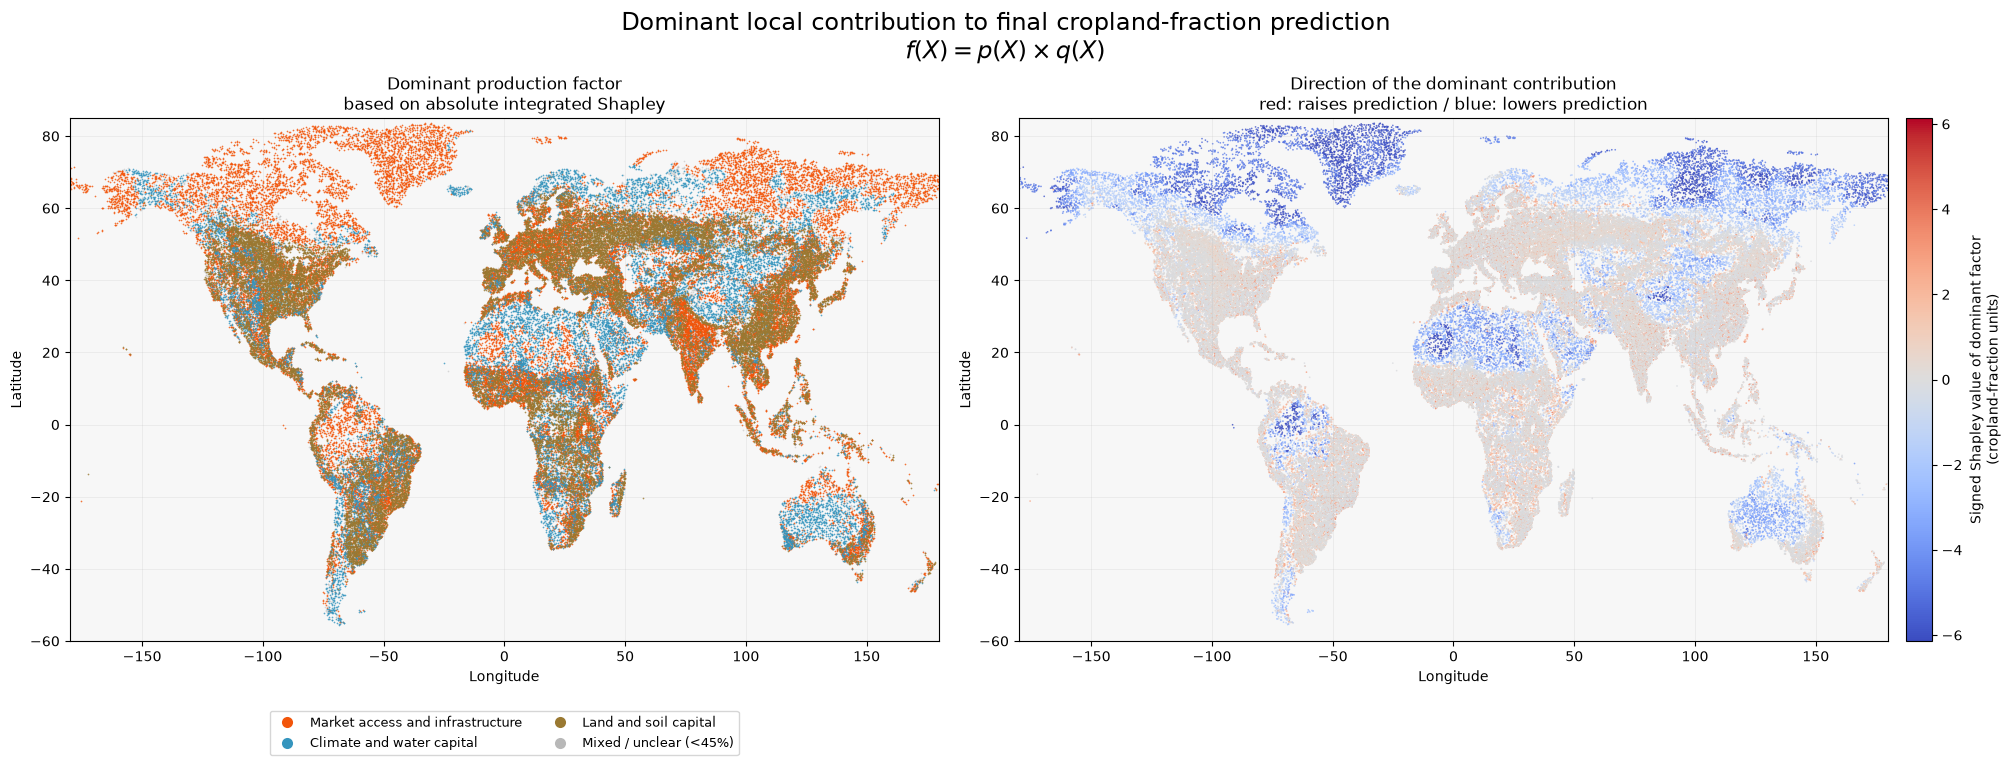

,lon,lat,dominant_factor,dominance_share,dominant_signed_shap,dominant_absolute_shap
0,141.541534,-22.375027,Climate and water capital,0.852707,-3.465470,3.465470
1,27.958250,-30.958357,Market access and infrastructure,0.569257,1.649969,1.649969
2,148.041534,-25.125027,Mixed / unclear,0.422582,-1.026456,1.026456
3,116.874878,52.624943,Market access and infrastructure,0.674094,2.002023,2.002023
4,136.041534,63.541607,Climate and water capital,0.646428,-2.142390,2.142390


In [15]:
# ============================================================
# 世界各セルで最も予測に影響した生産要素を可視化
#
# 対象：
#   最終cropland fraction予測
#       f(X) = p(X) * q(X)
#   に対して計算した統合グループShapley
#
# 注意：
#   再学習・SHAP再計算は行いません。
#   直前までに作成したlocal integrated Shapley表を利用します。
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ------------------------------------------------------------
# 1. 設定
# ------------------------------------------------------------

# 最大要素の |SHAP| / 全要素の |SHAP| 合計がこの値未満なら
# 無理に単一要素へ分類せず、Mixed / unclear とします。
MIN_DOMINANCE_SHARE = 0.45

# 点の最大表示数
# Noneなら全セルを表示します。
MAX_PLOT_POINTS = None

# 図を保存したい場合だけTrue
SAVE_FIGURE = False
FIGURE_PATH = (
    r"/work/tsuda/GAEZ"
    r"/final_cropland_dominant_factor_map.png"
)

# local Shapley CSVを直接読み込む場合はパスを指定してください。
# 直前のセルでDataFrameが作られている場合はNoneで構いません。
LOCAL_SHAP_CSV = None


# ------------------------------------------------------------
# 2. 列名候補
# ------------------------------------------------------------

FACTOR_SPECS = {
    "Market access and infrastructure": {
        "candidates": [
            "shap__market_infrastructure",
            "group_shap__market_infrastructure",
            "integrated_shap__market_infrastructure",
            "shapley__market_infrastructure",
            "shap__market_access_and_infrastructure",
            "group_shap__market_access_and_infrastructure",
        ],
        "tokens": [
            ("market", "infra"),
            ("market", "access"),
        ],
        "color": "#F2550A",
    },

    "Climate and water capital": {
        "candidates": [
            "shap__climate_water",
            "group_shap__climate_water",
            "integrated_shap__climate_water",
            "shapley__climate_water",
            "shap__climate_and_water_capital",
            "group_shap__climate_and_water_capital",
        ],
        "tokens": [
            ("climate", "water"),
        ],
        "color": "#3595BE",
    },

    "Land and soil capital": {
        "candidates": [
            "shap__land_soil",
            "group_shap__land_soil",
            "integrated_shap__land_soil",
            "shapley__land_soil",
            "shap__land_and_soil_capital",
            "group_shap__land_and_soil_capital",
        ],
        "tokens": [
            ("land", "soil"),
        ],
        "color": "#9A7932",
    },
}

MIXED_LABEL = "Mixed / unclear"
MIXED_COLOR = "#B8B8B8"


# ------------------------------------------------------------
# 3. 補助関数
# ------------------------------------------------------------

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


def find_coordinate_columns(df):
    lon_candidates = [
        "longitude", "lon", "long", "x_coord", "grid_lon"
    ]
    lat_candidates = [
        "latitude", "lat", "y_coord", "grid_lat"
    ]

    normalized = {
        normalize_name(col): col
        for col in df.columns
    }

    lon_col = next(
        (
            normalized[name]
            for name in lon_candidates
            if name in normalized
        ),
        None,
    )

    lat_col = next(
        (
            normalized[name]
            for name in lat_candidates
            if name in normalized
        ),
        None,
    )

    return lon_col, lat_col


def find_factor_columns(df):
    """
    最終統合Shapley表から3つの生産要素列を探します。
    """
    normalized_to_original = {
        normalize_name(col): col
        for col in df.columns
    }

    resolved = {}

    for factor_name, spec in FACTOR_SPECS.items():
        found = None

        # まず完全一致候補を探す
        for candidate in spec["candidates"]:
            normalized_candidate = normalize_name(candidate)

            if normalized_candidate in normalized_to_original:
                found = normalized_to_original[normalized_candidate]
                break

        # 完全一致がなければ単語による検索
        if found is None:
            for normalized_col, original_col in normalized_to_original.items():

                # SHAPまたはShapley列に限定
                if (
                    "shap" not in normalized_col
                    and "phi" not in normalized_col
                    and "owen" not in normalized_col
                ):
                    continue

                for required_tokens in spec["tokens"]:
                    if all(
                        token in normalized_col
                        for token in required_tokens
                    ):
                        found = original_col
                        break

                if found is not None:
                    break

        if found is not None:
            resolved[factor_name] = found

    return resolved


def locate_local_shap_dataframe():
    """
    ノートブック上のDataFrameから、
    緯度・経度と3グループの統合Shapleyを持つ表を探します。
    """
    candidates = []

    for variable_name, obj in list(globals().items()):
        if not isinstance(obj, pd.DataFrame):
            continue

        lon_col, lat_col = find_coordinate_columns(obj)
        factor_cols = find_factor_columns(obj)

        if (
            lon_col is not None
            and lat_col is not None
            and len(factor_cols) == len(FACTOR_SPECS)
        ):
            candidates.append(
                {
                    "name": variable_name,
                    "df": obj,
                    "lon_col": lon_col,
                    "lat_col": lat_col,
                    "factor_cols": factor_cols,
                    "n": len(obj),
                }
            )

    if not candidates:
        raise RuntimeError(
            "緯度・経度と3グループの統合Shapley値を持つ"
            "DataFrameが見つかりません。\n"
            "最終 p(X)×q(X) の統合Shapley計算セルを"
            "先に実行するか、LOCAL_SHAP_CSVを指定してください。"
        )

    # 通常、行数が最大の表がlocal Shapley表
    candidates.sort(key=lambda x: x["n"], reverse=True)
    return candidates[0]


# ------------------------------------------------------------
# 4. local integrated Shapley表を取得
# ------------------------------------------------------------

if LOCAL_SHAP_CSV is not None:
    local_df = pd.read_csv(LOCAL_SHAP_CSV)

    lon_col, lat_col = find_coordinate_columns(local_df)
    factor_columns = find_factor_columns(local_df)

    if lon_col is None or lat_col is None:
        raise KeyError(
            "CSV内にlongitude/latitude列が見つかりません。"
        )

    if len(factor_columns) != len(FACTOR_SPECS):
        raise KeyError(
            "CSV内に3グループの統合Shapley列が"
            "すべて見つかりません。\n"
            f"見つかった列: {factor_columns}"
        )

    source_name = LOCAL_SHAP_CSV

else:
    located = locate_local_shap_dataframe()

    source_name = located["name"]
    local_df = located["df"].copy()
    lon_col = located["lon_col"]
    lat_col = located["lat_col"]
    factor_columns = located["factor_cols"]


print("Data source:", source_name)
print("Number of cells:", len(local_df))
print("Longitude:", lon_col)
print("Latitude:", lat_col)

print("\nIntegrated group Shapley columns:")
for factor_name, col in factor_columns.items():
    print(f"  {factor_name}: {col}")


# ------------------------------------------------------------
# 5. 各セルの支配的な生産要素を計算
# ------------------------------------------------------------

factor_names = list(FACTOR_SPECS.keys())
shap_columns = [
    factor_columns[factor_name]
    for factor_name in factor_names
]

plot_df = local_df[
    [lon_col, lat_col] + shap_columns
].copy()

for col in [lon_col, lat_col] + shap_columns:
    plot_df[col] = pd.to_numeric(
        plot_df[col],
        errors="coerce",
    )

plot_df = plot_df.dropna(
    subset=[lon_col, lat_col] + shap_columns
).copy()

shap_matrix = plot_df[shap_columns].to_numpy(dtype=float)
absolute_shap = np.abs(shap_matrix)

absolute_total = absolute_shap.sum(axis=1)
winner_index = np.argmax(absolute_shap, axis=1)

winner_absolute_shap = absolute_shap[
    np.arange(len(plot_df)),
    winner_index,
]

winner_signed_shap = shap_matrix[
    np.arange(len(plot_df)),
    winner_index,
]

dominance_share = np.divide(
    winner_absolute_shap,
    absolute_total,
    out=np.zeros_like(winner_absolute_shap),
    where=absolute_total > 0,
)

dominant_factor = np.array(
    [factor_names[index] for index in winner_index],
    dtype=object,
)

# 明確な優勢がないセルはMixed
dominant_factor[
    dominance_share < MIN_DOMINANCE_SHARE
] = MIXED_LABEL

plot_df["dominant_factor"] = dominant_factor
plot_df["dominance_share"] = dominance_share
plot_df["dominant_signed_shap"] = winner_signed_shap
plot_df["dominant_absolute_shap"] = winner_absolute_shap


# ------------------------------------------------------------
# 6. 必要なら描画点数を削減
# ------------------------------------------------------------

if (
    MAX_PLOT_POINTS is not None
    and len(plot_df) > MAX_PLOT_POINTS
):
    plot_display = plot_df.sample(
        n=MAX_PLOT_POINTS,
        random_state=42,
    ).copy()
else:
    plot_display = plot_df.copy()

point_size = max(
    1.0,
    min(8.0, 150000 / max(len(plot_display), 1)),
)


# ------------------------------------------------------------
# 7. 集計結果
# ------------------------------------------------------------

dominant_summary = (
    plot_df["dominant_factor"]
    .value_counts(dropna=False)
    .rename_axis("dominant_factor")
    .reset_index(name="n")
)

dominant_summary["share_percent"] = (
    100 * dominant_summary["n"] / len(plot_df)
)

print("\nDominant production factor:")
print(
    dominant_summary.to_string(
        index=False,
        formatters={
            "share_percent": "{:.1f}%".format
        },
    )
)

print(
    "\nMean dominance share:",
    f"{plot_df['dominance_share'].mean():.3f}",
)

print(
    "Median dominance share:",
    f"{plot_df['dominance_share'].median():.3f}",
)


# ------------------------------------------------------------
# 8. 世界地図
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 7.5),
    constrained_layout=True,
)

ax_factor, ax_direction = axes


# ---- 左：最も影響した生産要素 ----

plot_order = [MIXED_LABEL] + factor_names

for factor_name in plot_order:

    subset = plot_display[
        plot_display["dominant_factor"] == factor_name
    ]

    if subset.empty:
        continue

    if factor_name == MIXED_LABEL:
        color = MIXED_COLOR
        zorder = 1
        alpha = 0.50
    else:
        color = FACTOR_SPECS[factor_name]["color"]
        zorder = 2
        alpha = 0.80

    ax_factor.scatter(
        subset[lon_col],
        subset[lat_col],
        s=point_size,
        c=color,
        alpha=alpha,
        linewidths=0,
        rasterized=True,
        zorder=zorder,
    )

legend_handles = []

for factor_name in factor_names:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markersize=8,
            markerfacecolor=FACTOR_SPECS[factor_name]["color"],
            markeredgecolor="none",
            label=factor_name,
        )
    )

legend_handles.append(
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markersize=8,
        markerfacecolor=MIXED_COLOR,
        markeredgecolor="none",
        label=(
            f"{MIXED_LABEL} "
            f"(<{MIN_DOMINANCE_SHARE:.0%})"
        ),
    )
)

ax_factor.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.23),
    ncol=2,
    frameon=True,
    fontsize=9,
)

ax_factor.set_title(
    "Dominant production factor\n"
    "based on absolute integrated Shapley"
)


# ---- 右：最大要素が予測を上げたか下げたか ----

signed_values = plot_display[
    "dominant_signed_shap"
].to_numpy(dtype=float)

# 外れ値で色が潰れないよう99パーセンタイルを使用
color_limit = np.nanquantile(
    np.abs(signed_values),
    0.99,
)

if not np.isfinite(color_limit) or color_limit <= 0:
    color_limit = 1.0

scatter_direction = ax_direction.scatter(
    plot_display[lon_col],
    plot_display[lat_col],
    c=signed_values,
    cmap="coolwarm",
    norm=Normalize(
        vmin=-color_limit,
        vmax=color_limit,
    ),
    s=point_size,
    alpha=0.80,
    linewidths=0,
    rasterized=True,
)

colorbar = fig.colorbar(
    ScalarMappable(
        norm=Normalize(
            vmin=-color_limit,
            vmax=color_limit,
        ),
        cmap="coolwarm",
    ),
    ax=ax_direction,
    fraction=0.035,
    pad=0.02,
)

colorbar.set_label(
    "Signed Shapley value of dominant factor\n"
    "(cropland-fraction units)"
)

ax_direction.set_title(
    "Direction of the dominant contribution\n"
    "red: raises prediction / blue: lowers prediction"
)


# ---- 共通設定 ----

for ax in axes:
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(
        True,
        alpha=0.20,
        linewidth=0.6,
    )
    ax.set_facecolor("#F7F7F7")

fig.suptitle(
    "Dominant local contribution to final cropland-fraction prediction\n"
    r"$f(X)=p(X)\times q(X)$",
    fontsize=17,
)

if SAVE_FIGURE:
    plt.savefig(
        FIGURE_PATH,
        dpi=300,
        bbox_inches="tight",
    )
    print("\nSaved:", FIGURE_PATH)

plt.show()


# ------------------------------------------------------------
# 9. 結果表
# ------------------------------------------------------------

dominant_result = plot_df[
    [
        lon_col,
        lat_col,
        "dominant_factor",
        "dominance_share",
        "dominant_signed_shap",
        "dominant_absolute_shap",
    ]
].copy()

display(dominant_result.head())

In [1]:
import numpy as np
import matplotlib.pyplot as plt

STAGE_FACTOR_GROUPS = {
    "Land and soil capital": ["elevation_m", "slope", "exclusion_class", "soil_group_class"],
    "Climate and water capital": [
        "rainfed_calorie_top5_raw", "irrigation_calorie_gain_top5_raw",
        "wx_50km_rainfed_calorie_top5_raw", "log_distance_river_gt10_2020",
        "log_glofas_p10_2020",
    ],
    "Market access and infrastructure": ["log_city_time_20k_min", "log_port_time_any_min"],
}
STAGE_GROUP_COLORS = {
    "Land and soil capital": "#9A7932",
    "Climate and water capital": "#3595BE",
    "Market access and infrastructure": "#F2550A",
    "Mixed / unclear": "#B8B8B8",
}

def prepare_stage_result(frame, stage_name):
    lon_col = next((c for c in ["lon", "longitude"] if c in frame.columns), None)
    lat_col = next((c for c in ["lat", "latitude"] if c in frame.columns), None)
    if lon_col is None or lat_col is None:
        raise KeyError(f"{stage_name}: 緯度・経度列が見つかりません。")
    used_columns = {
        group: [f"shap__{feature}" for feature in features]
        for group, features in STAGE_FACTOR_GROUPS.items()
    }
    missing = [col for cols in used_columns.values() for col in cols if col not in frame.columns]
    if missing:
        raise KeyError(f"{stage_name}: 必要なSHAP列がありません:\n" + "\n".join(missing))
    shap_columns = [col for cols in used_columns.values() for col in cols]
    result = frame[[lon_col, lat_col] + shap_columns].apply(pd.to_numeric, errors="coerce").dropna().copy()
    if result.empty:
        raise ValueError(f"{stage_name}: 有効なSHAP行がありません。")
    names = list(used_columns)
    grouped = np.column_stack([result[cols].sum(axis=1).to_numpy(float) for cols in used_columns.values()])
    for group_index, group_name in enumerate(names):
        result[f"group_shap__{group_name}"] = grouped[:, group_index]
    absolute = np.abs(grouped)
    winner = np.argmax(absolute, axis=1)
    rows = np.arange(len(result))
    winner_abs = absolute[rows, winner]
    total_abs = absolute.sum(axis=1)
    share = np.divide(winner_abs, total_abs, out=np.zeros_like(winner_abs), where=total_abs > 0)
    dominant = np.asarray([names[i] for i in winner], dtype=object)
    dominant[share < 0.45] = "Mixed / unclear"
    result["dominant_factor"] = dominant
    result["dominance_share"] = share
    result["dominant_signed_shap"] = grouped[rows, winner]
    result["dominant_absolute_shap"] = winner_abs
    return result, lon_col, lat_col, used_columns

def print_stage_summary(result, stage_title):
    summary = (result["dominant_factor"].value_counts(dropna=False)
               .rename_axis("dominant_factor").reset_index(name="n"))
    summary["share_percent"] = 100 * summary["n"] / len(result)
    print(f"\n{stage_title}")
    print(summary.to_string(index=False, formatters={"share_percent": "{:.1f}%".format}))

def plot_stage_dominant_map(result, lon_col, lat_col, stage_title, unit_label, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7.5), constrained_layout=True)
    point_size = max(1.0, min(8.0, 150000 / max(len(result), 1)))
    for name, color in STAGE_GROUP_COLORS.items():
        subset = result[result["dominant_factor"].eq(name)]
        if not subset.empty:
            axes[0].scatter(subset[lon_col], subset[lat_col], s=point_size, color=color,
                            label=name, alpha=0.75, linewidths=0, rasterized=True)
    axes[0].legend(loc="lower center", bbox_to_anchor=(0.5, -0.23), ncol=2, fontsize=9)
    axes[0].set_title("Dominant production factor\nbased on absolute grouped SHAP")
    signed = result["dominant_signed_shap"].to_numpy(float)
    limit = np.nanquantile(np.abs(signed), 0.99)
    limit = limit if np.isfinite(limit) and limit > 0 else 1.0
    direction = axes[1].scatter(result[lon_col], result[lat_col], c=signed, cmap="coolwarm",
                                vmin=-limit, vmax=limit, s=point_size, alpha=0.8,
                                linewidths=0, rasterized=True)
    fig.colorbar(direction, ax=axes[1], fraction=0.035, pad=0.02).set_label(
        f"Signed SHAP of dominant factor\n({unit_label})")
    axes[1].set_title("Direction of dominant contribution\nred: raises / blue: lowers")
    for ax in axes:
        ax.set(xlim=(-180, 180), ylim=(-60, 85), xlabel="Longitude", ylabel="Latitude")
        ax.grid(True, alpha=0.2, linewidth=0.6)
        ax.set_facecolor("#F7F7F7")
    fig.suptitle(stage_title, fontsize=17)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print("Saved:", save_path)
    plt.show()

# ============================================================
# 修正版：local_feature_shapをstage列で明示的に分割
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# 1. 段階別OOF SHAP表を取得
# ------------------------------------------------------------

LOCAL_SHAP_PATH = Path(
    r"/work/tsuda/GAEZ"
    r"/CroplandRegression/soil_group_calorie_only_50km"
    r"/soil_model_oof_local_feature_shap.csv.gz"
)

# メモリ上に存在すれば、それを使用
if "local_feature_shap" not in globals():
    print("Load:", LOCAL_SHAP_PATH)

    local_feature_shap = pd.read_csv(
        LOCAL_SHAP_PATH,
        compression="gzip",
    )
else:
    local_feature_shap = local_feature_shap.copy()
    print("Use local_feature_shap already in memory.")


# ------------------------------------------------------------
# 2. stage列を確認
# ------------------------------------------------------------

if "stage" not in local_feature_shap.columns:
    raise KeyError(
        "local_feature_shapにstage列がありません。"
    )

print("\nStage counts:")
print(
    local_feature_shap["stage"]
    .value_counts(dropna=False)
    .to_string()
)

required_stages = {
    "presence_classifier",
    "conditional_fraction_regressor",
}

available_stages = set(
    local_feature_shap["stage"]
    .dropna()
    .astype(str)
    .unique()
)

missing_stages = required_stages - available_stages

if missing_stages:
    raise RuntimeError(
        "必要な段階がlocal_feature_shapにありません："
        f"{missing_stages}"
    )


# ------------------------------------------------------------
# 3. ここが重要：段階別に明示的に分割
# ------------------------------------------------------------

presence_stage_df = (
    local_feature_shap.loc[
        local_feature_shap["stage"]
        == "presence_classifier"
    ]
    .copy()
    .reset_index(drop=True)
)

conditional_stage_df = (
    local_feature_shap.loc[
        local_feature_shap["stage"]
        == "conditional_fraction_regressor"
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nPresence rows:", f"{len(presence_stage_df):,}")
print(
    "Conditional rows:",
    f"{len(conditional_stage_df):,}",
)

print(
    "Presence stage values:",
    presence_stage_df["stage"].unique(),
)

print(
    "Conditional stage values:",
    conditional_stage_df["stage"].unique(),
)


# ------------------------------------------------------------
# 4. 同じ表を誤使用していないことを確認
# ------------------------------------------------------------

if presence_stage_df is conditional_stage_df:
    raise RuntimeError(
        "PresenceとConditionalが同じDataFrameです。"
    )

# 同じ行数でも、座標・SHAP値は異なるはず
common_check_columns = [
    col
    for col in [
        "lat",
        "lon",
        "shap__log_city_time_20k_min",
        "shap__soil_group_class",
    ]
    if (
        col in presence_stage_df.columns
        and col in conditional_stage_df.columns
    )
]

if (
    len(presence_stage_df)
    == len(conditional_stage_df)
    and common_check_columns
):
    exactly_same = (
        presence_stage_df[common_check_columns]
        .reset_index(drop=True)
        .equals(
            conditional_stage_df[common_check_columns]
            .reset_index(drop=True)
        )
    )
else:
    exactly_same = False

print(
    "\nAre the two stage tables exactly identical?",
    exactly_same,
)

if exactly_same:
    raise RuntimeError(
        "段階別に分割した後もデータが完全一致しています。"
        "元のlocal SHAPファイルを確認してください。"
    )


# ------------------------------------------------------------
# 5. Stage 1：農地の存在
# ------------------------------------------------------------

(
    presence_dominant_df,
    presence_lon_col,
    presence_lat_col,
    presence_used_columns,
) = prepare_stage_result(
    presence_stage_df,
    stage_name="Presence classifier",
)

print_stage_summary(
    presence_dominant_df,
    "Stage 1: Presence classifier",
)

plot_stage_dominant_map(
    result=presence_dominant_df,
    lon_col=presence_lon_col,
    lat_col=presence_lat_col,
    stage_title=(
        "Stage 1: Cropland presence classifier"
    ),
    unit_label="raw score / log-odds",
    save_path=(
        Path(
            r"/work/tsuda/GAEZ"
        )
        / "dominant_factor_stage1_presence.png"
    ),
)


# ------------------------------------------------------------
# 6. Stage 2：農地がある場合の耕作地割合
# ------------------------------------------------------------

(
    conditional_dominant_df,
    conditional_lon_col,
    conditional_lat_col,
    conditional_used_columns,
) = prepare_stage_result(
    conditional_stage_df,
    stage_name="Conditional fraction regressor",
)

print_stage_summary(
    conditional_dominant_df,
    "Stage 2: Conditional fraction regressor",
)

plot_stage_dominant_map(
    result=conditional_dominant_df,
    lon_col=conditional_lon_col,
    lat_col=conditional_lat_col,
    stage_title=(
        "Stage 2: Conditional cropland-fraction regressor"
    ),
    unit_label="conditional cropland-fraction units",
    save_path=(
        Path(
            r"/work/tsuda/GAEZ"
        )
        / "dominant_factor_stage2_conditional.png"
    ),
)

Load: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_model_oof_local_feature_shap.csv.gz


FileNotFoundError: [Errno 2] No such file or directory: '/work/tsuda\\GAEZ\\CroplandRegression\\soil_group_calorie_only_50km\/soil_model_oof_local_feature_shap.csv.gz'

## 17 どっち向きの効果？

In [ ]:
# ============================================================
# 段階別・生産要素別のsigned OOF SHAP世界地図
#
# 赤：予測を押し上げる
# 青：予測を押し下げる
# 色の濃さ：|group SHAP|の大きさ
#
# Stage 1とStage 2ではSHAPの単位が違うため、
# カラースケールは段階ごとに設定する。
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from pathlib import Path


# ------------------------------------------------------------
# 1. 設定
# ------------------------------------------------------------

# 外れ値で全体の色が薄くならないよう、
# 絶対値の99パーセンタイルを色範囲の上限にする
COLOR_QUANTILE = 0.99

# 描画点数。Noneなら全local SHAPセルを表示
MAX_SIGNED_MAP_POINTS = None

SAVE_SIGNED_MAPS = False

SIGNED_MAP_OUTPUT_DIR = Path(
    r"/work/tsuda/GAEZ"
)

FACTOR_NAMES = [
    "Land and soil capital",
    "Climate and water capital",
    "Market access and infrastructure",
]


# ------------------------------------------------------------
# 2. 必要な変数が存在するか確認
# ------------------------------------------------------------

required_objects = [
    "presence_dominant_df",
    "conditional_dominant_df",
    "presence_lon_col",
    "presence_lat_col",
    "conditional_lon_col",
    "conditional_lat_col",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "先に修正版の段階別dominant factorセルを"
        "実行してください。\n"
        f"不足している変数: {missing_objects}"
    )


# ------------------------------------------------------------
# 3. 背景として表示する分析標本を取得
# ------------------------------------------------------------

def get_background_coordinates(
    fallback_df,
    fallback_lon,
    fallback_lat,
):
    """
    sampleが存在すれば全分析標本を背景に使う。
    なければPresenceのlocal SHAP標本を使用する。
    """
    if (
        "sample" in globals()
        and isinstance(sample, pd.DataFrame)
    ):
        sample_lon = next(
            (
                col
                for col in ["lon", "longitude"]
                if col in sample.columns
            ),
            None,
        )

        sample_lat = next(
            (
                col
                for col in ["lat", "latitude"]
                if col in sample.columns
            ),
            None,
        )

        if sample_lon is not None and sample_lat is not None:
            background = sample[
                [sample_lon, sample_lat]
            ].copy()

            background.columns = [
                "plot_lon",
                "plot_lat",
            ]

            return background

    background = fallback_df[
        [fallback_lon, fallback_lat]
    ].copy()

    background.columns = [
        "plot_lon",
        "plot_lat",
    ]

    return background


background_coordinates = get_background_coordinates(
    fallback_df=presence_dominant_df,
    fallback_lon=presence_lon_col,
    fallback_lat=presence_lat_col,
)

background_coordinates["plot_lon"] = pd.to_numeric(
    background_coordinates["plot_lon"],
    errors="coerce",
)

background_coordinates["plot_lat"] = pd.to_numeric(
    background_coordinates["plot_lat"],
    errors="coerce",
)

background_coordinates = (
    background_coordinates
    .dropna()
    .drop_duplicates()
)


# ------------------------------------------------------------
# 4. 描画関数
# ------------------------------------------------------------

def plot_signed_factor_maps(
    result,
    lon_col,
    lat_col,
    stage_title,
    stage_explanation,
    unit_label,
    background_df=None,
    save_filename=None,
):
    """
    1つの段階について、3生産要素のsigned group SHAPを
    同一カラースケールで描く。
    """

    group_columns = {
        factor_name: f"group_shap__{factor_name}"
        for factor_name in FACTOR_NAMES
    }

    missing_columns = [
        column
        for column in group_columns.values()
        if column not in result.columns
    ]

    if missing_columns and "STAGE_FACTOR_GROUPS" in globals():
        result = result.copy()
        for factor_name, group_column in group_columns.items():
            if group_column in result.columns:
                continue
            feature_columns = [
                f"shap__{feature_name}"
                for feature_name in STAGE_FACTOR_GROUPS[factor_name]
            ]
            if all(column in result.columns for column in feature_columns):
                result[group_column] = result[feature_columns].sum(axis=1)
        missing_columns = [
            column for column in group_columns.values()
            if column not in result.columns
        ]

    if missing_columns:
        raise KeyError(
            "必要なgroup SHAP列がありません:\n"
            f"{missing_columns}"
        )

    required_columns = (
        [lon_col, lat_col]
        + list(group_columns.values())
    )

    plot_df = result[required_columns].copy()

    for column in required_columns:
        plot_df[column] = pd.to_numeric(
            plot_df[column],
            errors="coerce",
        )

    plot_df = plot_df.dropna(
        subset=required_columns
    ).copy()

    if (
        MAX_SIGNED_MAP_POINTS is not None
        and len(plot_df) > MAX_SIGNED_MAP_POINTS
    ):
        plot_df = plot_df.sample(
            n=MAX_SIGNED_MAP_POINTS,
            random_state=42,
        ).copy()

    # 3要素をまとめた上で共通カラースケールを計算
    all_group_values = np.concatenate(
        [
            plot_df[column].to_numpy(dtype=float)
            for column in group_columns.values()
        ]
    )

    finite_absolute = np.abs(
        all_group_values[
            np.isfinite(all_group_values)
        ]
    )

    if len(finite_absolute) == 0:
        raise RuntimeError(
            f"{stage_title}: 有効なSHAP値がありません。"
        )

    color_limit = np.quantile(
        finite_absolute,
        COLOR_QUANTILE,
    )

    if (
        not np.isfinite(color_limit)
        or color_limit <= 0
    ):
        color_limit = np.max(finite_absolute)

    if (
        not np.isfinite(color_limit)
        or color_limit <= 0
    ):
        color_limit = 1.0

    # 負＝青、0＝白、正＝赤
    color_norm = TwoSlopeNorm(
        vmin=-color_limit,
        vcenter=0.0,
        vmax=color_limit,
    )

    cmap = plt.get_cmap("RdBu_r")

    point_size = max(
        1.0,
        min(
            7.0,
            150000 / max(len(plot_df), 1),
        ),
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(22, 7),
        sharex=True,
        sharey=True,
    )

    for ax, factor_name in zip(
        axes,
        FACTOR_NAMES,
    ):
        shap_column = group_columns[factor_name]

        # 全分析標本を薄い灰色で背景表示
        if background_df is not None:
            ax.scatter(
                background_df["plot_lon"],
                background_df["plot_lat"],
                s=0.7,
                c="#D8D8D8",
                alpha=0.35,
                linewidths=0,
                rasterized=True,
                zorder=1,
            )

        signed_values = plot_df[
            shap_column
        ].to_numpy(dtype=float)

        ax.scatter(
            plot_df[lon_col],
            plot_df[lat_col],
            c=signed_values,
            cmap=cmap,
            norm=color_norm,
            s=point_size,
            alpha=0.85,
            linewidths=0,
            rasterized=True,
            zorder=2,
        )

        positive_share = (
            100 * np.mean(signed_values > 0)
        )

        negative_share = (
            100 * np.mean(signed_values < 0)
        )

        mean_absolute = np.mean(
            np.abs(signed_values)
        )

        ax.set_title(
            f"{factor_name}\n"
            f"positive: {positive_share:.1f}%  |  "
            f"negative: {negative_share:.1f}%\n"
            f"mean |SHAP|: {mean_absolute:.4f}",
            fontsize=12,
        )

        ax.set_xlim(-180, 180)
        ax.set_ylim(-60, 85)

        ax.set_xlabel("Longitude")
        ax.grid(
            True,
            alpha=0.18,
            linewidth=0.6,
        )

        ax.set_facecolor("#F7F7F7")

    axes[0].set_ylabel("Latitude")

    # 3パネル共通カラーバー
    scalar_mappable = ScalarMappable(
        norm=color_norm,
        cmap=cmap,
    )
    scalar_mappable.set_array([])

    colorbar = fig.colorbar(
        scalar_mappable,
        ax=axes,
        orientation="horizontal",
        fraction=0.055,
        pad=0.15,
        shrink=0.72,
        aspect=40,
    )

    colorbar.set_label(
        f"Signed grouped OOF SHAP ({unit_label})\n"
        "blue: lowers prediction   |   "
        "red: raises prediction\n"
        f"Color limits clipped at the "
        f"{COLOR_QUANTILE:.0%} percentile",
        fontsize=11,
    )

    background_legend = Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor="#D8D8D8",
        markeredgecolor="none",
        markersize=7,
        label=(
            "Analysis-sample cell not included "
            "in this stage's local SHAP sample"
        ),
    )

    axes[2].legend(
        handles=[background_legend],
        loc="lower right",
        frameon=True,
        fontsize=8,
    )

    fig.suptitle(
        f"{stage_title}\n"
        f"{stage_explanation}\n"
        "Signed group SHAP: group features are summed "
        "within each cell before plotting",
        fontsize=16,
        y=0.98,
    )

    fig.subplots_adjust(
        top=0.78,
        bottom=0.20,
        left=0.05,
        right=0.98,
        wspace=0.08,
    )

    if SAVE_SIGNED_MAPS and save_filename is not None:
        save_path = (
            SIGNED_MAP_OUTPUT_DIR
            / save_filename
        )

        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", save_path)

    plt.show()

    print("\n" + "=" * 75)
    print(stage_title)
    print("Common color scale:")
    print(
        f"  {-color_limit:.6f} to "
        f"{color_limit:.6f}"
    )
    print("=" * 75)


# ------------------------------------------------------------
# 5. Stage 1：農地が存在するか
# ------------------------------------------------------------

plot_signed_factor_maps(
    result=presence_dominant_df,
    lon_col=presence_lon_col,
    lat_col=presence_lat_col,
    stage_title=(
        "Stage 1: Cropland presence classifier"
    ),
    stage_explanation=(
        "Contribution to whether cropland is present"
    ),
    unit_label="raw score / log-odds",
    background_df=background_coordinates,
    save_filename=(
        "signed_factor_maps_stage1_presence.png"
    ),
)


# ------------------------------------------------------------
# 6. Stage 2：農地がある場合の割合
# ------------------------------------------------------------

plot_signed_factor_maps(
    result=conditional_dominant_df,
    lon_col=conditional_lon_col,
    lat_col=conditional_lat_col,
    stage_title=(
        "Stage 2: Conditional cropland-fraction regressor"
    ),
    stage_explanation=(
        "Contribution to cropland fraction "
        "among cropland-positive cells"
    ),
    unit_label="conditional cropland-fraction units",
    background_df=background_coordinates,
    save_filename=(
        "signed_factor_maps_stage2_conditional.png"
    ),
)

## 18 あらためてモデルの誤差分布など確認

In [ ]:
# ============================================================
# 最終cropland-fractionモデルのSpatial OOF診断
#
# 予測：
#     final prediction = p(X) * q(X)
#
# 表示：
#   1. 観測cropland fractionの空間分布
#   2. 最終OOF予測の空間分布
#   3. OOF残差の空間分布
#   4. 観測値と予測値の関係
#   5. 予測値と残差の関係
#   6. 残差分布
#
# 指標：
#   R², RMSE, MAE, bias, observed/predicted mean
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score
from matplotlib.colors import LogNorm


# ------------------------------------------------------------
# 1. 設定
# ------------------------------------------------------------

FINAL_MODEL_NAME = "soil_group_wetland_excluded"

MODEL_OUTPUT_DIR = Path(
    r"/work/tsuda/GAEZ"
    r"/CroplandRegression/soil_group_calorie_only_50km"
)

PREDICTION_PATH = (
    MODEL_OUTPUT_DIR
    / "soil_comparison_oof_predictions.csv.gz"
)

GLOBAL_METRICS_PATH = (
    MODEL_OUTPUT_DIR
    / "soil_comparison_global_metrics.csv"
)

SAVE_FIGURE = False

DIAGNOSTIC_FIGURE_PATH = (
    MODEL_OUTPUT_DIR
    / "final_spatial_oof_model_diagnostics.png"
)


# ------------------------------------------------------------
# 2. OOF予測を取得
# ------------------------------------------------------------

prediction_column = f"pred_{FINAL_MODEL_NAME}"

if (
    "sample" in globals()
    and "prediction_by_model" in globals()
    and FINAL_MODEL_NAME in prediction_by_model
):
    print("Use OOF prediction already in memory.")

    diagnostic_df = sample[
        [
            "lat",
            "lon",
            "cropland_fraction",
            "spatial_block",
        ]
    ].copy()

    diagnostic_df["predicted"] = np.asarray(
        prediction_by_model[FINAL_MODEL_NAME],
        dtype=float,
    )

else:
    print("Load OOF prediction:", PREDICTION_PATH)

    prediction_table_loaded = pd.read_csv(
        PREDICTION_PATH,
        compression="gzip",
    )

    if prediction_column not in prediction_table_loaded.columns:
        raise KeyError(
            f"予測列がありません: {prediction_column}\n"
            f"利用可能な予測列: "
            f"{[c for c in prediction_table_loaded.columns if c.startswith('pred_')]}"
        )

    diagnostic_df = prediction_table_loaded[
        [
            "lat",
            "lon",
            "cropland_fraction",
            "spatial_block",
            prediction_column,
        ]
    ].copy()

    diagnostic_df = diagnostic_df.rename(
        columns={
            prediction_column: "predicted",
        }
    )


# 数値型へ変換
numeric_columns = [
    "lat",
    "lon",
    "cropland_fraction",
    "predicted",
]

for column in numeric_columns:
    diagnostic_df[column] = pd.to_numeric(
        diagnostic_df[column],
        errors="coerce",
    )

diagnostic_df = diagnostic_df.replace(
    [np.inf, -np.inf],
    np.nan,
)

diagnostic_df = diagnostic_df.dropna(
    subset=numeric_columns
).copy()

diagnostic_df["observed"] = diagnostic_df[
    "cropland_fraction"
].astype(float)

diagnostic_df["predicted"] = np.clip(
    diagnostic_df["predicted"].astype(float),
    0.0,
    1.0,
)

# 正の残差：実際の方が多い＝過小予測
diagnostic_df["residual"] = (
    diagnostic_df["observed"]
    - diagnostic_df["predicted"]
)

diagnostic_df["absolute_error"] = np.abs(
    diagnostic_df["residual"]
)

diagnostic_df["squared_error"] = (
    diagnostic_df["residual"] ** 2
)

print("Number of OOF cells:", f"{len(diagnostic_df):,}")


# ------------------------------------------------------------
# 3. 面積加重・再加重weight
# ------------------------------------------------------------

area_weights_available = False
plot_area_weight = None

if "area_weight" in globals():
    candidate_weight = np.asarray(
        area_weight,
        dtype=float,
    )

    if len(candidate_weight) == len(diagnostic_df):
        valid_weight = (
            np.isfinite(candidate_weight)
            & (candidate_weight > 0)
        )

        if valid_weight.all():
            plot_area_weight = candidate_weight
            area_weights_available = True

            diagnostic_df["area_weight"] = (
                candidate_weight
            )

if area_weights_available:
    print("Area-weighted/reweighted metrics: available")
else:
    print(
        "Area weights are not in memory. "
        "Stored area-weighted metrics will be loaded if available."
    )


# ------------------------------------------------------------
# 4. 評価指標
# ------------------------------------------------------------

def calculate_metrics(
    observed_values,
    predicted_values,
    weights=None,
):
    observed_values = np.asarray(
        observed_values,
        dtype=float,
    )

    predicted_values = np.asarray(
        predicted_values,
        dtype=float,
    )

    valid = (
        np.isfinite(observed_values)
        & np.isfinite(predicted_values)
    )

    if weights is not None:
        weights = np.asarray(weights, dtype=float)

        valid &= (
            np.isfinite(weights)
            & (weights > 0)
        )

        metric_weights = weights[valid]
    else:
        metric_weights = None

    observed_valid = observed_values[valid]
    predicted_valid = predicted_values[valid]

    residual_valid = (
        observed_valid - predicted_valid
    )

    if metric_weights is None:
        rmse = np.sqrt(
            np.mean(residual_valid ** 2)
        )

        mae = np.mean(
            np.abs(residual_valid)
        )

        bias = np.mean(residual_valid)

        observed_mean = np.mean(observed_valid)
        predicted_mean = np.mean(predicted_valid)

    else:
        rmse = np.sqrt(
            np.average(
                residual_valid ** 2,
                weights=metric_weights,
            )
        )

        mae = np.average(
            np.abs(residual_valid),
            weights=metric_weights,
        )

        bias = np.average(
            residual_valid,
            weights=metric_weights,
        )

        observed_mean = np.average(
            observed_valid,
            weights=metric_weights,
        )

        predicted_mean = np.average(
            predicted_valid,
            weights=metric_weights,
        )

    return {
        "n": len(observed_valid),

        "r2": r2_score(
            observed_valid,
            predicted_valid,
            sample_weight=metric_weights,
        ),

        "rmse": rmse,
        "mae": mae,
        "bias_observed_minus_predicted": bias,
        "observed_mean": observed_mean,
        "predicted_mean": predicted_mean,
    }


metric_rows = []

metric_rows.append({
    "weighting": "unweighted_sample",
    **calculate_metrics(
        diagnostic_df["observed"],
        diagnostic_df["predicted"],
        weights=None,
    ),
})

if area_weights_available:
    metric_rows.append({
        "weighting": "area_weighted_reweighted",
        **calculate_metrics(
            diagnostic_df["observed"],
            diagnostic_df["predicted"],
            weights=diagnostic_df["area_weight"],
        ),
    })

metrics_table = pd.DataFrame(metric_rows)


# weightがメモリにない場合は保存済み指標を読み込む
if (
    not area_weights_available
    and GLOBAL_METRICS_PATH.exists()
):
    stored_metrics = pd.read_csv(
        GLOBAL_METRICS_PATH
    )

    stored_area_metrics = stored_metrics.loc[
        (
            stored_metrics["model"]
            == FINAL_MODEL_NAME
        )
        & (
            stored_metrics["weighting"]
            == "area_weighted_reweighted"
        )
    ].copy()

    if not stored_area_metrics.empty:
        stored_row = stored_area_metrics.iloc[0]

        stored_result = {
            "weighting": "area_weighted_reweighted",
            "n": stored_row.get(
                "n",
                len(diagnostic_df),
            ),
            "r2": stored_row["r2"],
            "rmse": stored_row["rmse"],
            "mae": stored_row["mae"],
            "bias_observed_minus_predicted": (
                stored_row[
                    "bias_observed_minus_predicted"
                ]
            ),
            "observed_mean": stored_row[
                "observed_mean"
            ],
            "predicted_mean": stored_row[
                "predicted_mean"
            ],
        }

        metrics_table = pd.concat(
            [
                metrics_table,
                pd.DataFrame([stored_result]),
            ],
            ignore_index=True,
        )


print("\n" + "=" * 85)
print("FINAL SPATIAL OOF METRICS")
print("=" * 85)

print(
    metrics_table.round(6).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 5. Fold別指標
# ------------------------------------------------------------

fold_metric_rows = []

for fold_value, fold_df in diagnostic_df.groupby(
    "spatial_block"
):
    fold_metrics_result = calculate_metrics(
        fold_df["observed"],
        fold_df["predicted"],
    )

    fold_metric_rows.append({
        "spatial_block": fold_value,
        **fold_metrics_result,
    })

fold_metrics_diagnostic = pd.DataFrame(
    fold_metric_rows
).sort_values("spatial_block")

print("\n" + "=" * 85)
print("METRICS BY SPATIAL OOF FOLD")
print("=" * 85)

print(
    fold_metrics_diagnostic[
        [
            "spatial_block",
            "n",
            "r2",
            "rmse",
            "mae",
            "bias_observed_minus_predicted",
        ]
    ]
    .round(6)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. 図のカラースケール
# ------------------------------------------------------------

observed_values = diagnostic_df[
    "observed"
].to_numpy(dtype=float)

predicted_values = diagnostic_df[
    "predicted"
].to_numpy(dtype=float)

residual_values = diagnostic_df[
    "residual"
].to_numpy(dtype=float)

# 観測・予測で共通のカラースケール
fraction_color_max = float(
    np.quantile(
        np.concatenate(
            [
                observed_values,
                predicted_values,
            ]
        ),
        0.995,
    )
)

fraction_color_max = min(
    max(fraction_color_max, 0.05),
    1.0,
)

# 残差は正負対称
residual_color_limit = float(
    np.quantile(
        np.abs(residual_values),
        0.99,
    )
)

if (
    not np.isfinite(residual_color_limit)
    or residual_color_limit <= 0
):
    residual_color_limit = 0.5


# ------------------------------------------------------------
# 7. R²表示用テキスト
# ------------------------------------------------------------

unweighted_row = metrics_table.loc[
    metrics_table["weighting"]
    == "unweighted_sample"
].iloc[0]

metric_text = (
    f"Spatial OOF R² = {unweighted_row['r2']:.4f}\n"
    f"RMSE = {unweighted_row['rmse']:.4f}\n"
    f"MAE = {unweighted_row['mae']:.4f}\n"
    f"Bias (obs − pred) = "
    f"{unweighted_row['bias_observed_minus_predicted']:.4f}"
)

area_rows = metrics_table.loc[
    metrics_table["weighting"]
    == "area_weighted_reweighted"
]

if not area_rows.empty:
    area_row = area_rows.iloc[0]

    metric_text += (
        "\n\nArea-weighted/reweighted:"
        f"\nR² = {area_row['r2']:.4f}"
        f"\nRMSE = {area_row['rmse']:.4f}"
        f"\nMAE = {area_row['mae']:.4f}"
    )


# ------------------------------------------------------------
# 8. 総合診断図
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(22, 12),
)

(
    ax_observed,
    ax_predicted,
    ax_residual,
    ax_obs_pred,
    ax_pred_residual,
    ax_residual_hist,
) = axes.ravel()


# ---- 8.1 観測値の空間分布 ----

observed_scatter = ax_observed.scatter(
    diagnostic_df["lon"],
    diagnostic_df["lat"],
    c=diagnostic_df["observed"],
    s=1.0,
    cmap="viridis",
    vmin=0.0,
    vmax=fraction_color_max,
    linewidths=0,
    rasterized=True,
)

ax_observed.set_title(
    "Observed cropland fraction"
)

fig.colorbar(
    observed_scatter,
    ax=ax_observed,
    shrink=0.78,
    label=(
        "Observed fraction\n"
        "(color clipped at 99.5th percentile)"
    ),
)


# ---- 8.2 最終OOF予測の空間分布 ----

predicted_scatter = ax_predicted.scatter(
    diagnostic_df["lon"],
    diagnostic_df["lat"],
    c=diagnostic_df["predicted"],
    s=1.0,
    cmap="viridis",
    vmin=0.0,
    vmax=fraction_color_max,
    linewidths=0,
    rasterized=True,
)

ax_predicted.set_title(
    "Final Spatial OOF prediction\n"
    r"$\hat{y}=p(X)\times q(X)$"
)

fig.colorbar(
    predicted_scatter,
    ax=ax_predicted,
    shrink=0.78,
    label=(
        "Predicted fraction\n"
        "(same scale as observed)"
    ),
)


# ---- 8.3 残差の空間分布 ----

residual_scatter = ax_residual.scatter(
    diagnostic_df["lon"],
    diagnostic_df["lat"],
    c=diagnostic_df["residual"],
    s=1.0,
    cmap="coolwarm",
    vmin=-residual_color_limit,
    vmax=residual_color_limit,
    linewidths=0,
    rasterized=True,
)

ax_residual.set_title(
    "Spatial OOF residual\n"
    "observed − predicted"
)

fig.colorbar(
    residual_scatter,
    ax=ax_residual,
    shrink=0.78,
    label=(
        "Residual\n"
        "red: underprediction\n"
        "blue: overprediction"
    ),
)


# 世界地図共通設定
for ax in [
    ax_observed,
    ax_predicted,
    ax_residual,
]:
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(
        True,
        alpha=0.20,
        linewidth=0.6,
    )
    ax.set_facecolor("#F7F7F7")


# ---- 8.4 観測値と予測値 ----

relationship_max = float(
    np.quantile(
        np.concatenate(
            [
                observed_values,
                predicted_values,
            ]
        ),
        0.995,
    )
)

relationship_max = min(
    max(relationship_max, 0.05),
    1.0,
)

observed_predicted_hexbin = ax_obs_pred.hexbin(
    diagnostic_df["observed"],
    diagnostic_df["predicted"],
    gridsize=80,
    extent=[
        0.0,
        relationship_max,
        0.0,
        relationship_max,
    ],
    mincnt=1,
    bins="log",
    cmap="magma",
)

ax_obs_pred.plot(
    [0.0, relationship_max],
    [0.0, relationship_max],
    linestyle="--",
    color="white",
    linewidth=1.5,
    label="1:1 line",
)

ax_obs_pred.set_xlim(
    0.0,
    relationship_max,
)

ax_obs_pred.set_ylim(
    0.0,
    relationship_max,
)

ax_obs_pred.set_xlabel(
    "Observed cropland fraction"
)

ax_obs_pred.set_ylabel(
    "Predicted cropland fraction"
)

ax_obs_pred.set_title(
    "Observed vs predicted"
)

ax_obs_pred.legend(
    loc="upper left"
)

ax_obs_pred.text(
    0.97,
    0.05,
    metric_text,
    transform=ax_obs_pred.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.88,
    },
)

fig.colorbar(
    observed_predicted_hexbin,
    ax=ax_obs_pred,
    shrink=0.78,
    label="log10(cell count)",
)


# ---- 8.5 予測値と残差 ----

prediction_residual_hexbin = (
    ax_pred_residual.hexbin(
        diagnostic_df["predicted"],
        diagnostic_df["residual"],
        gridsize=80,
        extent=[
            0.0,
            relationship_max,
            -residual_color_limit,
            residual_color_limit,
        ],
        mincnt=1,
        bins="log",
        cmap="cividis",
    )
)

ax_pred_residual.axhline(
    0.0,
    color="red",
    linestyle="--",
    linewidth=1.3,
)

ax_pred_residual.set_xlim(
    0.0,
    relationship_max,
)

ax_pred_residual.set_ylim(
    -residual_color_limit,
    residual_color_limit,
)

ax_pred_residual.set_xlabel(
    "Predicted cropland fraction"
)

ax_pred_residual.set_ylabel(
    "Residual: observed − predicted"
)

ax_pred_residual.set_title(
    "Residual vs prediction"
)

fig.colorbar(
    prediction_residual_hexbin,
    ax=ax_pred_residual,
    shrink=0.78,
    label="log10(cell count)",
)


# ---- 8.6 残差分布 ----

histogram_residuals = residual_values[
    (
        residual_values
        >= -residual_color_limit
    )
    & (
        residual_values
        <= residual_color_limit
    )
]

ax_residual_hist.hist(
    histogram_residuals,
    bins=100,
    color="#4C78A8",
    alpha=0.85,
    edgecolor="none",
)

ax_residual_hist.axvline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.3,
)

ax_residual_hist.axvline(
    unweighted_row[
        "bias_observed_minus_predicted"
    ],
    color="red",
    linestyle="-",
    linewidth=1.5,
    label=(
        "Mean residual = "
        f"{unweighted_row['bias_observed_minus_predicted']:.4f}"
    ),
)

ax_residual_hist.set_xlabel(
    "Residual: observed − predicted"
)

ax_residual_hist.set_ylabel(
    "Number of cells"
)

ax_residual_hist.set_title(
    "Distribution of Spatial OOF residuals\n"
    "(display clipped at residual 99th percentile)"
)

ax_residual_hist.legend()


# 下段共通グリッド
for ax in [
    ax_obs_pred,
    ax_pred_residual,
    ax_residual_hist,
]:
    ax.grid(
        True,
        alpha=0.20,
        linewidth=0.6,
    )


fig.suptitle(
    "Final cropland-fraction model: Spatial OOF diagnostics\n"
    "Calorie-only, soil-group, wetland-excluded model",
    fontsize=18,
    y=0.995,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

if SAVE_FIGURE:
    fig.savefig(
        DIAGNOSTIC_FIGURE_PATH,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        "\nSaved:",
        DIAGNOSTIC_FIGURE_PATH,
    )

plt.show()


# ------------------------------------------------------------
# 9. 診断用DataFrame
# ------------------------------------------------------------

display(
    diagnostic_df[
        [
            "lat",
            "lon",
            "observed",
            "predicted",
            "residual",
            "absolute_error",
            "spatial_block",
        ]
    ].head()
)

In [ ]:
# ============================================================
# Spatial distribution of Spatial OOF prediction errors
# error = predicted - observed
# positive = overprediction
# negative = underprediction
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import TwoSlopeNorm


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

MODEL_NAME = "soil_group_wetland_excluded"
PREDICTION_COLUMN = f"pred_{MODEL_NAME}"

OOF_PATH = Path(
    r"/work/tsuda/GAEZ"
    r"/CroplandRegression/soil_group_calorie_only_50km"
    r"/soil_comparison_oof_predictions.csv.gz"
)

COLOR_PERCENTILE = 0.99

# None plots all OOF cells.
MAX_PLOT_POINTS = None

RANDOM_SEED = 42


# ------------------------------------------------------------
# 2. Load OOF prediction table
# ------------------------------------------------------------

if "prediction_table" in globals():
    error_df = prediction_table.copy()
    print("Use prediction_table already in memory.")
else:
    print("Load:", OOF_PATH)

    error_df = pd.read_csv(
        OOF_PATH,
        compression="gzip",
    )

required_columns = {
    "lat",
    "lon",
    "cropland_fraction",
    PREDICTION_COLUMN,
}

missing_columns = required_columns - set(error_df.columns)

if missing_columns:
    raise KeyError(
        "Required columns are missing: "
        f"{sorted(missing_columns)}"
    )


# ------------------------------------------------------------
# 3. Calculate OOF prediction error
# ------------------------------------------------------------

plot_df = error_df[
    [
        "lat",
        "lon",
        "cropland_fraction",
        PREDICTION_COLUMN,
    ]
].copy()

for column in plot_df.columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce",
    )

plot_df = plot_df.dropna().copy()

# Important:
# positive = overprediction
# negative = underprediction
plot_df["oof_error"] = (
    plot_df[PREDICTION_COLUMN]
    - plot_df["cropland_fraction"]
)

print("Number of OOF cells:", f"{len(plot_df):,}")


# ------------------------------------------------------------
# 4. Select plotting points
# ------------------------------------------------------------

if (
    MAX_PLOT_POINTS is not None
    and len(plot_df) > MAX_PLOT_POINTS
):
    display_df = plot_df.sample(
        n=MAX_PLOT_POINTS,
        random_state=RANDOM_SEED,
    ).copy()
else:
    display_df = plot_df.copy()

point_size = max(
    0.5,
    min(5.0, 200000 / max(len(display_df), 1)),
)


# ------------------------------------------------------------
# 5. Symmetric color scale
# ------------------------------------------------------------

color_limit = float(
    np.nanquantile(
        np.abs(plot_df["oof_error"]),
        COLOR_PERCENTILE,
    )
)

if not np.isfinite(color_limit) or color_limit <= 0:
    color_limit = 1.0

color_norm = TwoSlopeNorm(
    vmin=-color_limit,
    vcenter=0.0,
    vmax=color_limit,
)


# ------------------------------------------------------------
# 6. Draw global map
# ------------------------------------------------------------

projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 9))
# Fixed axes positions avoid Cartopy/inline-backend layout collapse.
ax = fig.add_axes([0.04, 0.08, 0.84, 0.82], projection=projection)

ax.set_extent(
    [-180, 180, -60, 85],
    crs=projection,
)

# Background
ax.add_feature(
    cfeature.OCEAN.with_scale("50m"),
    facecolor="#EAF2F8",
    edgecolor="none",
    zorder=0,
)

ax.add_feature(
    cfeature.LAND.with_scale("50m"),
    facecolor="#F3F3F0",
    edgecolor="none",
    zorder=0,
)

# OOF errors
scatter = ax.scatter(
    display_df["lon"],
    display_df["lat"],
    c=display_df["oof_error"],
    cmap="RdBu_r",
    norm=color_norm,
    s=point_size,
    alpha=0.82,
    linewidths=0,
    transform=projection,
    rasterized=True,
    zorder=2,
)

# Coastlines and national borders are placed above the points
ax.coastlines(
    resolution="50m",
    color="#333333",
    linewidth=0.65,
    zorder=3,
)

ax.add_feature(
    cfeature.BORDERS.with_scale("50m"),
    edgecolor="#555555",
    linewidth=0.35,
    linestyle=":",
    zorder=3,
)

# Latitude/longitude grid
gridlines = ax.gridlines(
    crs=projection,
    draw_labels=True,
    linewidth=0.45,
    color="#777777",
    alpha=0.30,
    linestyle="-",
    x_inline=False,
    y_inline=False,
)

gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xlabel_style = {"size": 10}
gridlines.ylabel_style = {"size": 10}


# ------------------------------------------------------------
# 7. Color bar and title
# ------------------------------------------------------------

colorbar_ax = fig.add_axes([0.91, 0.12, 0.018, 0.74])
colorbar = fig.colorbar(scatter, cax=colorbar_ax)

colorbar.set_label(
    "Spatial OOF prediction error\n"
    "predicted - observed",
    fontsize=11,
)

ax.set_title(
    "Spatial distribution of cropland-fraction OOF prediction errors\n"
    "red: overprediction / blue: underprediction",
    fontsize=16,
    pad=14,
)

FIGURE_PATH = Path("/work/tsuda/GAEZ/spatial_oof_prediction_errors.png")
fig.savefig(FIGURE_PATH, dpi=150, facecolor="white", bbox_inches=None)
plt.close(fig)
display(Image(filename=str(FIGURE_PATH)))
print("Saved:", FIGURE_PATH)

## 19 全セル、各変数にまで分解

In [ ]:
# ============================================================
# Full-cell integrated OOF Shapley analysis
#
# Final prediction:
#     f(X) = p(X) * q(X)
#
# Outputs:
#   1. Exact 3-factor Shapley values
#   2. Approximate 11-feature Shapley values
#   3. One row per OOF cell
#
# This is computationally expensive.
# ============================================================

from pathlib import Path
from math import factorial
import gc

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

FINAL_MODEL_NAME = "soil_group_wetland_excluded"
FINAL_FEATURES = list(SOIL_FEATURES)

FACTOR_GROUPS = {
    "Land and soil capital": [
        "elevation_m",
        "slope",
        "exclusion_class",
        "soil_group_class",
    ],
    "Climate and water capital": [
        "rainfed_calorie_top5_raw",
        "irrigation_calorie_gain_top5_raw",
        "wx_50km_rainfed_calorie_top5_raw",
        "log_distance_river_gt10_2020",
        "log_glofas_p10_2020",
    ],
    "Market access and infrastructure": [
        "log_city_time_20k_min",
        "log_port_time_any_min",
    ],
}

FACTOR_SLUGS = {
    "Land and soil capital": "land_soil",
    "Climate and water capital": "climate_water",
    "Market access and infrastructure": "market_infrastructure",
}


# ---------------- Production/server settings ----------------

# Exact 3-factor Shapley:
# 3 factors produce 2^3 = 8 coalitions.
GROUP_BACKGROUND_DRAWS = 32

# Individual-feature Shapley:
# estimated using random feature permutations.
RUN_INDIVIDUAL_FEATURE_SHAPLEY = True
FEATURE_PERMUTATIONS = 32

# Process cells in batches to limit memory use.
BATCH_SIZE = 2_000

# None means all OOF cells.
MAX_CELLS_PER_FOLD = None

# Resume from completed fold files.
RESUME_FROM_CHECKPOINT = True

CHECKPOINT_DIR = (
    Path(OUTPUT_DIR)
    / "integrated_all_cell_shapley_checkpoints"
)
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CONFIG_SUFFIX = (
    f"bg{GROUP_BACKGROUND_DRAWS}"
    f"_perm{FEATURE_PERMUTATIONS if RUN_INDIVIDUAL_FEATURE_SHAPLEY else 0}"
)


# ---------------- Laptop test settings ----------------
#
# Before running on the server, test with:
#
# GROUP_BACKGROUND_DRAWS = 2
# FEATURE_PERMUTATIONS = 2
# BATCH_SIZE = 500
# MAX_CELLS_PER_FOLD = 1_000
#
# Do not use the test output as the final research result.


# ------------------------------------------------------------
# 2. Validate production-factor groups
# ------------------------------------------------------------

group_names = list(FACTOR_GROUPS)
n_groups = len(group_names)
n_features = len(FINAL_FEATURES)

grouped_features = [
    feature
    for features in FACTOR_GROUPS.values()
    for feature in features
]

missing_features = sorted(
    set(FINAL_FEATURES) - set(grouped_features)
)

unknown_features = sorted(
    set(grouped_features) - set(FINAL_FEATURES)
)

duplicated_features = (
    pd.Series(grouped_features)
    .value_counts()
    .loc[lambda x: x > 1]
    .index
    .tolist()
)

if missing_features:
    raise ValueError(
        f"Features missing from factor groups: {missing_features}"
    )

if unknown_features:
    raise ValueError(
        f"Unknown features in factor groups: {unknown_features}"
    )

if duplicated_features:
    raise ValueError(
        f"Features assigned to multiple groups: {duplicated_features}"
    )

print("Final features:", n_features)
print("Factor groups:", group_names)
print("All-cell calculation:", MAX_CELLS_PER_FOLD is None)
print(
    "Individual-feature Shapley:",
    RUN_INDIVIDUAL_FEATURE_SHAPLEY,
)


# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def make_model_frame(source):
    """Keep the same categorical definitions as the training data."""

    frame = source[FINAL_FEATURES].copy().reset_index(drop=True)

    for feature in categorical_features_for(FINAL_FEATURES):
        frame[feature] = pd.Categorical(
            frame[feature].astype(int),
            categories=sample[feature].cat.categories,
            ordered=sample[feature].cat.ordered,
        )

    return frame


def predict_final_fraction(
    classifier,
    regressor,
    model_frame,
    training_presence_prior,
):
    """Return final prediction f(X) = calibrated p(X) * q(X)."""

    raw_probability = classifier.predict_proba(
        model_frame[FINAL_FEATURES]
    )[:, 1]

    calibrated_probability = adjust_probability_prior_shift(
        raw_probability,
        sample_prior=training_presence_prior,
        population_prior=target_prior,
    )

    conditional_fraction = np.clip(
        regressor.predict(
            model_frame[FINAL_FEATURES]
        ),
        0.0,
        1.0,
    )

    return np.clip(
        calibrated_probability * conditional_fraction,
        0.0,
        1.0,
    )


def training_background_probabilities(train_indices):
    """Area- and sample-reweighting probabilities."""

    if area_weight is None:
        return None

    weights = np.asarray(
        area_weight[train_indices],
        dtype=float,
    )

    valid = np.isfinite(weights) & (weights > 0)
    weights = np.where(valid, weights, 0.0)

    if weights.sum() <= 0:
        return None

    return weights / weights.sum()


def draw_background_frame(
    train_indices,
    n_rows,
    probabilities,
    rng,
):
    selected_positions = rng.choice(
        len(train_indices),
        size=n_rows,
        replace=True,
        p=probabilities,
    )

    selected_indices = train_indices[selected_positions]

    return make_model_frame(
        sample.iloc[selected_indices]
    )


def replace_features(
    background_frame,
    evaluation_frame,
    features_to_replace,
):
    """Create hybrid observations."""

    hybrid = background_frame.copy()

    for feature in features_to_replace:
        if str(evaluation_frame[feature].dtype) == "category":
            hybrid[feature] = evaluation_frame[feature].array
        else:
            hybrid[feature] = evaluation_frame[
                feature
            ].to_numpy(copy=True)

    return hybrid


def calculate_exact_group_shapley(coalition_values):
    """Exact Shapley values for the three production factors."""

    n_rows = coalition_values.shape[1]

    group_shapley = np.zeros(
        (n_rows, n_groups),
        dtype=np.float64,
    )

    denominator = factorial(n_groups)

    for group_index in range(n_groups):
        group_bit = 1 << group_index

        for coalition_mask in range(2 ** n_groups):
            if coalition_mask & group_bit:
                continue

            coalition_size = coalition_mask.bit_count()

            weight = (
                factorial(coalition_size)
                * factorial(
                    n_groups - coalition_size - 1
                )
                / denominator
            )

            group_shapley[:, group_index] += (
                weight
                * (
                    coalition_values[
                        coalition_mask | group_bit
                    ]
                    - coalition_values[coalition_mask]
                )
            )

    return group_shapley


def make_paired_permutations(
    n_features,
    n_permutations,
    rng,
):
    """
    Generate a permutation and its reverse.
    Pairing reduces Monte Carlo variation.
    """

    permutations = []

    while len(permutations) < n_permutations:
        permutation = rng.permutation(n_features)

        permutations.append(permutation)

        if len(permutations) < n_permutations:
            permutations.append(permutation[::-1])

    return permutations


def weighted_summary(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    return {
        "mean_abs_shapley": float(
            np.average(
                np.abs(values),
                weights=weights,
            )
        ),
        "mean_signed_shapley": float(
            np.average(
                values,
                weights=weights,
            )
        ),
    }


# ------------------------------------------------------------
# 4. Fold-by-fold OOF integrated Shapley
# ------------------------------------------------------------

completed_fold_frames = []

for fold_number, (train_idx, test_idx) in enumerate(
    splits,
    start=1,
):
    print("\n" + "=" * 78)
    print(
        f"FULL-CELL INTEGRATED SHAPLEY: "
        f"fold {fold_number}/{len(splits)}"
    )
    print("=" * 78)

    checkpoint_path = (
        CHECKPOINT_DIR
        / (
            f"integrated_all_cells_{CONFIG_SUFFIX}"
            f"_fold{fold_number}.csv.gz"
        )
    )

    if (
        RESUME_FROM_CHECKPOINT
        and checkpoint_path.exists()
    ):
        print("Load completed checkpoint:", checkpoint_path)

        completed_fold_frames.append(
            pd.read_csv(
                checkpoint_path,
                compression="gzip",
            )
        )

        continue

    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    if (
        MAX_CELLS_PER_FOLD is not None
        and len(test_idx) > MAX_CELLS_PER_FOLD
    ):
        selection_rng = np.random.default_rng(
            RANDOM_SEED + 10_000 + fold_number
        )

        selected_positions = np.sort(
            selection_rng.choice(
                len(test_idx),
                size=MAX_CELLS_PER_FOLD,
                replace=False,
            )
        )

        evaluation_indices = test_idx[
            selected_positions
        ]

    else:
        evaluation_indices = test_idx

    train_df = sample.iloc[train_idx]

    training_presence_prior = float(
        train_df["presence"].mean()
    )

    classifier, regressor = fit_models(
        train_df=train_df,
        features=FINAL_FEATURES,
        fold_number=fold_number,
    )

    background_probabilities = (
        training_background_probabilities(train_idx)
    )

    fold_rng = np.random.default_rng(
        RANDOM_SEED + 20_000 + fold_number
    )

    fold_batch_frames = []
    maximum_group_reconstruction_error = 0.0
    maximum_feature_reconstruction_error = 0.0
    maximum_existing_prediction_difference = 0.0

    n_batches = int(
        np.ceil(
            len(evaluation_indices) / BATCH_SIZE
        )
    )

    for batch_number, batch_start in enumerate(
        range(
            0,
            len(evaluation_indices),
            BATCH_SIZE,
        ),
        start=1,
    ):
        batch_indices = evaluation_indices[
            batch_start:
            batch_start + BATCH_SIZE
        ]

        n_batch = len(batch_indices)

        print(
            f"  batch {batch_number}/{n_batches} "
            f"({n_batch:,} cells)"
        )

        evaluation_source = (
            sample.iloc[batch_indices]
            .copy()
            .reset_index(drop=True)
        )

        evaluation_frame = make_model_frame(
            evaluation_source
        )

        # Final prediction does not depend on background.
        final_prediction = predict_final_fraction(
            classifier,
            regressor,
            evaluation_frame,
            training_presence_prior,
        )

        # ====================================================
        # 4A. Exact three-factor Shapley
        # ====================================================

        n_coalitions = 2 ** n_groups

        coalition_sums = np.zeros(
            (n_coalitions, n_batch),
            dtype=np.float64,
        )

        for background_draw in range(
            GROUP_BACKGROUND_DRAWS
        ):
            background_frame = draw_background_frame(
                train_idx,
                n_batch,
                background_probabilities,
                fold_rng,
            )

            for coalition_mask in range(n_coalitions):
                included_features = []

                for group_index, group_name in enumerate(
                    group_names
                ):
                    if coalition_mask & (1 << group_index):
                        included_features.extend(
                            FACTOR_GROUPS[group_name]
                        )

                hybrid_frame = replace_features(
                    background_frame,
                    evaluation_frame,
                    included_features,
                )

                coalition_sums[coalition_mask] += (
                    predict_final_fraction(
                        classifier,
                        regressor,
                        hybrid_frame,
                        training_presence_prior,
                    )
                )

                del hybrid_frame

            del background_frame

        coalition_values = (
            coalition_sums
            / GROUP_BACKGROUND_DRAWS
        )

        group_shapley = calculate_exact_group_shapley(
            coalition_values
        )

        group_baseline = coalition_values[0]

        group_reconstruction = (
            group_baseline
            + group_shapley.sum(axis=1)
        )

        group_error = float(
            np.max(
                np.abs(
                    group_reconstruction
                    - final_prediction
                )
            )
        )

        maximum_group_reconstruction_error = max(
            maximum_group_reconstruction_error,
            group_error,
        )

        # ====================================================
        # 4B. Approximate individual-feature Shapley
        # ====================================================

        if RUN_INDIVIDUAL_FEATURE_SHAPLEY:
            feature_shapley_sum = np.zeros(
                (n_batch, n_features),
                dtype=np.float64,
            )

            feature_baseline_sum = np.zeros(
                n_batch,
                dtype=np.float64,
            )

            permutations = make_paired_permutations(
                n_features,
                FEATURE_PERMUTATIONS,
                fold_rng,
            )

            # Use the same background for a permutation
            # and its reverse.
            for permutation_number, permutation in enumerate(
                permutations
            ):
                if permutation_number % 2 == 0:
                    paired_background = draw_background_frame(
                        train_idx,
                        n_batch,
                        background_probabilities,
                        fold_rng,
                    )

                hybrid_frame = paired_background.copy()

                previous_prediction = predict_final_fraction(
                    classifier,
                    regressor,
                    hybrid_frame,
                    training_presence_prior,
                )

                feature_baseline_sum += previous_prediction

                for feature_index in permutation:
                    feature = FINAL_FEATURES[
                        feature_index
                    ]

                    if (
                        str(
                            evaluation_frame[
                                feature
                            ].dtype
                        )
                        == "category"
                    ):
                        hybrid_frame[feature] = (
                            evaluation_frame[
                                feature
                            ].array
                        )
                    else:
                        hybrid_frame[feature] = (
                            evaluation_frame[
                                feature
                            ].to_numpy(copy=True)
                        )

                    current_prediction = predict_final_fraction(
                        classifier,
                        regressor,
                        hybrid_frame,
                        training_presence_prior,
                    )

                    feature_shapley_sum[
                        :,
                        feature_index,
                    ] += (
                        current_prediction
                        - previous_prediction
                    )

                    previous_prediction = current_prediction

                del hybrid_frame

                if permutation_number % 2 == 1:
                    del paired_background

            feature_shapley = (
                feature_shapley_sum
                / FEATURE_PERMUTATIONS
            )

            feature_baseline = (
                feature_baseline_sum
                / FEATURE_PERMUTATIONS
            )

            feature_reconstruction = (
                feature_baseline
                + feature_shapley.sum(axis=1)
            )

            feature_error = float(
                np.max(
                    np.abs(
                        feature_reconstruction
                        - final_prediction
                    )
                )
            )

            maximum_feature_reconstruction_error = max(
                maximum_feature_reconstruction_error,
                feature_error,
            )

        # ====================================================
        # 4C. Save local results for this batch
        # ====================================================

        batch_result = evaluation_source[
            [
                "row",
                "col",
                "lat",
                "lon",
                "spatial_block",
                "presence",
                "cropland_fraction",
            ]
        ].copy()

        batch_result.insert(
            0,
            "sample_index",
            batch_indices,
        )

        batch_result.insert(
            0,
            "fold",
            fold_number,
        )

        if area_weight is None:
            batch_result["weight"] = 1.0
        else:
            batch_result["weight"] = np.asarray(
                area_weight[batch_indices],
                dtype=float,
            )

        batch_result[
            "predicted_final_fraction"
        ] = final_prediction

        batch_result[
            "group_background_baseline"
        ] = group_baseline

        for group_index, group_name in enumerate(
            group_names
        ):
            slug = FACTOR_SLUGS[group_name]

            batch_result[
                f"shap_group__{slug}"
            ] = group_shapley[:, group_index]

        if RUN_INDIVIDUAL_FEATURE_SHAPLEY:
            batch_result[
                "feature_background_baseline"
            ] = feature_baseline

            for feature_index, feature in enumerate(
                FINAL_FEATURES
            ):
                batch_result[
                    f"shap_feature__{feature}"
                ] = feature_shapley[
                    :,
                    feature_index,
                ]

        # Compare against the OOF prediction already computed.
        if (
            "prediction_by_model" in globals()
            and FINAL_MODEL_NAME in prediction_by_model
        ):
            existing_prediction = np.asarray(
                prediction_by_model[
                    FINAL_MODEL_NAME
                ][batch_indices],
                dtype=float,
            )

            difference = float(
                np.max(
                    np.abs(
                        existing_prediction
                        - final_prediction
                    )
                )
            )

            maximum_existing_prediction_difference = max(
                maximum_existing_prediction_difference,
                difference,
            )

        fold_batch_frames.append(batch_result)

        del evaluation_source
        del evaluation_frame
        del coalition_sums
        del coalition_values
        del group_shapley
        del batch_result

        if RUN_INDIVIDUAL_FEATURE_SHAPLEY:
            del feature_shapley_sum
            del feature_shapley
            del feature_baseline_sum
            del feature_baseline

        gc.collect()

    fold_result = pd.concat(
        fold_batch_frames,
        ignore_index=True,
    )

    print(
        "Maximum group reconstruction error:",
        f"{maximum_group_reconstruction_error:.3e}",
    )

    if RUN_INDIVIDUAL_FEATURE_SHAPLEY:
        print(
            "Maximum feature reconstruction error:",
            f"{maximum_feature_reconstruction_error:.3e}",
        )

    print(
        "Maximum difference from existing OOF prediction:",
        f"{maximum_existing_prediction_difference:.3e}",
    )

    fold_result.to_csv(
        checkpoint_path,
        index=False,
        compression="gzip",
    )

    print("Saved checkpoint:", checkpoint_path)

    completed_fold_frames.append(fold_result)

    del classifier
    del regressor
    del fold_batch_frames
    del fold_result

    gc.collect()


# ------------------------------------------------------------
# 5. Combine all folds
# ------------------------------------------------------------

integrated_all_cell_shapley = pd.concat(
    completed_fold_frames,
    ignore_index=True,
)

integrated_all_cell_shapley = (
    integrated_all_cell_shapley
    .sort_values("sample_index")
    .reset_index(drop=True)
)

combined_path = (
    Path(OUTPUT_DIR)
    / (
        f"integrated_final_all_cells_{CONFIG_SUFFIX}"
        ".csv.gz"
    )
)

integrated_all_cell_shapley.to_csv(
    combined_path,
    index=False,
    compression="gzip",
)

print("\nCombined all folds:", combined_path)
print(
    "Number of cells:",
    f"{len(integrated_all_cell_shapley):,}",
)


# ------------------------------------------------------------
# 6. Global three-factor importance
# ------------------------------------------------------------

weights = integrated_all_cell_shapley[
    "weight"
].to_numpy(dtype=float)

group_summary_rows = []

for group_name in group_names:
    slug = FACTOR_SLUGS[group_name]
    column = f"shap_group__{slug}"

    summary = weighted_summary(
        integrated_all_cell_shapley[column],
        weights,
    )

    group_summary_rows.append({
        "group": group_name,
        **summary,
    })

integrated_group_global_summary = pd.DataFrame(
    group_summary_rows
)

group_total = integrated_group_global_summary[
    "mean_abs_shapley"
].sum()

integrated_group_global_summary[
    "importance_share_pct"
] = (
    100
    * integrated_group_global_summary[
        "mean_abs_shapley"
    ]
    / group_total
)

integrated_group_global_summary = (
    integrated_group_global_summary
    .sort_values(
        "mean_abs_shapley",
        ascending=False,
    )
    .reset_index(drop=True)
)

group_summary_path = (
    Path(OUTPUT_DIR)
    / (
        f"integrated_final_group_summary_{CONFIG_SUFFIX}"
        ".csv"
    )
)

integrated_group_global_summary.to_csv(
    group_summary_path,
    index=False,
    encoding="utf-8-sig",
)

print("\nGLOBAL THREE-FACTOR INTEGRATED SHAPLEY")
display(
    integrated_group_global_summary.round(6)
)


# ------------------------------------------------------------
# 7. Global individual-feature importance
# ------------------------------------------------------------

if RUN_INDIVIDUAL_FEATURE_SHAPLEY:
    feature_summary_rows = []

    for feature in FINAL_FEATURES:
        column = f"shap_feature__{feature}"

        summary = weighted_summary(
            integrated_all_cell_shapley[column],
            weights,
        )

        feature_summary_rows.append({
            "feature": feature,
            **summary,
        })

    integrated_feature_global_summary = pd.DataFrame(
        feature_summary_rows
    )

    feature_total = integrated_feature_global_summary[
        "mean_abs_shapley"
    ].sum()

    integrated_feature_global_summary[
        "importance_share_pct"
    ] = (
        100
        * integrated_feature_global_summary[
            "mean_abs_shapley"
        ]
        / feature_total
    )

    integrated_feature_global_summary = (
        integrated_feature_global_summary
        .sort_values(
            "mean_abs_shapley",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    feature_summary_path = (
        Path(OUTPUT_DIR)
        / (
            f"integrated_final_feature_summary_"
            f"{CONFIG_SUFFIX}.csv"
        )
    )

    integrated_feature_global_summary.to_csv(
        feature_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    print("\nGLOBAL INDIVIDUAL-FEATURE INTEGRATED SHAPLEY")
    display(
        integrated_feature_global_summary.round(6)
    )

print("\nCalculation completed.")

In [ ]:
# ============================================================
# Integrated OOF Shapley summary visualization
# Final cropland fraction: f(X) = p(X) * q(X)
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

BASE_DIR = Path(
    r"/work/tsuda/GAEZ"
)

GROUP_CSV = (
    BASE_DIR
    / "integrated_final_group_summary_bg32_perm32.csv"
)

FEATURE_CSV = (
    BASE_DIR
    / "integrated_final_feature_summary_bg32_perm32.csv"
)

OUTPUT_PNG = (
    BASE_DIR
    / "integrated_final_shapley_summary_bg32_perm32.png"
)

SAVE_FIGURE = True


# ------------------------------------------------------------
# 2. Load results
# ------------------------------------------------------------

group_df = pd.read_csv(GROUP_CSV)
feature_df = pd.read_csv(FEATURE_CSV)

required_group_columns = {
    "group",
    "mean_abs_shapley",
    "mean_signed_shapley",
    "importance_share_pct",
}

required_feature_columns = {
    "feature",
    "mean_abs_shapley",
    "mean_signed_shapley",
    "importance_share_pct",
}

missing_group = required_group_columns - set(group_df.columns)
missing_feature = required_feature_columns - set(feature_df.columns)

if missing_group:
    raise KeyError(
        f"Missing columns in group summary: {sorted(missing_group)}"
    )

if missing_feature:
    raise KeyError(
        f"Missing columns in feature summary: {sorted(missing_feature)}"
    )


# ------------------------------------------------------------
# 3. Factor definitions and colors
# ------------------------------------------------------------

GROUP_ORDER = [
    "Market access and infrastructure",
    "Climate and water capital",
    "Land and soil capital",
]

GROUP_COLORS = {
    "Market access and infrastructure": "#F4510B",
    "Climate and water capital": "#3496C2",
    "Land and soil capital": "#9A7831",
}

FEATURE_TO_GROUP = {
    # Market access and infrastructure
    "log_city_time_20k_min":
        "Market access and infrastructure",
    "log_port_time_any_min":
        "Market access and infrastructure",

    # Climate and water capital
    "rainfed_calorie_top5_raw":
        "Climate and water capital",
    "wx_50km_rainfed_calorie_top5_raw":
        "Climate and water capital",
    "irrigation_calorie_gain_top5_raw":
        "Climate and water capital",
    "log_distance_river_gt10_2020":
        "Climate and water capital",
    "log_glofas_p10_2020":
        "Climate and water capital",

    # Land and soil capital
    "soil_group_class":
        "Land and soil capital",
    "exclusion_class":
        "Land and soil capital",
    "slope":
        "Land and soil capital",
    "elevation_m":
        "Land and soil capital",
}

FEATURE_LABELS = {
    "log_city_time_20k_min":
        "Travel time to city",
    "log_port_time_any_min":
        "Travel time to port",
    "rainfed_calorie_top5_raw":
        "Local rainfed calorie potential",
    "wx_50km_rainfed_calorie_top5_raw":
        "50-km rainfed calorie potential",
    "irrigation_calorie_gain_top5_raw":
        "Potential calorie gain from irrigation",
    "log_distance_river_gt10_2020":
        "Distance to major river",
    "log_glofas_p10_2020":
        "Low-flow river discharge",
    "soil_group_class":
        "Soil group",
    "exclusion_class":
        "Environmental exclusion class",
    "slope":
        "Slope",
    "elevation_m":
        "Elevation",
}


# ------------------------------------------------------------
# 4. Prepare plotting tables
# ------------------------------------------------------------

group_plot = (
    group_df
    .set_index("group")
    .reindex(GROUP_ORDER)
    .reset_index()
)

if group_plot["importance_share_pct"].isna().any():
    missing = group_plot.loc[
        group_plot["importance_share_pct"].isna(),
        "group",
    ].tolist()

    raise KeyError(
        f"These factor groups are absent from the CSV: {missing}"
    )

feature_plot = feature_df.copy()

feature_plot["factor_group"] = (
    feature_plot["feature"].map(FEATURE_TO_GROUP)
)

unknown_features = feature_plot.loc[
    feature_plot["factor_group"].isna(),
    "feature",
].tolist()

if unknown_features:
    print(
        "Warning: group definition missing for:",
        unknown_features,
    )
    feature_plot["factor_group"] = (
        feature_plot["factor_group"]
        .fillna("Unclassified")
    )

feature_plot["display_name"] = (
    feature_plot["feature"]
    .map(FEATURE_LABELS)
    .fillna(feature_plot["feature"])
)

# barh places the last row at the top when sorted ascending
group_plot = group_plot.sort_values(
    "importance_share_pct",
    ascending=True,
)

feature_plot = feature_plot.sort_values(
    "importance_share_pct",
    ascending=True,
)


# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(19, 9),
    gridspec_kw={
        "width_ratios": [0.9, 1.35],
        "wspace": 0.40,
    },
)

ax_group, ax_feature = axes


# ------------------------------------------------------------
# 5a. Main result: production-factor groups
# ------------------------------------------------------------

group_colors = [
    GROUP_COLORS[group]
    for group in group_plot["group"]
]

bars_group = ax_group.barh(
    group_plot["group"],
    group_plot["importance_share_pct"],
    color=group_colors,
    edgecolor="none",
    height=0.62,
)

group_max = group_plot["importance_share_pct"].max()
ax_group.set_xlim(0, group_max * 1.18)

for bar, (_, row) in zip(
    bars_group,
    group_plot.iterrows(),
):
    share = row["importance_share_pct"]
    mean_abs = row["mean_abs_shapley"]

    ax_group.text(
        share + group_max * 0.018,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%\n"
        f"mean |Shapley| = {mean_abs:.4f}",
        va="center",
        ha="left",
        fontsize=11,
    )

ax_group.set_title(
    "Production-factor groups\n"
    "(primary result)",
    fontsize=16,
    pad=15,
)

ax_group.set_xlabel(
    "Share of total grouped importance (%)",
    fontsize=12,
)

ax_group.set_ylabel("")

ax_group.tick_params(
    axis="y",
    labelsize=12,
)

ax_group.grid(
    axis="x",
    alpha=0.25,
)

ax_group.grid(
    axis="y",
    visible=False,
)


# ------------------------------------------------------------
# 5b. Supplement: individual features
# ------------------------------------------------------------

feature_colors = [
    GROUP_COLORS.get(group, "#888888")
    for group in feature_plot["factor_group"]
]

bars_feature = ax_feature.barh(
    feature_plot["display_name"],
    feature_plot["importance_share_pct"],
    color=feature_colors,
    edgecolor="none",
    height=0.68,
)

feature_max = feature_plot["importance_share_pct"].max()
ax_feature.set_xlim(0, feature_max * 1.18)

for bar, (_, row) in zip(
    bars_feature,
    feature_plot.iterrows(),
):
    share = row["importance_share_pct"]

    ax_feature.text(
        share + feature_max * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
    )

ax_feature.set_title(
    "Individual features\n"
    "(diagnostic result; correlated features share attribution)",
    fontsize=16,
    pad=15,
)

ax_feature.set_xlabel(
    "Share of total individual-feature importance (%)",
    fontsize=12,
)

ax_feature.set_ylabel("")

ax_feature.tick_params(
    axis="y",
    labelsize=11,
)

ax_feature.grid(
    axis="x",
    alpha=0.25,
)

ax_feature.grid(
    axis="y",
    visible=False,
)


# ------------------------------------------------------------
# 5c. Shared title and legend
# ------------------------------------------------------------

# ------------------------------------------------------------
# 5. Plot — overlap-corrected version
# ------------------------------------------------------------

from matplotlib.patches import Patch

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(21, 9.5),
    gridspec_kw={
        "width_ratios": [1.00, 1.45],
        "wspace": 0.65,   # 左右の間隔を拡大
    },
)

ax_group, ax_feature = axes


# ------------------------------------------------------------
# 5a. Main result: production-factor groups
# ------------------------------------------------------------

group_colors = [
    GROUP_COLORS[group]
    for group in group_plot["group"]
]

bars_group = ax_group.barh(
    group_plot["group"],
    group_plot["importance_share_pct"],
    color=group_colors,
    edgecolor="none",
    height=0.62,
)

group_max = group_plot["importance_share_pct"].max()

ax_group.set_xlim(
    0,
    group_max * 1.08,
)

# 数字は棒の内側へ配置
for bar, (_, row) in zip(
    bars_group,
    group_plot.iterrows(),
):
    share = float(row["importance_share_pct"])
    mean_abs = float(row["mean_abs_shapley"])

    ax_group.text(
        share - group_max * 0.018,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%\n"
        f"mean |Shapley| = {mean_abs:.4f}",
        va="center",
        ha="right",
        fontsize=10.5,
        fontweight="bold",
        color="white",
        linespacing=1.25,
        clip_on=True,
    )

ax_group.set_title(
    "Production-factor groups\n"
    "(primary result)",
    fontsize=16,
    pad=16,
)

ax_group.set_xlabel(
    "Share of total grouped importance (%)",
    fontsize=12,
)

ax_group.set_ylabel("")

ax_group.tick_params(
    axis="y",
    labelsize=11.5,
    pad=5,
)

ax_group.grid(
    axis="x",
    alpha=0.25,
)

ax_group.grid(
    axis="y",
    visible=False,
)


# ------------------------------------------------------------
# 5b. Supplement: individual features
# ------------------------------------------------------------

feature_colors = [
    GROUP_COLORS.get(group, "#888888")
    for group in feature_plot["factor_group"]
]

bars_feature = ax_feature.barh(
    feature_plot["display_name"],
    feature_plot["importance_share_pct"],
    color=feature_colors,
    edgecolor="none",
    height=0.68,
)

feature_max = feature_plot["importance_share_pct"].max()

ax_feature.set_xlim(
    0,
    feature_max * 1.17,
)

for bar, (_, row) in zip(
    bars_feature,
    feature_plot.iterrows(),
):
    share = float(row["importance_share_pct"])

    ax_feature.text(
        share + feature_max * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        color="#222222",
    )

ax_feature.set_title(
    "Individual features\n"
    "(diagnostic result; correlated features share attribution)",
    fontsize=15,
    pad=16,
)

ax_feature.set_xlabel(
    "Share of total individual-feature importance (%)",
    fontsize=12,
)

ax_feature.set_ylabel("")

ax_feature.tick_params(
    axis="y",
    labelsize=10.5,
    pad=4,
)

ax_feature.grid(
    axis="x",
    alpha=0.25,
)

ax_feature.grid(
    axis="y",
    visible=False,
)


# ------------------------------------------------------------
# 5c. Shared title
# ------------------------------------------------------------

fig.suptitle(
    "Integrated OOF Shapley attribution of final cropland fraction\n"
    r"$\hat{y}(X)=p(X)\times q(X)$",
    fontsize=20,
    y=0.98,
)


# ------------------------------------------------------------
# 5d. Footnote
# ------------------------------------------------------------

fig.text(
    0.5,
    0.085,
    "Group importance is calculated by summing signed feature "
    "Shapley values within each cell before taking absolute values. "
    "Importance is predictive, not causal.",
    ha="center",
    va="center",
    fontsize=10,
    color="#444444",
)


# ------------------------------------------------------------
# 5e. Legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=GROUP_COLORS[group],
        edgecolor="none",
        label=group,
    )
    for group in GROUP_ORDER
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=3,
    frameon=True,
    fontsize=10.5,
    columnspacing=2.0,
    handlelength=2.0,
)


# ------------------------------------------------------------
# 5f. Final layout
# ------------------------------------------------------------

plt.subplots_adjust(
    top=0.81,
    bottom=0.17,
    left=0.18,
    right=0.97,
    wspace=0.65,
)


# ------------------------------------------------------------
# 6. Save and show
# ------------------------------------------------------------

OUTPUT_PNG = (
    BASE_DIR
    / "integrated_final_shapley_summary_bg32_perm32_fixed.png"
)

if SAVE_FIGURE:
    fig.savefig(
        OUTPUT_PNG,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    print("Saved figure:", OUTPUT_PNG)

plt.show()

## 20 統合したやつ保存

In [ ]:
# ============================================================
# Archive integrated per-cell Shapley results
# Final cropland fraction: f(X) = p(X) * q(X)
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import json
import shutil

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

BASE_DIR = Path(
    r"/work/tsuda/GAEZ"
)

SOURCE_FILE = (
    BASE_DIR
    / "integrated_final_all_cells_bg32_perm32.csv.gz"
)

ARCHIVE_DIR = (
    BASE_DIR
    / "integrated_shapley_archive_bg32_perm32"
)

ARCHIVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CANONICAL_FILE = (
    ARCHIVE_DIR
    / "integrated_shapley_all_cells_canonical.csv.gz"
)

GROUP_CELL_FILE = (
    ARCHIVE_DIR
    / "integrated_group_shapley_by_cell.csv.gz"
)

FEATURE_CELL_FILE = (
    ARCHIVE_DIR
    / "integrated_feature_shapley_by_cell.csv.gz"
)

GROUP_SUMMARY_FILE = (
    ARCHIVE_DIR
    / "integrated_group_shapley_global_summary.csv"
)

FEATURE_SUMMARY_FILE = (
    ARCHIVE_DIR
    / "integrated_feature_shapley_global_summary.csv"
)

METADATA_FILE = (
    ARCHIVE_DIR
    / "integrated_shapley_metadata.json"
)


# ------------------------------------------------------------
# 2. Definitions
# ------------------------------------------------------------

GROUP_LABELS = {
    "land_soil":
        "Land and soil capital",
    "climate_water":
        "Climate and water capital",
    "market_infrastructure":
        "Market access and infrastructure",
}

FEATURE_TO_GROUP = {
    "elevation_m":
        "land_soil",
    "slope":
        "land_soil",
    "exclusion_class":
        "land_soil",
    "soil_group_class":
        "land_soil",

    "rainfed_calorie_top5_raw":
        "climate_water",
    "irrigation_calorie_gain_top5_raw":
        "climate_water",
    "wx_50km_rainfed_calorie_top5_raw":
        "climate_water",
    "log_distance_river_gt10_2020":
        "climate_water",
    "log_glofas_p10_2020":
        "climate_water",

    "log_city_time_20k_min":
        "market_infrastructure",
    "log_port_time_any_min":
        "market_infrastructure",
}


# ------------------------------------------------------------
# 3. Load canonical all-cell result
# ------------------------------------------------------------

if not SOURCE_FILE.exists():
    raise FileNotFoundError(
        f"Source file not found:\n{SOURCE_FILE}"
    )

print("Loading:", SOURCE_FILE)

all_cells = pd.read_csv(SOURCE_FILE)

print(f"Number of cells: {len(all_cells):,}")
print(f"Number of columns: {len(all_cells.columns):,}")


# ------------------------------------------------------------
# 4. Detect Shapley columns
# ------------------------------------------------------------

group_shap_cols = [
    col for col in all_cells.columns
    if col.startswith("shap_group__")
]

feature_shap_cols = [
    col for col in all_cells.columns
    if col.startswith("shap_feature__")
]

if not group_shap_cols:
    raise RuntimeError(
        "No shap_group__ columns were found."
    )

if not feature_shap_cols:
    raise RuntimeError(
        "No shap_feature__ columns were found."
    )

print("\nGroup Shapley columns:")
for col in group_shap_cols:
    print(" ", col)

print("\nFeature Shapley columns:")
for col in feature_shap_cols:
    print(" ", col)


# ------------------------------------------------------------
# 5. Additivity validation
# ------------------------------------------------------------

required_columns = {
    "predicted_final_fraction",
    "group_background_baseline",
    "feature_background_baseline",
}

missing_required = (
    required_columns - set(all_cells.columns)
)

if missing_required:
    raise KeyError(
        f"Missing required columns: {sorted(missing_required)}"
    )

group_reconstructed = (
    all_cells["group_background_baseline"].to_numpy()
    + all_cells[group_shap_cols].sum(axis=1).to_numpy()
)

feature_reconstructed = (
    all_cells["feature_background_baseline"].to_numpy()
    + all_cells[feature_shap_cols].sum(axis=1).to_numpy()
)

prediction = (
    all_cells["predicted_final_fraction"].to_numpy()
)

group_additivity_error = float(
    np.nanmax(
        np.abs(
            group_reconstructed - prediction
        )
    )
)

feature_additivity_error = float(
    np.nanmax(
        np.abs(
            feature_reconstructed - prediction
        )
    )
)

print(
    "\nMaximum group-level additivity error:",
    f"{group_additivity_error:.3e}",
)

print(
    "Maximum feature-level additivity error:",
    f"{feature_additivity_error:.3e}",
)


# ------------------------------------------------------------
# 6. Identifier columns
# ------------------------------------------------------------

candidate_id_columns = [
    "fold",
    "sample_index",
    "row",
    "col",
    "lat",
    "lon",
    "spatial_block",
    "presence",
    "cropland_fraction",
    "weight",
    "predicted_final_fraction",
]

id_columns = [
    col for col in candidate_id_columns
    if col in all_cells.columns
]


# ------------------------------------------------------------
# 7. Create per-cell group table
# ------------------------------------------------------------

group_cells = all_cells[
    id_columns
    + ["group_background_baseline"]
    + group_shap_cols
].copy()

group_matrix = all_cells[
    group_shap_cols
].to_numpy(dtype=float)

group_abs_matrix = np.abs(group_matrix)
group_total_abs = group_abs_matrix.sum(axis=1)

for column_index, shap_col in enumerate(group_shap_cols):

    group_code = shap_col.replace(
        "shap_group__",
        "",
    )

    group_cells[
        f"abs_group__{group_code}"
    ] = group_abs_matrix[:, column_index]

    group_cells[
        f"share_group__{group_code}"
    ] = np.divide(
        group_abs_matrix[:, column_index],
        group_total_abs,
        out=np.full(
            len(group_cells),
            np.nan,
            dtype=float,
        ),
        where=group_total_abs > 0,
    )

dominant_group_index = np.argmax(
    group_abs_matrix,
    axis=1,
)

group_codes = np.array([
    col.replace("shap_group__", "")
    for col in group_shap_cols
])

dominant_group_codes = (
    group_codes[dominant_group_index]
)

dominant_group_signed = group_matrix[
    np.arange(len(group_cells)),
    dominant_group_index,
]

dominant_group_abs = group_abs_matrix[
    np.arange(len(group_cells)),
    dominant_group_index,
]

group_cells["group_total_absolute_shapley"] = (
    group_total_abs
)

group_cells["dominant_group_code"] = (
    dominant_group_codes
)

group_cells["dominant_group"] = pd.Series(
    dominant_group_codes
).map(GROUP_LABELS).to_numpy()

group_cells["dominant_group_signed_shapley"] = (
    dominant_group_signed
)

group_cells["dominant_group_absolute_shapley"] = (
    dominant_group_abs
)

group_cells["dominant_group_direction"] = np.where(
    dominant_group_signed > 0,
    "positive",
    np.where(
        dominant_group_signed < 0,
        "negative",
        "zero",
    ),
)

group_cells["dominant_group_share"] = np.divide(
    dominant_group_abs,
    group_total_abs,
    out=np.full(
        len(group_cells),
        np.nan,
        dtype=float,
    ),
    where=group_total_abs > 0,
)


# ------------------------------------------------------------
# 8. Create per-cell individual-feature table
# ------------------------------------------------------------

feature_cells = all_cells[
    id_columns
    + ["feature_background_baseline"]
    + feature_shap_cols
].copy()

feature_matrix = all_cells[
    feature_shap_cols
].to_numpy(dtype=float)

feature_abs_matrix = np.abs(feature_matrix)
feature_total_abs = feature_abs_matrix.sum(axis=1)

for column_index, shap_col in enumerate(
    feature_shap_cols
):

    feature_name = shap_col.replace(
        "shap_feature__",
        "",
    )

    feature_cells[
        f"abs_feature__{feature_name}"
    ] = feature_abs_matrix[:, column_index]

    feature_cells[
        f"share_feature__{feature_name}"
    ] = np.divide(
        feature_abs_matrix[:, column_index],
        feature_total_abs,
        out=np.full(
            len(feature_cells),
            np.nan,
            dtype=float,
        ),
        where=feature_total_abs > 0,
    )

dominant_feature_index = np.argmax(
    feature_abs_matrix,
    axis=1,
)

feature_names = np.array([
    col.replace("shap_feature__", "")
    for col in feature_shap_cols
])

dominant_feature_names = (
    feature_names[dominant_feature_index]
)

dominant_feature_signed = feature_matrix[
    np.arange(len(feature_cells)),
    dominant_feature_index,
]

dominant_feature_abs = feature_abs_matrix[
    np.arange(len(feature_cells)),
    dominant_feature_index,
]

feature_cells["feature_total_absolute_shapley"] = (
    feature_total_abs
)

feature_cells["dominant_feature"] = (
    dominant_feature_names
)

feature_cells["dominant_feature_group_code"] = (
    pd.Series(dominant_feature_names)
    .map(FEATURE_TO_GROUP)
    .to_numpy()
)

feature_cells["dominant_feature_group"] = (
    pd.Series(
        feature_cells[
            "dominant_feature_group_code"
        ]
    )
    .map(GROUP_LABELS)
    .to_numpy()
)

feature_cells[
    "dominant_feature_signed_shapley"
] = dominant_feature_signed

feature_cells[
    "dominant_feature_absolute_shapley"
] = dominant_feature_abs

feature_cells[
    "dominant_feature_direction"
] = np.where(
    dominant_feature_signed > 0,
    "positive",
    np.where(
        dominant_feature_signed < 0,
        "negative",
        "zero",
    ),
)

feature_cells["dominant_feature_share"] = (
    np.divide(
        dominant_feature_abs,
        feature_total_abs,
        out=np.full(
            len(feature_cells),
            np.nan,
            dtype=float,
        ),
        where=feature_total_abs > 0,
    )
)


# ------------------------------------------------------------
# 9. Area-weighted global summaries
# ------------------------------------------------------------

if "weight" in all_cells.columns:
    weights = pd.to_numeric(
        all_cells["weight"],
        errors="coerce",
    ).to_numpy(dtype=float)
else:
    weights = np.ones(
        len(all_cells),
        dtype=float,
    )

valid_weight = (
    np.isfinite(weights)
    & (weights > 0)
)


def weighted_mean(values, weights_array):
    values = np.asarray(values, dtype=float)

    valid = (
        np.isfinite(values)
        & np.isfinite(weights_array)
        & (weights_array > 0)
    )

    if not np.any(valid):
        return np.nan

    return float(
        np.average(
            values[valid],
            weights=weights_array[valid],
        )
    )


group_summary_rows = []

for shap_col in group_shap_cols:

    group_code = shap_col.replace(
        "shap_group__",
        "",
    )

    values = all_cells[
        shap_col
    ].to_numpy(dtype=float)

    group_summary_rows.append({
        "group_code": group_code,
        "group": GROUP_LABELS.get(
            group_code,
            group_code,
        ),
        "mean_abs_shapley": weighted_mean(
            np.abs(values),
            weights,
        ),
        "mean_signed_shapley": weighted_mean(
            values,
            weights,
        ),
    })

group_summary = pd.DataFrame(
    group_summary_rows
)

group_denominator = (
    group_summary["mean_abs_shapley"].sum()
)

group_summary["importance_share_pct"] = (
    100
    * group_summary["mean_abs_shapley"]
    / group_denominator
)

group_summary = group_summary.sort_values(
    "importance_share_pct",
    ascending=False,
).reset_index(drop=True)


feature_summary_rows = []

for shap_col in feature_shap_cols:

    feature_name = shap_col.replace(
        "shap_feature__",
        "",
    )

    values = all_cells[
        shap_col
    ].to_numpy(dtype=float)

    group_code = FEATURE_TO_GROUP.get(
        feature_name,
        "unclassified",
    )

    feature_summary_rows.append({
        "feature": feature_name,
        "group_code": group_code,
        "group": GROUP_LABELS.get(
            group_code,
            group_code,
        ),
        "mean_abs_shapley": weighted_mean(
            np.abs(values),
            weights,
        ),
        "mean_signed_shapley": weighted_mean(
            values,
            weights,
        ),
    })

feature_summary = pd.DataFrame(
    feature_summary_rows
)

feature_denominator = (
    feature_summary["mean_abs_shapley"].sum()
)

feature_summary["importance_share_pct"] = (
    100
    * feature_summary["mean_abs_shapley"]
    / feature_denominator
)

feature_summary = feature_summary.sort_values(
    "importance_share_pct",
    ascending=False,
).reset_index(drop=True)


# ------------------------------------------------------------
# 10. Save canonical and derived files
# ------------------------------------------------------------

# Copy original all-cell file without rewriting it
shutil.copy2(
    SOURCE_FILE,
    CANONICAL_FILE,
)

print("\nSaving per-cell group Shapley...")
group_cells.to_csv(
    GROUP_CELL_FILE,
    index=False,
    compression="gzip",
)

print("Saving per-cell feature Shapley...")
feature_cells.to_csv(
    FEATURE_CELL_FILE,
    index=False,
    compression="gzip",
)

group_summary.to_csv(
    GROUP_SUMMARY_FILE,
    index=False,
)

feature_summary.to_csv(
    FEATURE_SUMMARY_FILE,
    index=False,
)


# ------------------------------------------------------------
# 11. Optional Parquet files
# ------------------------------------------------------------

parquet_files = {}

try:
    group_parquet = (
        ARCHIVE_DIR
        / "integrated_group_shapley_by_cell.parquet"
    )

    feature_parquet = (
        ARCHIVE_DIR
        / "integrated_feature_shapley_by_cell.parquet"
    )

    group_cells.to_parquet(
        group_parquet,
        index=False,
    )

    feature_cells.to_parquet(
        feature_parquet,
        index=False,
    )

    parquet_files = {
        "group_parquet": str(group_parquet),
        "feature_parquet": str(feature_parquet),
    }

    print("Parquet files were also saved.")

except Exception as error:
    print(
        "Parquet was skipped:",
        repr(error),
    )


# ------------------------------------------------------------
# 12. Save metadata
# ------------------------------------------------------------

metadata = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "model": (
        "Two-stage LightGBM spatial OOF model"
    ),

    "final_prediction_function": (
        "predicted_final_fraction = "
        "presence_probability * "
        "conditional_fraction"
    ),

    "shapley_unit": (
        "Final cropland-fraction units"
    ),

    "number_of_cells": int(
        len(all_cells)
    ),

    "background_sample_size": 32,
    "number_of_permutations": 32,

    "source_file": str(SOURCE_FILE),
    "canonical_file": str(CANONICAL_FILE),

    "group_cell_file": str(
        GROUP_CELL_FILE
    ),

    "feature_cell_file": str(
        FEATURE_CELL_FILE
    ),

    "group_summary_file": str(
        GROUP_SUMMARY_FILE
    ),

    "feature_summary_file": str(
        FEATURE_SUMMARY_FILE
    ),

    "parquet_files": parquet_files,

    "group_shapley_columns": (
        group_shap_cols
    ),

    "feature_shapley_columns": (
        feature_shap_cols
    ),

    "group_labels": GROUP_LABELS,

    "feature_to_group": (
        FEATURE_TO_GROUP
    ),

    "group_additivity_max_error": (
        group_additivity_error
    ),

    "feature_additivity_max_error": (
        feature_additivity_error
    ),

    "interpretation": {
        "signed_shapley": (
            "Positive raises the final predicted "
            "cropland fraction relative to the "
            "background baseline; negative lowers it."
        ),
        "absolute_shapley": (
            "Magnitude of the local predictive "
            "contribution, regardless of direction."
        ),
        "dominant_share": (
            "Absolute Shapley of the dominant "
            "group or feature divided by the sum "
            "of absolute Shapley values in that cell."
        ),
        "caution": (
            "Predictive attribution, not causal effect."
        ),
    },
}

with open(
    METADATA_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )


# ------------------------------------------------------------
# 13. Final checks
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("INTEGRATED SHAPLEY ARCHIVE COMPLETED")
print("=" * 72)

print("\nArchive folder:")
print(ARCHIVE_DIR)

print("\nCanonical all-cell file:")
print(CANONICAL_FILE)

print("\nPer-cell group Shapley:")
print(GROUP_CELL_FILE)

print("\nPer-cell feature Shapley:")
print(FEATURE_CELL_FILE)

print("\nMetadata:")
print(METADATA_FILE)

print(
    "\nMaximum group additivity error:",
    f"{group_additivity_error:.3e}",
)

print(
    "Maximum feature additivity error:",
    f"{feature_additivity_error:.3e}",
)

print("\nGlobal group summary:")
print(
    group_summary.to_string(
        index=False,
    )
)

print("\nGlobal feature summary:")
print(
    feature_summary.to_string(
        index=False,
    )
)

## 21 呼び出し方

In [ ]:
'''

from pathlib import Path
import json
import pandas as pd

ARCHIVE_DIR = Path(
    r"/work/tsuda/GAEZ"
    r"/integrated_shapley_archive_bg32_perm32"
)

# 各セル×グループ
group_cells = pd.read_csv(
    ARCHIVE_DIR
    / "integrated_group_shapley_by_cell.csv.gz"
)

# 各セル×個別変数
feature_cells = pd.read_csv(
    ARCHIVE_DIR
    / "integrated_feature_shapley_by_cell.csv.gz"
)

# 計算条件・変数分類
with open(
    ARCHIVE_DIR
    / "integrated_shapley_metadata.json",
    encoding="utf-8",
) as file:
    shapley_metadata = json.load(file)

print(group_cells.shape)
print(feature_cells.shape)
print(shapley_metadata["shapley_unit"])
'''

## 21 統合のshapと説明変数の関係

dependence rows: 240,000


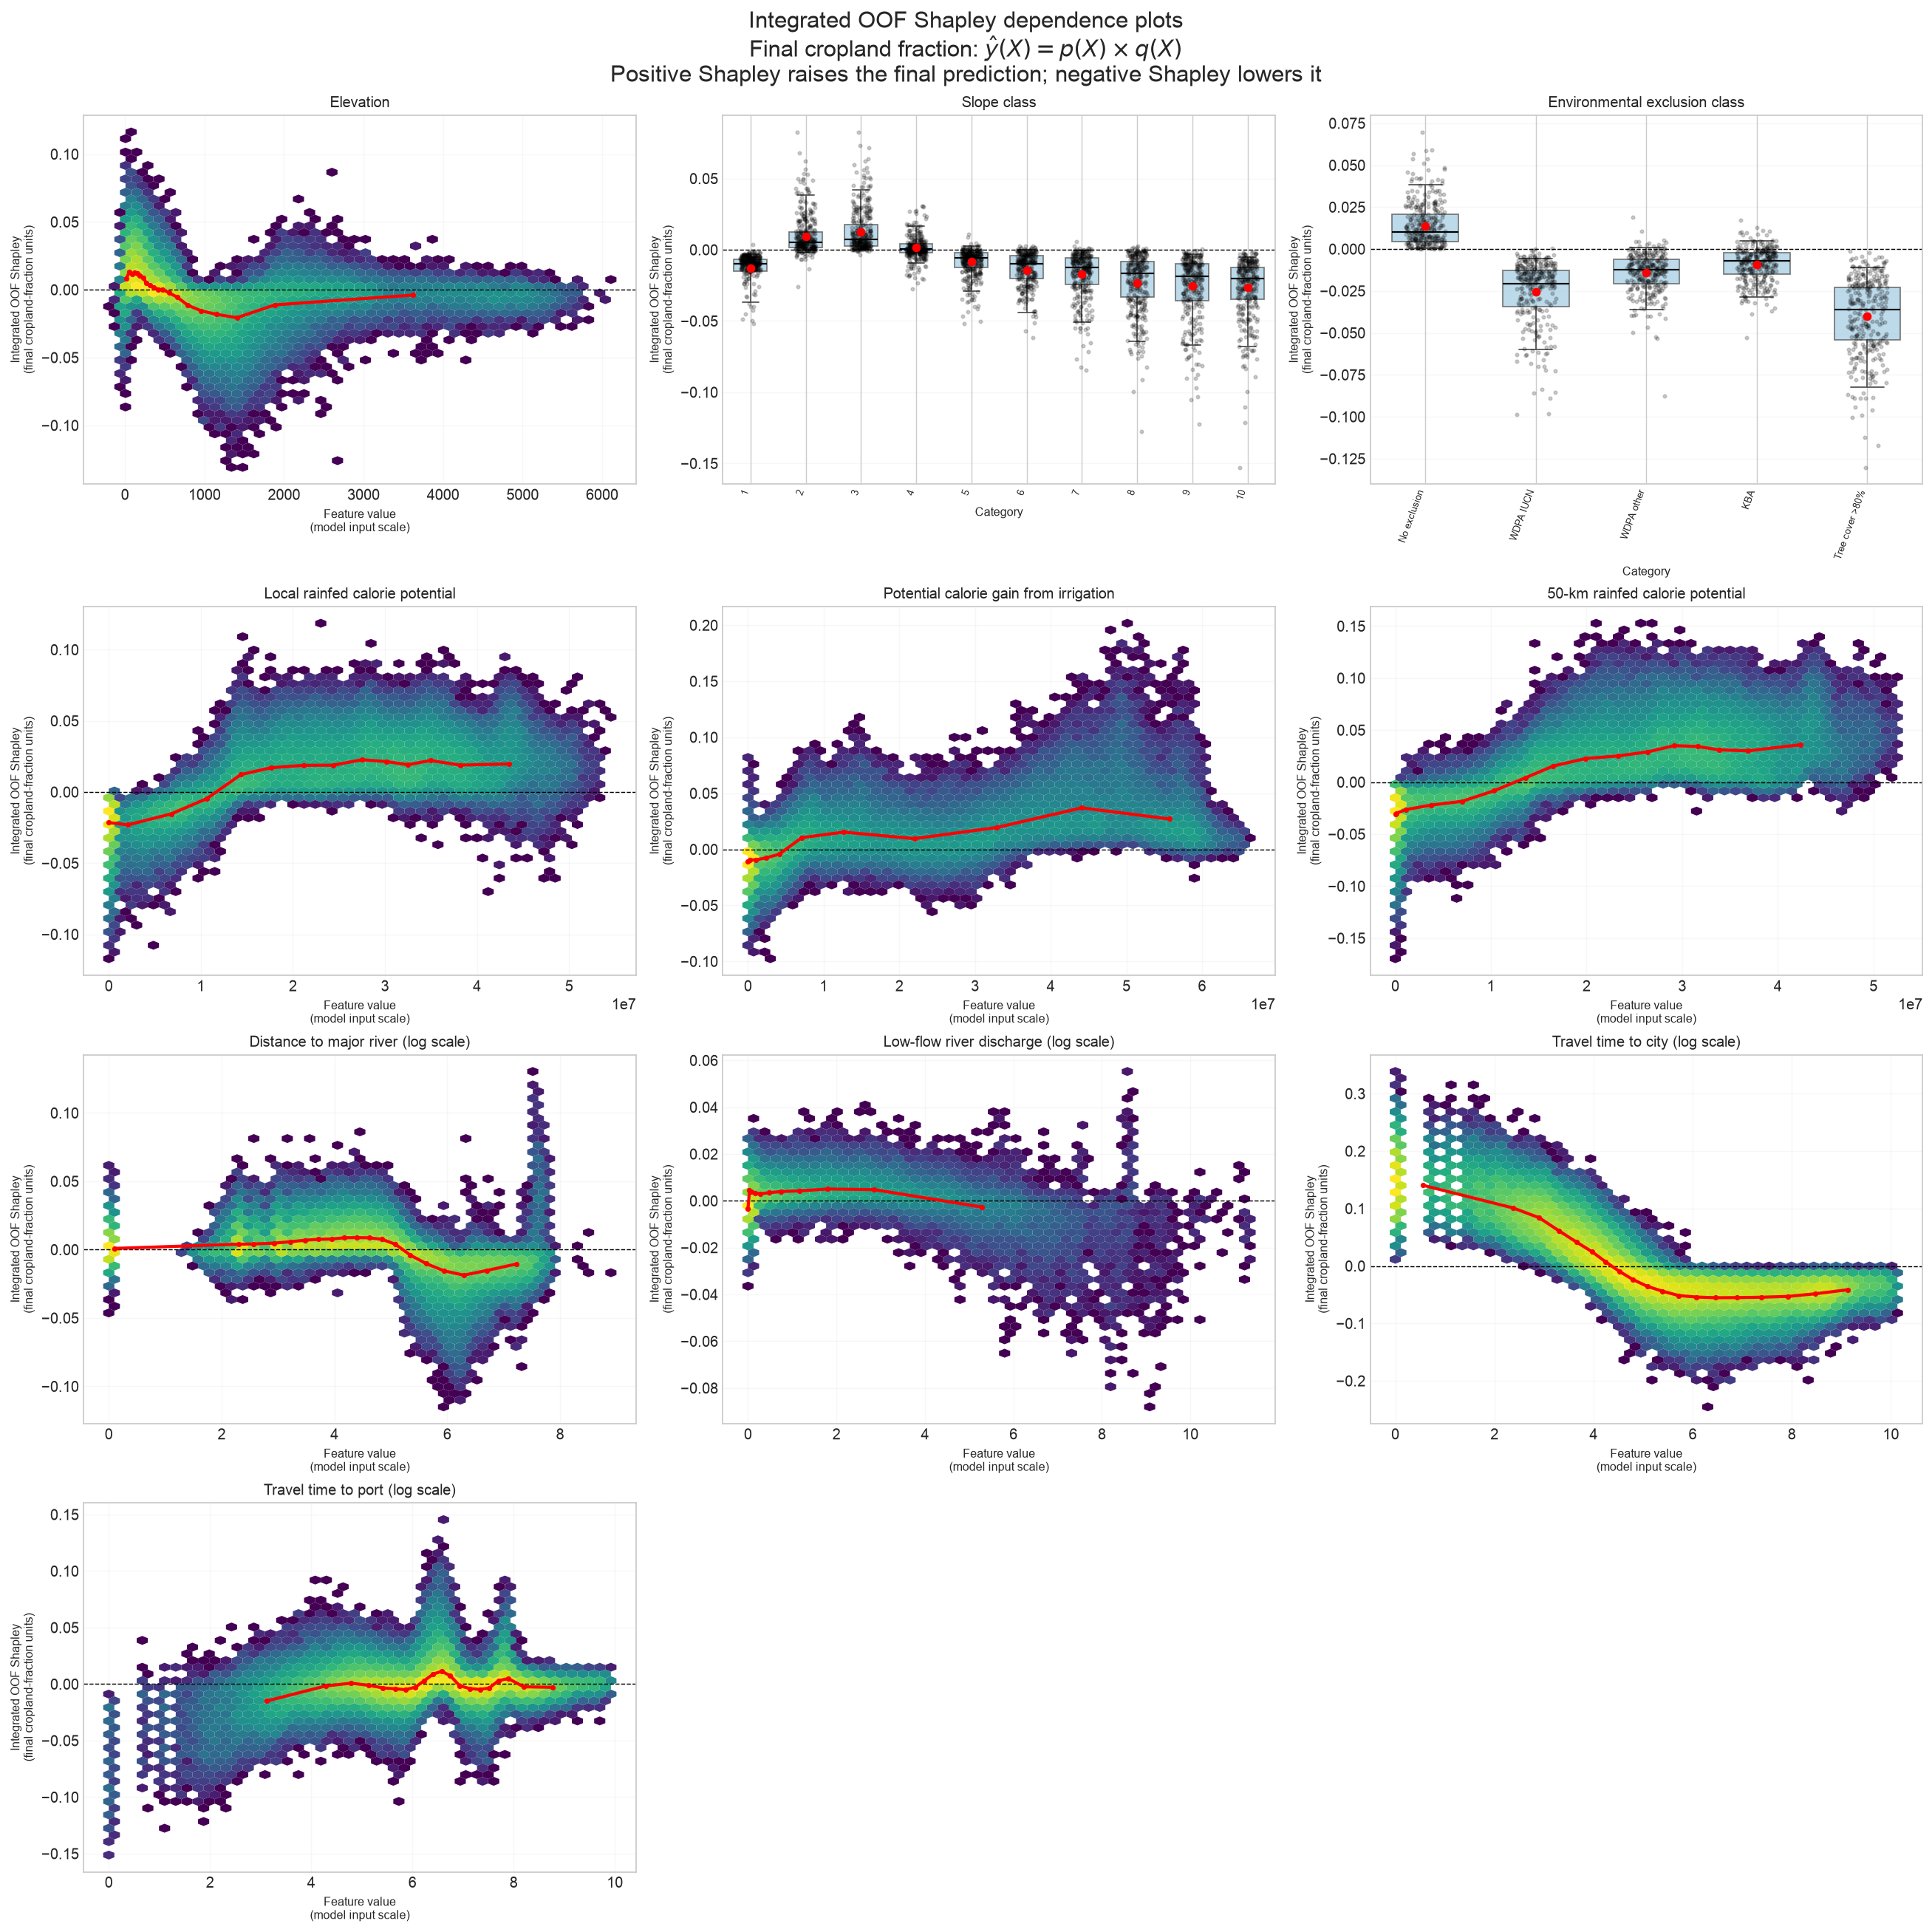

saved: /work/tsuda/GAEZ/integrated_final_feature_dependence_bg32_perm32/integrated_feature_dependence_old_style.png


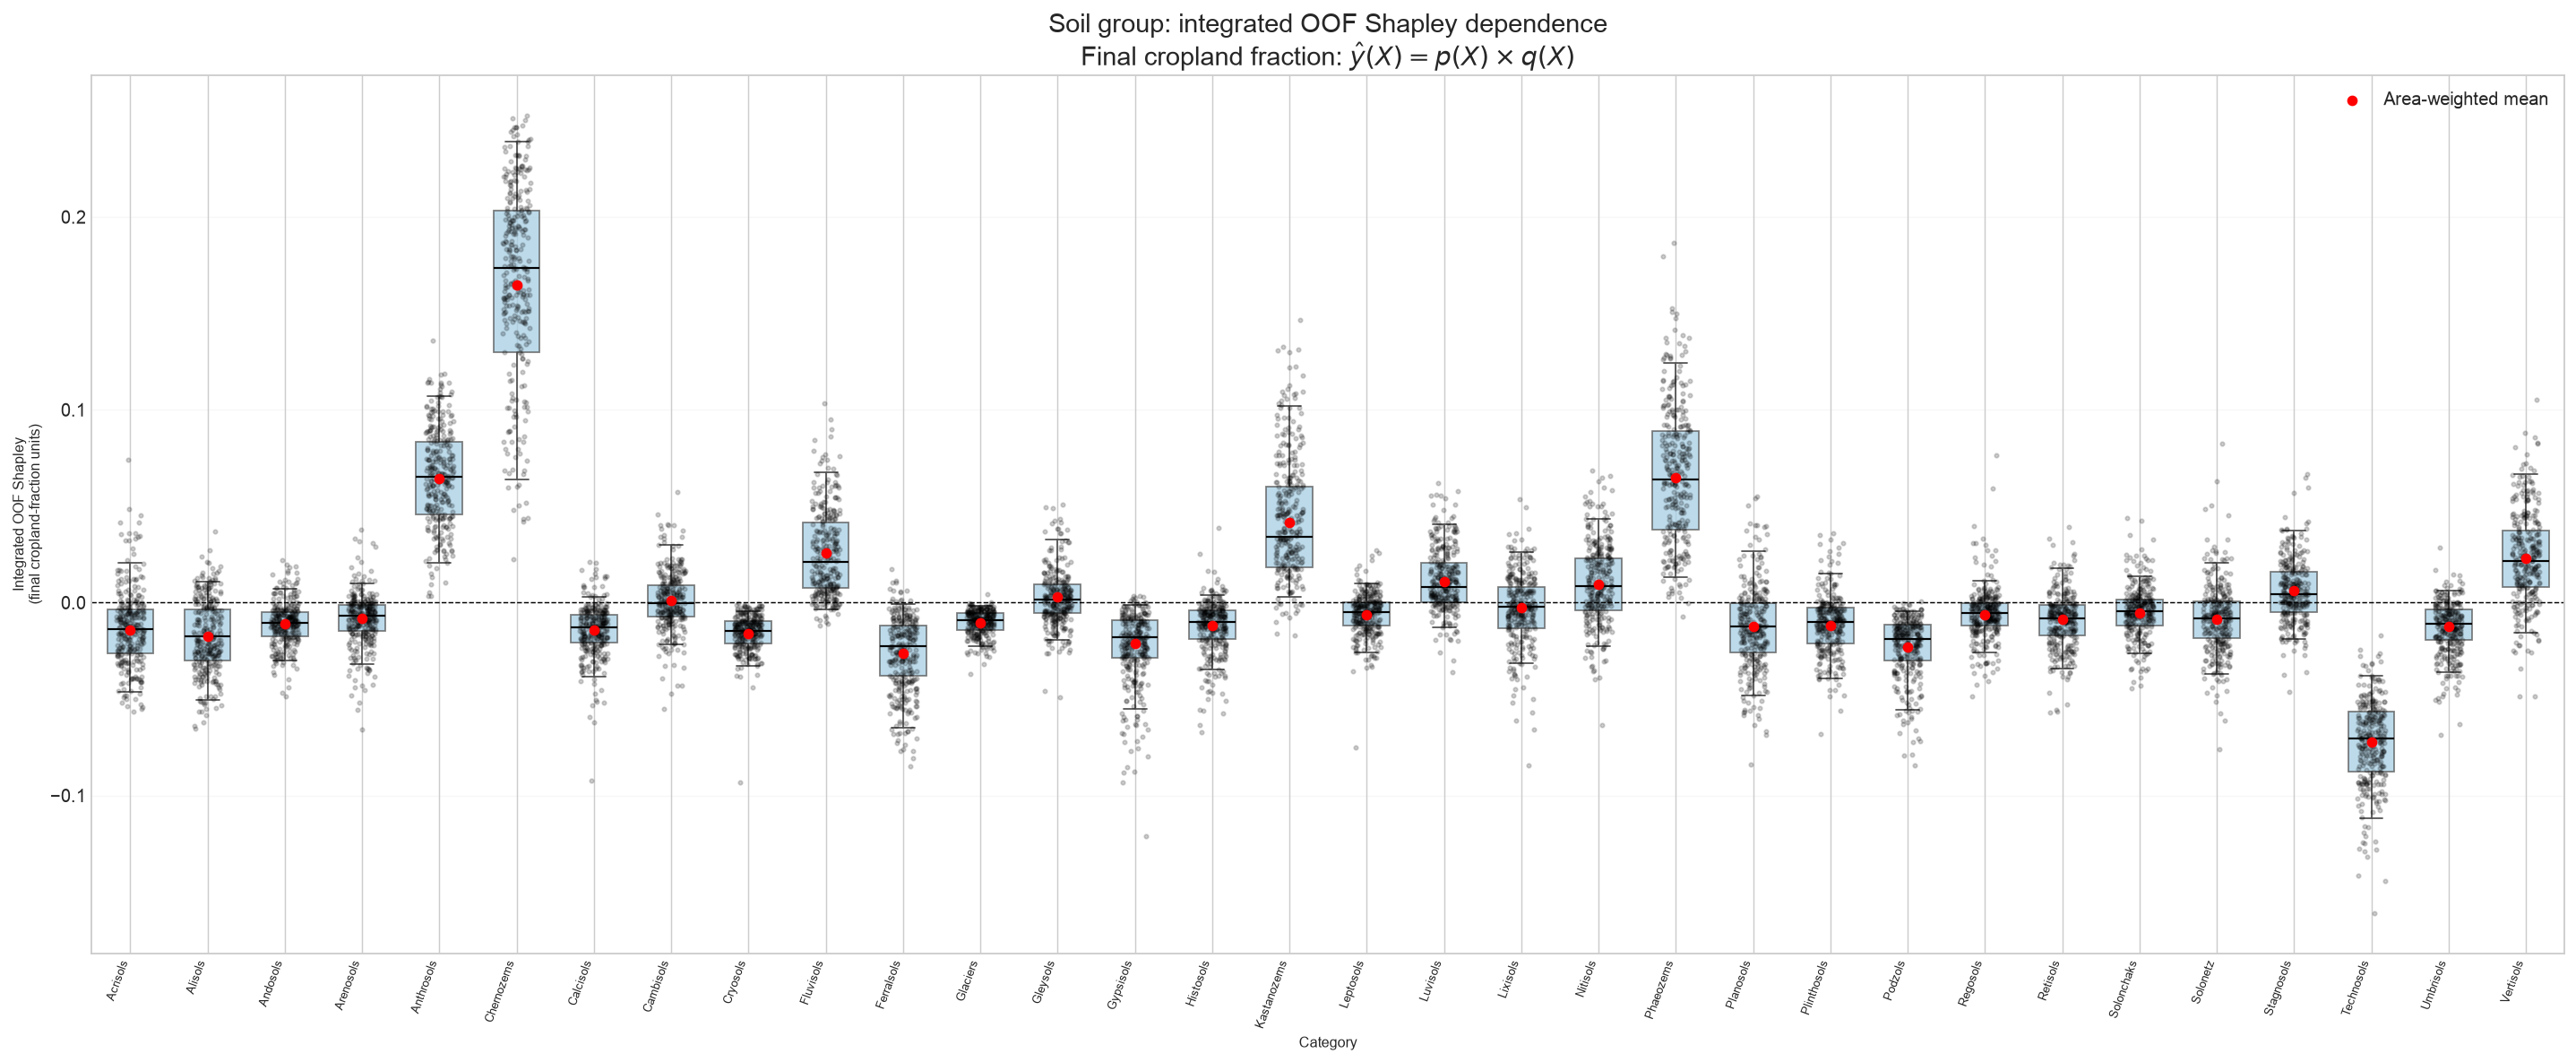

saved: /work/tsuda/GAEZ/integrated_final_feature_dependence_bg32_perm32/integrated_soil_group_dependence_old_style.png


In [30]:
# ============================================================
# 統合Shapley dependence plots
# 二段階SHAP分析と同じ描画スタイル
#
# 連続変数：
#   hexbin + 赤色の面積加重平均曲線
#
# 離散変数：
#   箱ひげ図 + 赤色の面積加重平均
# ============================================================

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 設定
# ------------------------------------------------------------

BASE_DIR = Path(
    r"/work/tsuda/GAEZ"
)

DEPENDENCE_OUTPUT_DIR = (
    BASE_DIR
    / "integrated_final_feature_dependence_bg32_perm32"
)

DEPENDENCE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


DEPENDENCE_DATA_PATH = (
    DEPENDENCE_OUTPUT_DIR
    / "integrated_feature_values_and_shapley_by_cell.csv.gz"
)


# dependence_dfがメモリにない場合は保存ファイルから読む
if "dependence_df" not in globals():

    if not DEPENDENCE_DATA_PATH.exists():
        raise FileNotFoundError(
            "説明変数値と統合Shapley値の保存ファイルがありません。\n"
            "先に前のコードのデータ作成部分を実行してください。\n"
            f"{DEPENDENCE_DATA_PATH}"
        )

    dependence_df = pd.read_csv(
        DEPENDENCE_DATA_PATH,
        compression="gzip",
    )

print(
    "dependence rows:",
    f"{len(dependence_df):,}",
)


# ------------------------------------------------------------
# 2. 表示する説明変数
# ------------------------------------------------------------

MAIN_PLOT_FEATURES = [
    "elevation_m",
    "slope",
    "exclusion_class",

    "rainfed_calorie_top5_raw",
    "irrigation_calorie_gain_top5_raw",
    "wx_50km_rainfed_calorie_top5_raw",

    "log_distance_river_gt10_2020",
    "log_glofas_p10_2020",

    "log_city_time_20k_min",
    "log_port_time_any_min",
]


# 土壌群はカテゴリ数が多いので別の図
SOIL_FEATURE = "soil_group_class"


CATEGORICAL_FEATURES = {
    "slope",
    "exclusion_class",
    "soil_group_class",
}


FEATURE_LABELS = {
    "elevation_m":
        "Elevation",

    "slope":
        "Slope class",

    "exclusion_class":
        "Environmental exclusion class",

    "soil_group_class":
        "Soil group",

    "rainfed_calorie_top5_raw":
        "Local rainfed calorie potential",

    "irrigation_calorie_gain_top5_raw":
        "Potential calorie gain from irrigation",

    "wx_50km_rainfed_calorie_top5_raw":
        "50-km rainfed calorie potential",

    "log_distance_river_gt10_2020":
        "Distance to major river (log scale)",

    "log_glofas_p10_2020":
        "Low-flow river discharge (log scale)",

    "log_city_time_20k_min":
        "Travel time to city (log scale)",

    "log_port_time_any_min":
        "Travel time to port (log scale)",
}


EXCLUSION_LABELS = {
    1: "No exclusion",
    2: "WDPA IUCN",
    3: "WDPA other",
    4: "KBA",
    5: "Permanent wetland",
    6: "Tree cover >80%",
}


SOIL_LABELS_LOCAL = {
    1: "Acrisols",
    2: "Alisols",
    3: "Andosols",
    4: "Arenosols",
    5: "Anthrosols",
    6: "Chernozems",
    7: "Calcisols",
    8: "Cambisols",
    9: "Cryosols",
    10: "Fluvisols",
    11: "Ferralsols",
    12: "Glaciers",
    13: "Gleysols",
    14: "Gypsisols",
    15: "Histosols",
    16: "Islands",
    17: "Kastanozems",
    18: "Leptosols",
    19: "Luvisols",
    20: "Lixisols",
    21: "Nitisols",
    22: "Phaeozems",
    23: "Planosols",
    24: "Plinthosols",
    25: "Podzols",
    26: "Regosols",
    27: "Retisols",
    28: "Solonchaks",
    29: "Solonetz",
    30: "Stagnosols",
    31: "Technosols",
    32: "Umbrisols",
    33: "Vertisols",
    34: "Open Water",
}


CATEGORY_LABEL_MAPS = {
    "exclusion_class":
        EXCLUSION_LABELS,

    "soil_group_class":
        SOIL_LABELS_LOCAL,
}


N_BINS = 20
MIN_CATEGORY_N = 30

N_COLUMNS = 3
N_ROWS = 4

HEXBIN_GRIDSIZE = 45
MAX_SCATTER_PER_CATEGORY = 300

BOX_COLOR = "#A6CEE3"
MEAN_COLOR = "red"
CURVE_COLOR = "red"


# ------------------------------------------------------------
# 3. 面積加重関数
# ------------------------------------------------------------

def weighted_mean(values, weights):

    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if valid.sum() == 0:
        return np.nan

    return float(
        np.average(
            values[valid],
            weights=weights[valid],
        )
    )


def weighted_quantile(
    values,
    quantiles,
    weights,
):

    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    quantiles = np.asarray(
        quantiles,
        dtype=float,
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return np.full(
            len(quantiles),
            np.nan,
        )

    order = np.argsort(values)

    values = values[order]
    weights = weights[order]

    cumulative = (
        np.cumsum(weights)
        - 0.5 * weights
    )

    cumulative = (
        cumulative
        / weights.sum()
    )

    return np.interp(
        quantiles,
        cumulative,
        values,
    )


# ------------------------------------------------------------
# 4. 連続変数の赤線を計算
# ------------------------------------------------------------

def make_binned_curve(
    frame,
    feature,
):

    shap_column = f"shap__{feature}"

    temp = frame[
        [
            feature,
            shap_column,
            "weight",
        ]
    ].copy()

    temp.columns = [
        "feature_value",
        "shapley_value",
        "weight",
    ]

    for column in temp.columns:
        temp[column] = pd.to_numeric(
            temp[column],
            errors="coerce",
        )

    temp = (
        temp
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    temp = temp[temp["weight"] > 0]

    number_of_bins = min(
        N_BINS,
        temp["feature_value"].nunique(),
    )

    if number_of_bins < 2:
        return pd.DataFrame()

    temp["bin"] = pd.qcut(
        temp["feature_value"],
        q=number_of_bins,
        duplicates="drop",
    )

    rows = []

    for _, group in temp.groupby(
        "bin",
        observed=True,
    ):

        weights = group[
            "weight"
        ].to_numpy(dtype=float)

        rows.append({
            "x": weighted_mean(
                group["feature_value"],
                weights,
            ),
            "y": weighted_mean(
                group["shapley_value"],
                weights,
            ),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("x")
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 5. 連続変数：hexbin＋赤い平均線
# ------------------------------------------------------------

def plot_continuous_feature(
    ax,
    frame,
    feature,
):

    shap_column = f"shap__{feature}"

    temp = frame[
        [
            feature,
            shap_column,
            "weight",
        ]
    ].copy()

    temp.columns = [
        "feature_value",
        "shapley_value",
        "weight",
    ]

    for column in temp.columns:
        temp[column] = pd.to_numeric(
            temp[column],
            errors="coerce",
        )

    temp = (
        temp
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    temp = temp[temp["weight"] > 0]

    ax.hexbin(
        temp["feature_value"],
        temp["shapley_value"],
        gridsize=HEXBIN_GRIDSIZE,
        mincnt=1,
        bins="log",
        cmap="viridis",
        linewidths=0,
    )

    curve = make_binned_curve(
        frame,
        feature,
    )

    if not curve.empty:
        ax.plot(
            curve["x"],
            curve["y"],
            color=CURVE_COLOR,
            linewidth=2.3,
            marker="o",
            markersize=3,
            zorder=4,
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
    )

    ax.set_title(
        FEATURE_LABELS.get(
            feature,
            feature,
        ),
        fontsize=11,
    )

    ax.set_xlabel(
        "Feature value\n"
        "(model input scale)",
        fontsize=9,
    )

    ax.set_ylabel(
        "Integrated OOF Shapley\n"
        "(final cropland-fraction units)",
        fontsize=9,
    )

    ax.grid(
        alpha=0.15,
    )

    ax.set_axisbelow(True)


# ------------------------------------------------------------
# 6. 離散変数：箱ひげ図＋赤い面積加重平均
# ------------------------------------------------------------

def plot_categorical_feature(
    ax,
    frame,
    feature,
    show_full_labels=True,
):

    shap_column = f"shap__{feature}"

    temp = frame[
        [
            feature,
            shap_column,
            "weight",
        ]
    ].copy()

    temp.columns = [
        "category",
        "shapley_value",
        "weight",
    ]

    for column in temp.columns:
        temp[column] = pd.to_numeric(
            temp[column],
            errors="coerce",
        )

    temp = (
        temp
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    temp = temp[temp["weight"] > 0]
    temp["category"] = temp["category"].astype(int)

    category_counts = (
        temp["category"]
        .value_counts()
        .sort_index()
    )

    categories = (
        category_counts[
            category_counts >= MIN_CATEGORY_N
        ]
        .index
        .tolist()
    )

    if not categories:
        ax.set_visible(False)
        return

    label_map = CATEGORY_LABEL_MAPS.get(
        feature,
        {},
    )

    box_stats = []
    weighted_means = []
    labels = []
    scatter_frames = []

    random_generator = np.random.default_rng(
        12345
    )

    for category in categories:

        group = temp[
            temp["category"].eq(category)
        ].copy()

        values = group[
            "shapley_value"
        ].to_numpy(dtype=float)

        weights = group[
            "weight"
        ].to_numpy(dtype=float)

        q05, q25, q50, q75, q95 = (
            weighted_quantile(
                values,
                [
                    0.05,
                    0.25,
                    0.50,
                    0.75,
                    0.95,
                ],
                weights,
            )
        )

        label = label_map.get(
            category,
            str(category),
        )

        if (
            feature == "soil_group_class"
            and not show_full_labels
        ):
            label = str(category)

        box_stats.append({
            "label": label,
            "whislo": q05,
            "q1": q25,
            "med": q50,
            "q3": q75,
            "whishi": q95,
            "fliers": [],
        })

        weighted_means.append(
            weighted_mean(
                values,
                weights,
            )
        )

        labels.append(label)

        number_to_plot = min(
            MAX_SCATTER_PER_CATEGORY,
            len(group),
        )

        selected = random_generator.choice(
            len(group),
            size=number_to_plot,
            replace=False,
        )

        scatter_frame = group.iloc[
            selected
        ].copy()

        scatter_frame[
            "plot_position"
        ] = (
            len(box_stats)
            + random_generator.uniform(
                -0.18,
                0.18,
                size=number_to_plot,
            )
        )

        scatter_frames.append(
            scatter_frame
        )

    positions = np.arange(
        1,
        len(categories) + 1,
    )

    # 重み付き分位点を使った箱ひげ図
    ax.bxp(
        box_stats,
        positions=positions,
        widths=0.60,
        showfliers=False,
        patch_artist=True,
        boxprops={
            "facecolor": BOX_COLOR,
            "alpha": 0.75,
            "edgecolor": "#555555",
        },
        medianprops={
            "color": "black",
            "linewidth": 1.2,
        },
        whiskerprops={
            "color": "#555555",
        },
        capprops={
            "color": "#555555",
        },
    )

    # サンプル点
    if scatter_frames:

        scatter_data = pd.concat(
            scatter_frames,
            ignore_index=True,
        )

        ax.scatter(
            scatter_data["plot_position"],
            scatter_data["shapley_value"],
            color="black",
            s=6,
            alpha=0.18,
            zorder=2,
        )

    # 赤点：面積加重平均
    ax.scatter(
        positions,
        weighted_means,
        color=MEAN_COLOR,
        s=30,
        zorder=5,
        label="Area-weighted mean",
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
    )

    ax.set_xticks(positions)

    ax.set_xticklabels(
        labels,
        rotation=70,
        ha="right",
        fontsize=7,
    )

    ax.set_title(
        FEATURE_LABELS.get(
            feature,
            feature,
        ),
        fontsize=11,
    )

    ax.set_xlabel(
        "Category",
        fontsize=9,
    )

    ax.set_ylabel(
        "Integrated OOF Shapley\n"
        "(final cropland-fraction units)",
        fontsize=9,
    )

    ax.grid(
        axis="y",
        alpha=0.15,
    )

    ax.set_axisbelow(True)


# ------------------------------------------------------------
# 7. メインシート
#
# 土壌群以外の10変数を一枚にまとめる
# ------------------------------------------------------------

fig, axes = plt.subplots(
    N_ROWS,
    N_COLUMNS,
    figsize=(20, 20),
    constrained_layout=True,
)

axes = np.asarray(
    axes
).reshape(-1)


for ax, feature in zip(
    axes,
    MAIN_PLOT_FEATURES,
):

    if feature in CATEGORICAL_FEATURES:

        plot_categorical_feature(
            ax=ax,
            frame=dependence_df,
            feature=feature,
        )

    else:

        plot_continuous_feature(
            ax=ax,
            frame=dependence_df,
            feature=feature,
        )


for ax in axes[len(MAIN_PLOT_FEATURES):]:
    ax.set_visible(False)


fig.suptitle(
    "Integrated OOF Shapley dependence plots\n"
    r"Final cropland fraction: "
    r"$\hat{y}(X)=p(X)\times q(X)$"
    "\nPositive Shapley raises the final prediction; "
    "negative Shapley lowers it",
    fontsize=17,
)


MAIN_FIGURE_PATH = (
    DEPENDENCE_OUTPUT_DIR
    / "integrated_feature_dependence_old_style.png"
)

fig.savefig(
    MAIN_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("saved:", MAIN_FIGURE_PATH)


# ------------------------------------------------------------
# 8. 土壌群：全幅の箱ひげ図
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(22, 9),
    constrained_layout=True,
)


plot_categorical_feature(
    ax=ax,
    frame=dependence_df,
    feature=SOIL_FEATURE,
    show_full_labels=True,
)


ax.set_title(
    "Soil group: integrated OOF Shapley dependence\n"
    r"Final cropland fraction: "
    r"$\hat{y}(X)=p(X)\times q(X)$",
    fontsize=16,
)


ax.legend(
    loc="upper right",
)


SOIL_FIGURE_PATH = (
    DEPENDENCE_OUTPUT_DIR
    / "integrated_soil_group_dependence_old_style.png"
)

fig.savefig(
    SOIL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("saved:", SOIL_FIGURE_PATH)

Loading saved stage-specific OOF SHAP:
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_model_oof_local_feature_shap.csv.gz

Stage counts:
stage
presence_classifier               50000
conditional_fraction_regressor    50000
saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/saved_oof_shap_beeswarm/stage1_presence_oof_shap_beeswarm.png


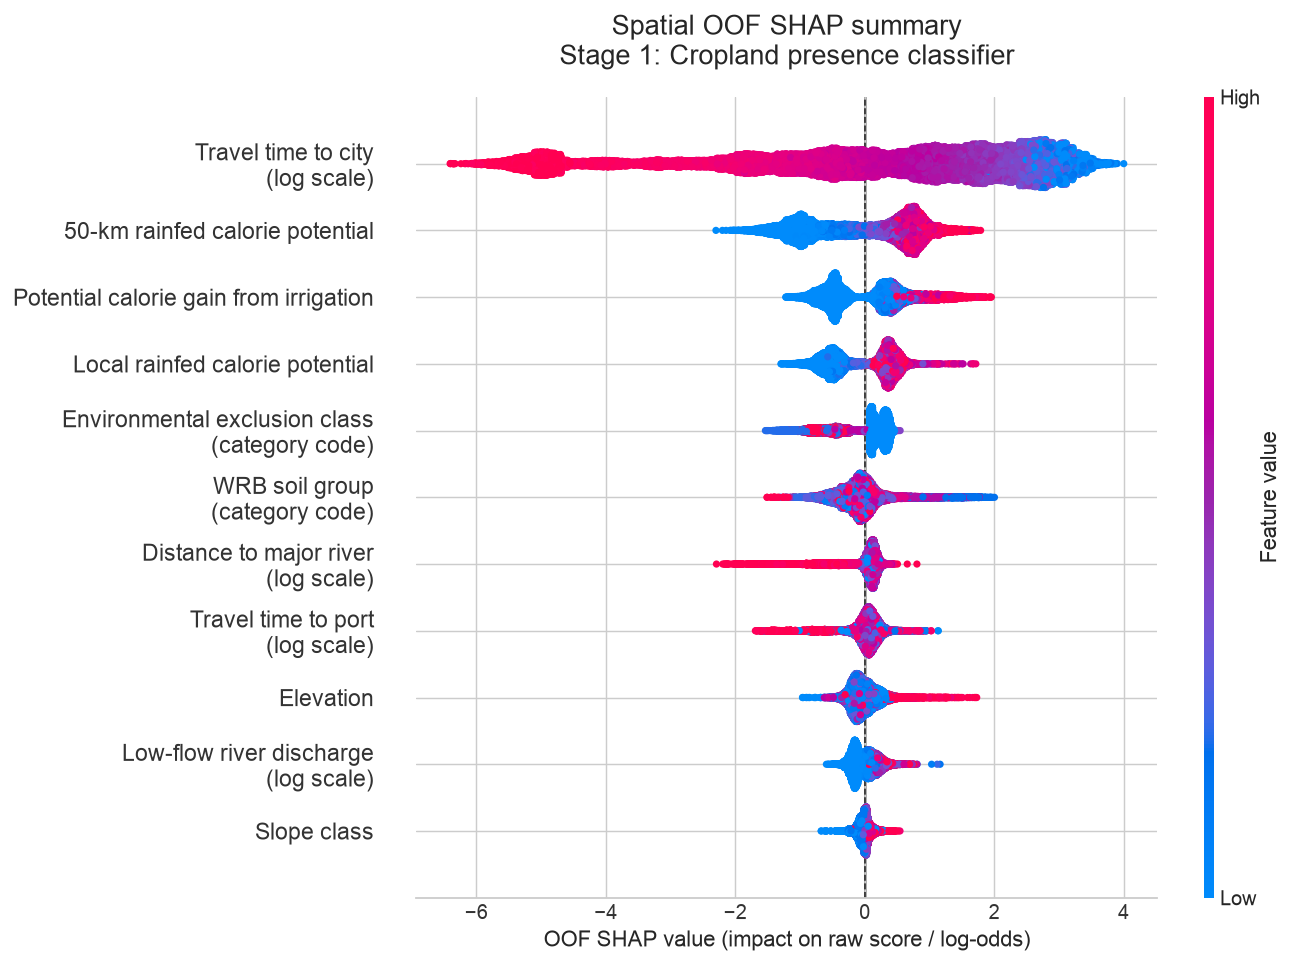

saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/saved_oof_shap_beeswarm/stage2_conditional_fraction_oof_shap_beeswarm.png


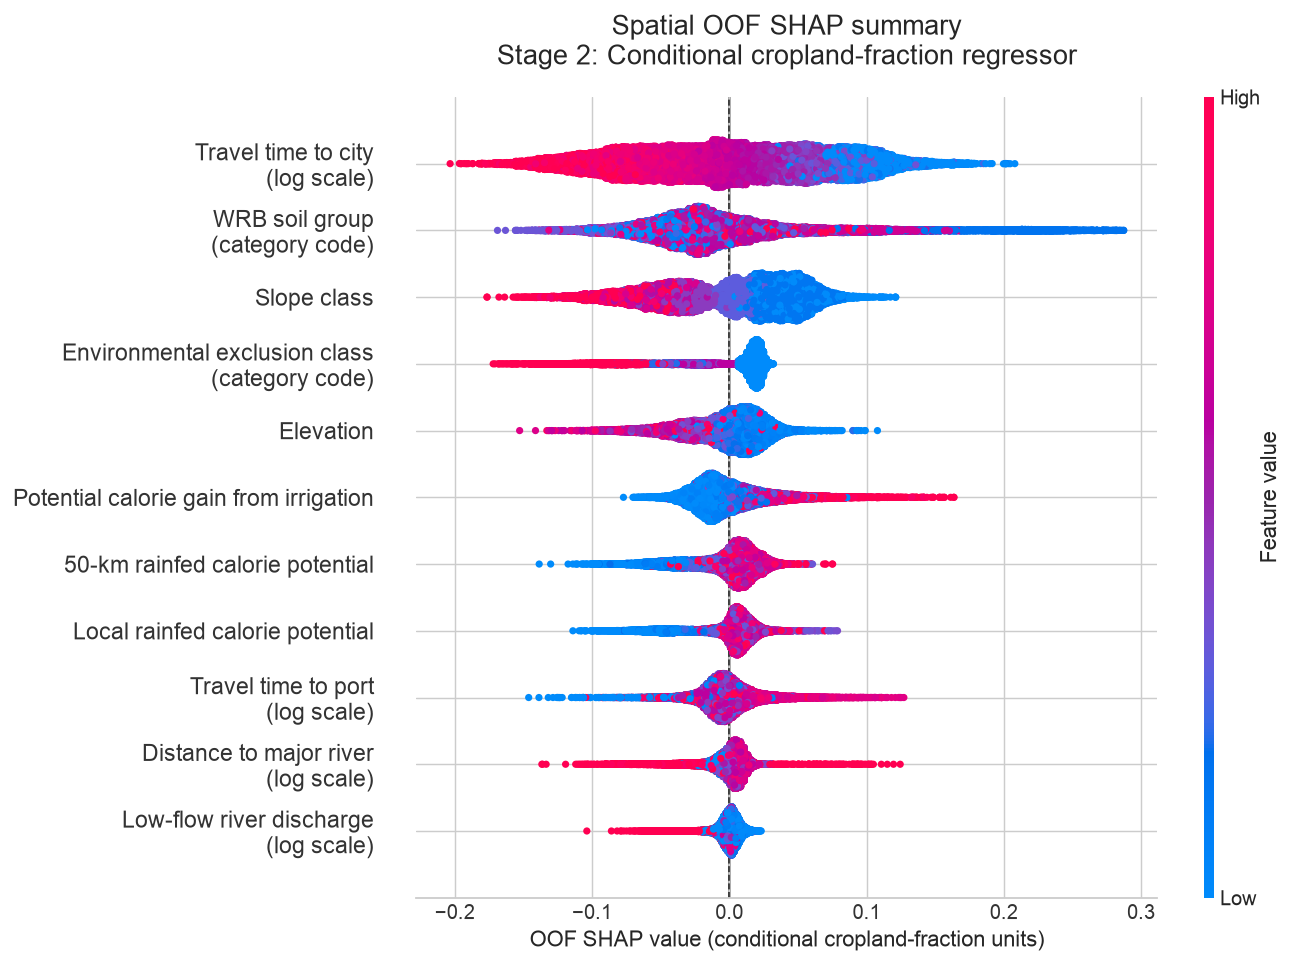


Loading saved integrated OOF Shapley:
/work/tsuda/GAEZ/integrated_final_feature_dependence_bg32_perm32/integrated_feature_values_and_shapley_by_cell.csv.gz
Integrated cells: 240,000
saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/saved_oof_shap_beeswarm/integrated_final_fraction_oof_shap_beeswarm.png


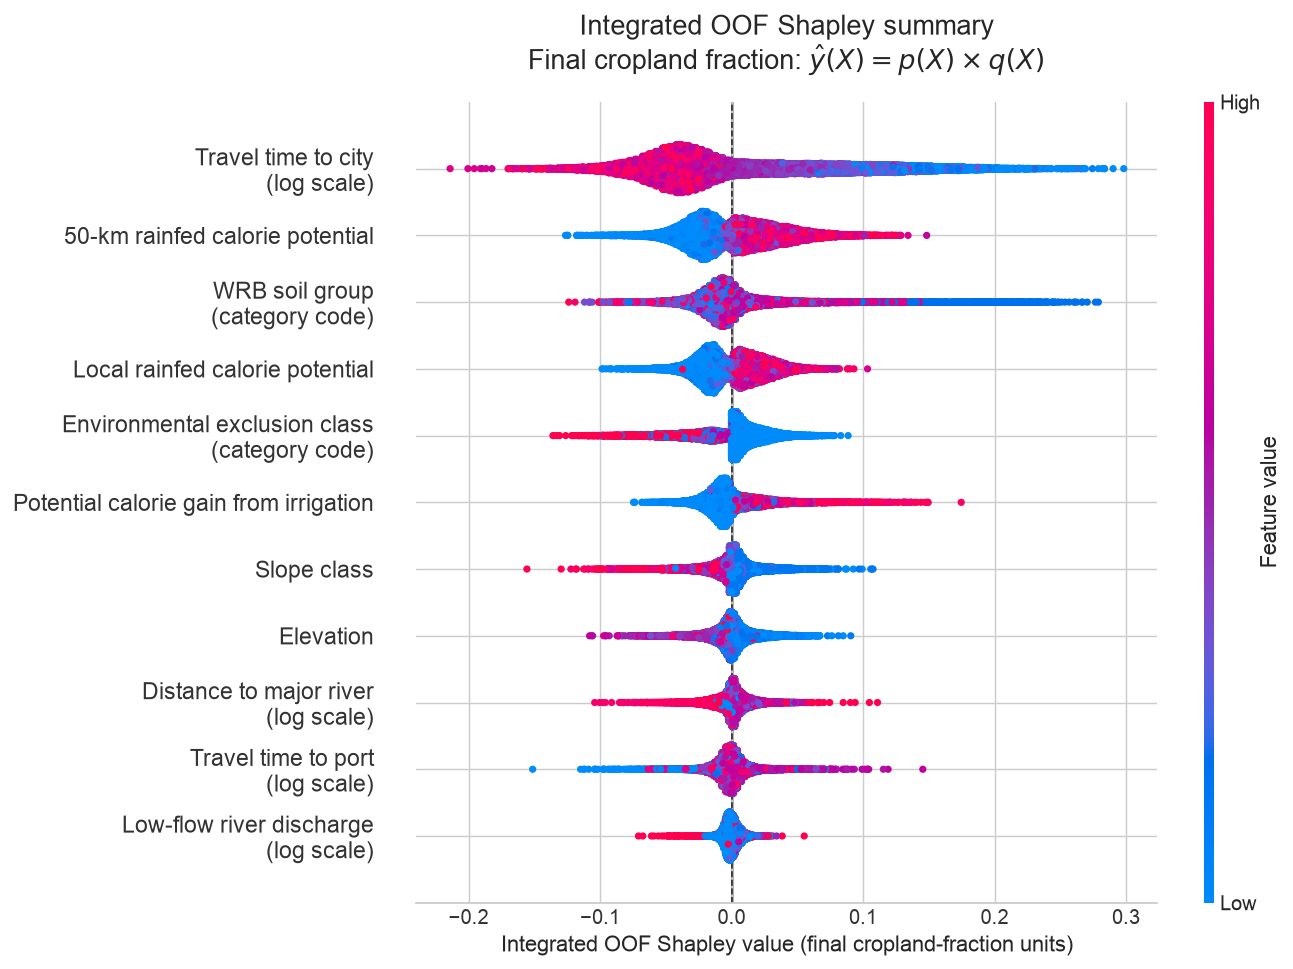


SAVED OOF SHAP BEESWARM COMPLETED
Output directory:
/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/saved_oof_shap_beeswarm

注意:
- 赤 = 変数値が高いセル
- 青 = 変数値が低いセル
- 右側 = 予測を引き上げる
- 左側 = 予測を引き下げる
- 上の変数ほど平均絶対SHAPが大きい
- soil_group_class と exclusion_class の色はカテゴリ番号であり、大小の実質的意味はありません。


In [31]:
# ============================================================
# 保存済みOOF SHAPを使ったSHAP beeswarm summary plot
#
# 再計算しないもの：
#   - LightGBMの再学習
#   - Spatial OOFの再実行
#   - TreeSHAPの再計算
#   - 統合Shapleyの再計算
#
# 保存済みCSVを読み込んで描画するだけ
# ============================================================

from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# ------------------------------------------------------------
# 1. 保存済みデータ
# ------------------------------------------------------------

BASE_DIR = Path(
    r"/work/tsuda/GAEZ"
)

MODEL_OUTPUT_DIR = (
    BASE_DIR
    / "CroplandRegression"
    / "soil_group_calorie_only_50km"
)

# Stage 1・Stage 2の保存済みOOF TreeSHAP
STAGE_SHAP_PATH = (
    MODEL_OUTPUT_DIR
    / "soil_model_oof_local_feature_shap.csv.gz"
)

# 最終 p(X)×q(X) の保存済み統合Shapley＋説明変数値
INTEGRATED_SHAP_PATH = (
    BASE_DIR
    / "integrated_final_feature_dependence_bg32_perm32"
    / "integrated_feature_values_and_shapley_by_cell.csv.gz"
)

OUTPUT_DIR_BEESWARM = (
    MODEL_OUTPUT_DIR
    / "saved_oof_shap_beeswarm"
)

OUTPUT_DIR_BEESWARM.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. 使用変数
# ------------------------------------------------------------

FEATURES = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "soil_group_class",

    "rainfed_calorie_top5_raw",
    "irrigation_calorie_gain_top5_raw",
    "wx_50km_rainfed_calorie_top5_raw",

    "log_distance_river_gt10_2020",
    "log_glofas_p10_2020",

    "log_city_time_20k_min",
    "log_port_time_any_min",
]

FEATURE_LABELS = {
    "elevation_m":
        "Elevation",

    "slope":
        "Slope class",

    "exclusion_class":
        "Environmental exclusion class\n(category code)",

    "soil_group_class":
        "WRB soil group\n(category code)",

    "rainfed_calorie_top5_raw":
        "Local rainfed calorie potential",

    "irrigation_calorie_gain_top5_raw":
        "Potential calorie gain from irrigation",

    "wx_50km_rainfed_calorie_top5_raw":
        "50-km rainfed calorie potential",

    "log_distance_river_gt10_2020":
        "Distance to major river\n(log scale)",

    "log_glofas_p10_2020":
        "Low-flow river discharge\n(log scale)",

    "log_city_time_20k_min":
        "Travel time to city\n(log scale)",

    "log_port_time_any_min":
        "Travel time to port\n(log scale)",
}

SHAP_COLUMNS = {
    feature: f"shap__{feature}"
    for feature in FEATURES
}


# ------------------------------------------------------------
# 3. 描画設定
# ------------------------------------------------------------

# beeswarmは全セルを描く必要はありません。
# 面積加重抽出した最大30,000セルで分布を表示します。
MAX_PLOT_ROWS = 30_000
RANDOM_STATE = 20260830

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "figure.dpi": 130,
})


# ------------------------------------------------------------
# 4. 面積加重サンプリング
# ------------------------------------------------------------

def area_weighted_sample(
    frame,
    max_rows=MAX_PLOT_ROWS,
    random_state=RANDOM_STATE,
):
    """
    描画用にセルを面積加重抽出する。
    LightGBMやSHAPの再計算は行わない。
    """

    frame = frame.copy()

    if len(frame) <= max_rows:
        return frame.reset_index(drop=True)

    if "weight" not in frame.columns:
        return (
            frame.sample(
                n=max_rows,
                random_state=random_state,
            )
            .reset_index(drop=True)
        )

    weights = pd.to_numeric(
        frame["weight"],
        errors="coerce",
    ).to_numpy(dtype=float)

    valid_weights = (
        np.isfinite(weights)
        & (weights > 0)
    )

    # Gumbel top-k法による重み付き非復元抽出。
    # pandas.sampleは大きな個別ウェイトに対して失敗するため使わない。
    if valid_weights.sum() >= max_rows:
        rng = np.random.default_rng(random_state)
        scores = np.full(len(frame), -np.inf, dtype=float)
        scores[valid_weights] = (
            np.log(weights[valid_weights])
            + rng.gumbel(size=valid_weights.sum())
        )
        selected = np.argpartition(scores, -max_rows)[-max_rows:]
        selected = selected[np.argsort(scores[selected])[::-1]]
        return frame.iloc[selected].reset_index(drop=True)

    # 重みが利用できない場合のフォールバック
    return (
        frame.sample(
            n=max_rows,
            random_state=random_state,
        )
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 5. beeswarm描画関数
# ------------------------------------------------------------

def plot_saved_beeswarm(
    frame,
    title,
    xlabel,
    output_path,
):
    """
    保存済みSHAP値と説明変数値からbeeswarmを描く。
    """

    required_columns = (
        FEATURES
        + [SHAP_COLUMNS[f] for f in FEATURES]
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise KeyError(
            "必要な列がありません:\n"
            + "\n".join(missing_columns)
        )

    keep_columns = required_columns.copy()

    if "weight" in frame.columns:
        keep_columns.append("weight")

    plot_frame = frame[keep_columns].copy()

    # 数値化
    for column in required_columns:
        plot_frame[column] = pd.to_numeric(
            plot_frame[column],
            errors="coerce",
        )

    # SHAP値が欠損している行だけ除外
    shap_matrix_all = plot_frame[
        [SHAP_COLUMNS[f] for f in FEATURES]
    ].to_numpy(dtype=float)

    valid_rows = np.isfinite(
        shap_matrix_all
    ).all(axis=1)

    plot_frame = (
        plot_frame.loc[valid_rows]
        .reset_index(drop=True)
    )

    # 描画用の面積加重サンプル
    plot_frame = area_weighted_sample(
        plot_frame,
    )

    feature_values = (
        plot_frame[FEATURES]
        .copy()
    )

    feature_values.columns = [
        FEATURE_LABELS[f]
        for f in FEATURES
    ]

    shap_values = plot_frame[
        [SHAP_COLUMNS[f] for f in FEATURES]
    ].to_numpy(dtype=float)

    # 既存の図が残らないようにする
    plt.close("all")

    shap.summary_plot(
        shap_values=shap_values,
        features=feature_values,
        feature_names=list(feature_values.columns),
        plot_type="dot",
        max_display=len(FEATURES),
        sort=True,
        show=False,
        plot_size=(12.5, 8.0),
        color_bar=True,
    )

    fig = plt.gcf()
    ax = plt.gca()

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.9,
        alpha=0.8,
    )

    ax.set_xlabel(
        xlabel,
        fontsize=12,
    )

    ax.set_title(
        title,
        fontsize=15,
        pad=18,
    )

    # 長い変数名とカラーバーのための余白
    fig.subplots_adjust(
        left=0.34,
        right=0.91,
        top=0.88,
        bottom=0.11,
    )

    fig.savefig(
        output_path,
        dpi=250,
        bbox_inches="tight",
        facecolor="white",
    )

    print("saved:", output_path)

    plt.show()
    plt.close(fig)


# ------------------------------------------------------------
# 6. Stage 1・Stage 2の保存済みSHAPを読み込む
# ------------------------------------------------------------

if not STAGE_SHAP_PATH.exists():
    raise FileNotFoundError(
        "Stage別OOF SHAPファイルがありません:\n"
        f"{STAGE_SHAP_PATH}"
    )

stage_usecols = (
    ["stage", "weight"]
    + FEATURES
    + [SHAP_COLUMNS[f] for f in FEATURES]
)

print("Loading saved stage-specific OOF SHAP:")
print(STAGE_SHAP_PATH)

stage_shap_df = pd.read_csv(
    STAGE_SHAP_PATH,
    compression="gzip",
    usecols=stage_usecols,
)

print("\nStage counts:")
print(
    stage_shap_df["stage"]
    .value_counts()
    .to_string()
)


# ------------------------------------------------------------
# 7. Stage 1：農地存在分類器
# ------------------------------------------------------------

presence_df = (
    stage_shap_df.loc[
        stage_shap_df["stage"]
        == "presence_classifier"
    ]
    .copy()
    .reset_index(drop=True)
)

plot_saved_beeswarm(
    frame=presence_df,
    title=(
        "Spatial OOF SHAP summary\n"
        "Stage 1: Cropland presence classifier"
    ),
    xlabel=(
        "OOF SHAP value "
        "(impact on raw score / log-odds)"
    ),
    output_path=(
        OUTPUT_DIR_BEESWARM
        / "stage1_presence_oof_shap_beeswarm.png"
    ),
)


# ------------------------------------------------------------
# 8. Stage 2：条件付き農地割合回帰
# ------------------------------------------------------------

conditional_df = (
    stage_shap_df.loc[
        stage_shap_df["stage"]
        == "conditional_fraction_regressor"
    ]
    .copy()
    .reset_index(drop=True)
)

plot_saved_beeswarm(
    frame=conditional_df,
    title=(
        "Spatial OOF SHAP summary\n"
        "Stage 2: Conditional cropland-fraction regressor"
    ),
    xlabel=(
        "OOF SHAP value "
        "(conditional cropland-fraction units)"
    ),
    output_path=(
        OUTPUT_DIR_BEESWARM
        / "stage2_conditional_fraction_oof_shap_beeswarm.png"
    ),
)


# Stage別データはもう不要
del presence_df
del conditional_df
del stage_shap_df
gc.collect()


# ------------------------------------------------------------
# 9. 最終 p(X)×q(X) の統合Shapley
# ------------------------------------------------------------

if not INTEGRATED_SHAP_PATH.exists():
    raise FileNotFoundError(
        "保存済み統合Shapleyファイルがありません:\n"
        f"{INTEGRATED_SHAP_PATH}"
    )

integrated_usecols = (
    ["weight"]
    + FEATURES
    + [SHAP_COLUMNS[f] for f in FEATURES]
)

print("\nLoading saved integrated OOF Shapley:")
print(INTEGRATED_SHAP_PATH)

integrated_df = pd.read_csv(
    INTEGRATED_SHAP_PATH,
    compression="gzip",
    usecols=integrated_usecols,
)

print(
    "Integrated cells:",
    f"{len(integrated_df):,}",
)

plot_saved_beeswarm(
    frame=integrated_df,
    title=(
        "Integrated OOF Shapley summary\n"
        r"Final cropland fraction: "
        r"$\hat{y}(X)=p(X)\times q(X)$"
    ),
    xlabel=(
        "Integrated OOF Shapley value "
        "(final cropland-fraction units)"
    ),
    output_path=(
        OUTPUT_DIR_BEESWARM
        / "integrated_final_fraction_oof_shap_beeswarm.png"
    ),
)

del integrated_df
gc.collect()


# ------------------------------------------------------------
# 10. 完了
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("SAVED OOF SHAP BEESWARM COMPLETED")
print("=" * 72)
print("Output directory:")
print(OUTPUT_DIR_BEESWARM)

print(
    "\n注意:"
    "\n- 赤 = 変数値が高いセル"
    "\n- 青 = 変数値が低いセル"
    "\n- 右側 = 予測を引き上げる"
    "\n- 左側 = 予測を引き下げる"
    "\n- 上の変数ほど平均絶対SHAPが大きい"
    "\n- soil_group_class と exclusion_class の色は"
    "カテゴリ番号であり、大小の実質的意味はありません。"
)